# B — Runtime Behaviour Explorer

**Audience:** a researcher asking *"what is the runtime actually doing?"* Absolute values, not ratios. Distribution shapes, not just medians.

**Structure (Option C — per-comparison).** §3 surfaces a small all-variants diagnostic overview for pathology detection (anything looking obviously broken). §4 then dives into per-comparison detail: each block's section is restricted to that block's variants, so you read absolute behaviour for the configurations you care about with much less visual clutter than 8 colours on every plot.

Reads the parquet cache produced by Notebook A. If it doesn't exist yet, run A first.

In [1]:
%matplotlib inline
import os
from pathlib import Path

LOGS_DIR = Path(os.environ.get("BENCH_LOGS_DIR")
                or "../logs")
BASELINE = {"version": "5.4.1", "flags": "baseline"}
CACHE = Path.cwd() / "cache" / "macrobench.parquet"
MINISTAT_OUT = Path.cwd() / "cache" / "ministat"

# When not None, ignore the runbms.yml `comparisons:` block and use this
# Python list instead. Same shape as the YAML schema. Useful for ad-hoc
# exploration without editing YAML or re-running benchmarks.
COMPARISONS_OVERRIDE = None

# Operating envelope — what counts as a "well-tuned" benchmark.
# Wall-time ceiling is intentionally generous (60s) for slower hardware;
# tune to your machine. The §3 health view flags benchmarks falling
# outside any of these.
ENVELOPE = {
    "wall_min_s":             0.5,    # below: startup overhead dominates
    "wall_max_s":            60.0,    # above: iteration cost is awful
    "gc_overhead_min_pct":    1.0,    # below: workload doesn't exercise GC
    "gc_overhead_max_pct":   50.0,    # above: GC-pathological
    "major_collections_min":  5,      # below: major GC barely engaged
    "iqr_relative_max":       0.10,   # 10% IQR / median = noisy
}

if not LOGS_DIR.exists():
    raise SystemExit(
        f"LOGS_DIR does not exist: {LOGS_DIR.resolve()}\n"
        "Set BENCH_LOGS_DIR to your run directory, e.g.:\n"
        "  BENCH_LOGS_DIR=../gc-sweep-logs/monolith-2026-05-07-Thu-110013 jupyter ...\n"
        "or edit this cell."
    )

import sys
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from macrobench_loader import (
    load_macro_dataframe, load_comparisons, audit_comparison_coverage,
    export_for_ministat, Comparison,
)

sns.set_theme(context="notebook", style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

## 1. Load

In [2]:
if CACHE.exists():
    df = pd.read_parquet(CACHE)
    print(f"Loaded cache: {CACHE}  shape={df.shape}")
else:
    df = load_macro_dataframe(LOGS_DIR)
    CACHE.parent.mkdir(exist_ok=True)
    df.to_parquet(CACHE)
    print(f"Built cache:  {CACHE}  shape={df.shape}")

all_variants = sorted(df["variant"].unique())
benches      = sorted(df["benchmark"].unique())
invocations_per_cell = df.groupby(["benchmark", "variant"]).size()
n_invocations = int(invocations_per_cell.max())

print(f"variants: {all_variants}")
print(f"benchmarks: {len(benches)}")
print(
    f"invocations per (benchmark, variant): "
    f"min={invocations_per_cell.min()}  median={int(invocations_per_cell.median())}  max={n_invocations}"
)
if df["s"].notna().any() or df["o"].notna().any():
    print(f"GC sweep fields present: s={sorted(df['s'].dropna().unique())}, o={sorted(df['o'].dropna().unique())}")
print(f"perf groups: {sorted(df['perf_grp'].unique())}  re: {sorted(df['re'].unique())}  md: {sorted(df['md'].unique())}")

Loaded cache: /home/udesou/macro-benches/results/latest/2026-05-12-fp-flambda-N10-monolith/notebooks/cache/macrobench.parquet  shape=(2880, 50)
variants: ['5.4.1/baseline', '5.4.1/flambda', '5.4.1/fp', '5.4.1/fp-flambda', 'd8bb46c/baseline', 'd8bb46c/flambda', 'd8bb46c/fp', 'd8bb46c/fp-flambda']
benchmarks: 36
invocations per (benchmark, variant): min=10  median=10  max=10
perf groups: [np.int64(1)]  re: [np.int64(25)]  md: [np.int64(2)]


## 2. Sanity & comparisons resolution

Same coverage check as Notebook A — runtimes declared but no data, variants in data but never rendered. Then resolve the comparison blocks that drive §4.

In [3]:
comparisons = load_comparisons(
    LOGS_DIR, all_variants=all_variants,
    baseline=BASELINE, override=COMPARISONS_OVERRIDE,
)
audit = audit_comparison_coverage(LOGS_DIR, df, comparisons)

print("Comparisons declared:")
for c in comparisons:
    block_variants = sorted({v for pair in c.pairs for v in pair})
    print(f"  - {c.label!r}  ({len(c.pairs)} pair{'s' if len(c.pairs) != 1 else ''}, "
          f"{len(block_variants)} variant{'s' if len(block_variants) != 1 else ''})")

print(
    f"\nVariant coverage: {audit.comparison_variants_total} / "
    f"{audit.data_variants_total} variants are referenced by a comparison block."
)
if audit.declared_runtimes_no_data:
    print(f"\nWARNING: declared but no data: {audit.declared_runtimes_no_data}")
if audit.data_variants_uncovered:
    print(f"\nWARNING: data without comparison coverage: {audit.data_variants_uncovered}")

Comparisons declared:
  - '5.4.1 flag effects'  (3 pairs, 4 variants)
  - 'd8bb46c flag effects'  (3 pairs, 4 variants)
  - 'version effect (by flag combo)'  (4 pairs, 8 variants)

Variant coverage: 8 / 8 variants are referenced by a comparison block.


## 3. Diagnostic overview (all variants)

A small set of all-variants views to surface anything obviously broken before reading per-comparison detail. If a variant looks pathological here (IPC suspiciously low, GC overhead pegged at 100%, wall-time bimodal), the per-block sections in §4 will let you investigate — but you wouldn't have known to look without this overview.

In [4]:
# Per-variant summary table — one row per variant, scan for outliers.
agg = df.groupby("variant").agg(
    median_wall_s=("olly_wall_time_s", "median"),
    median_gc_overhead_pct=("olly_gc_overhead_pct", "median"),
    median_promoted_pct=("promoted_pct", "median"),
    median_max_rss_mb=("max_rss_mb", "median"),
)
if "perf_instructions_insn_per_cycle" in df.columns:
    agg["median_ipc"] = df.groupby("variant")["perf_instructions_insn_per_cycle"].median()
agg = agg.round(3)
agg

,median_wall_s,median_gc_overhead_pct,median_promoted_pct,median_max_rss_mb,median_ipc
variant,,,,,
5.4.1/baseline,4.055,25.780,6.050,331.238,3.097
5.4.1/flambda,3.440,22.935,7.565,330.609,3.175
5.4.1/fp,3.930,25.280,6.050,331.080,3.302
5.4.1/fp-flambda,3.425,23.185,7.530,330.383,3.397
d8bb46c/baseline,4.050,25.585,6.035,258.604,3.164
d8bb46c/flambda,3.735,20.630,7.230,260.695,3.218
d8bb46c/fp,4.105,25.265,5.995,259.924,3.306
d8bb46c/fp-flambda,3.790,20.610,7.215,263.820,3.476


In [5]:
# Automated pathology hints. These thresholds are deliberately loose —
# the goal is to nudge the reader to investigate, not to reject runs.
hints = []
for v in all_variants:
    sub = df[df["variant"] == v]
    if "perf_instructions_insn_per_cycle" in df.columns:
        ipc = sub["perf_instructions_insn_per_cycle"].median()
        if pd.notna(ipc) and ipc < 0.5:
            hints.append(f"{v}: median IPC={ipc:.2f} — possible memory pathology")
    gc_pct = sub["olly_gc_overhead_pct"].median()
    if pd.notna(gc_pct) and gc_pct > 60:
        hints.append(f"{v}: median GC overhead={gc_pct:.1f}% — workload may be GC-bound")
    # Bimodality hint: large stddev relative to median
    cv = sub.groupby("benchmark")["olly_wall_time_s"].apply(
        lambda s: s.std() / s.mean() if s.mean() else np.nan
    ).median()
    if pd.notna(cv) and cv > 0.20:
        hints.append(f"{v}: median wall-time CV across benches={cv:.2f} — high variance")
if hints:
    print("Hints (investigate via per-comparison sections in §4):")
    for h in hints:
        print("  •", h)
else:
    print("No automated pathology hints triggered.")

No automated pathology hints triggered.


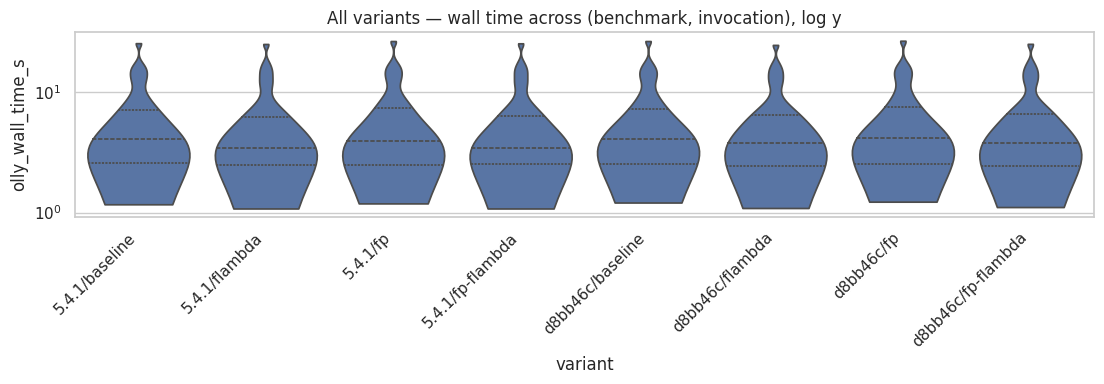

In [6]:
# All-variants wall-time violin — collapsed across benchmarks. One panel
# per variant, showing the per-(benchmark × invocation) wall-time spread.
# Mostly useful for spotting a variant whose distribution is dramatically
# shifted from the others.
if n_invocations <= 1:
    print("Only one invocation per cell — violin would just be dots; skipping.")
else:
    fig, ax = plt.subplots(figsize=(max(8, 1.4 * len(all_variants)), 4))
    sns.violinplot(
        data=df, x="variant", y="olly_wall_time_s",
        order=all_variants, ax=ax, cut=0, inner="quartile", density_norm="width",
    )
    ax.set_yscale("log")
    ax.set_title("All variants — wall time across (benchmark, invocation), log y")
    for label in ax.get_xticklabels():
        label.set_rotation(45); label.set_horizontalalignment("right")
    plt.tight_layout()
    plt.show()

### Per-benchmark operating envelope

For each benchmark, aggregate wall time / GC overhead / collection counts across all variants × invocations and check against `ENVELOPE` (top of notebook). Benchmarks falling outside the envelope are candidates for input tuning or `tag: slow`. Sorted by number of envelope violations — most-flagged first.

Flags:

- **TOO_SHORT** — median wall-time below `wall_min_s`. Startup overhead dominates; consider running more invocations or a bigger input.
- **TOO_LONG** — median wall-time above `wall_max_s`. Iteration cost is bad; smaller input, or accept and tag `slow`.
- **NO_GC_PRESSURE** — median GC overhead < `gc_overhead_min_pct`. Workload doesn't exercise the GC much; if the benchmark is meant to test GC behaviour, the input is wrong.
- **GC_PATHOLOGICAL** — median GC overhead > `gc_overhead_max_pct`. Either by design (stress benchmark) or wrong heap tuning.
- **FEW_MAJOR_COLLECTIONS** — fewer than `major_collections_min` major GCs. Same diagnosis: workload too small to engage major GC.
- **HIGH_VARIANCE** — relative IQR > `iqr_relative_max`. Measurement is too noisy to trust without more invocations or better isolation.

In [7]:
# Per-benchmark operating envelope check.
def _health_row(g: pd.DataFrame) -> pd.Series:
    wall   = g["olly_wall_time_s"].dropna()
    gc_pct = g["olly_gc_overhead_pct"].dropna()
    major  = g["major_collections"].dropna()
    minor  = g["minor_collections"].dropna()
    rss    = g["max_rss_mb"].dropna()

    wall_med = wall.median() if len(wall) else np.nan
    iqr      = (wall.quantile(0.75) - wall.quantile(0.25)) if len(wall) else np.nan
    rel_iqr  = iqr / wall_med if wall_med else np.nan
    gc_med   = gc_pct.median() if len(gc_pct) else np.nan
    major_med = major.median() if len(major) else np.nan
    minor_med = minor.median() if len(minor) else np.nan
    rss_med  = rss.median() if len(rss) else np.nan

    flags = []
    if pd.notna(wall_med) and wall_med < ENVELOPE["wall_min_s"]:
        flags.append("TOO_SHORT")
    if pd.notna(wall_med) and wall_med > ENVELOPE["wall_max_s"]:
        flags.append("TOO_LONG")
    if pd.notna(gc_med) and gc_med < ENVELOPE["gc_overhead_min_pct"]:
        flags.append("NO_GC_PRESSURE")
    if pd.notna(gc_med) and gc_med > ENVELOPE["gc_overhead_max_pct"]:
        flags.append("GC_PATHOLOGICAL")
    if pd.notna(major_med) and major_med < ENVELOPE["major_collections_min"]:
        flags.append("FEW_MAJOR_COLLECTIONS")
    if pd.notna(rel_iqr) and rel_iqr > ENVELOPE["iqr_relative_max"]:
        flags.append("HIGH_VARIANCE")

    return pd.Series({
        "wall_s":      round(wall_med, 2)   if pd.notna(wall_med) else None,
        "gc_pct":      round(gc_med, 1)     if pd.notna(gc_med)   else None,
        "minor_col":   int(minor_med)       if pd.notna(minor_med) else None,
        "major_col":   int(major_med)       if pd.notna(major_med) else None,
        "rss_mb":      int(rss_med)         if pd.notna(rss_med)  else None,
        "iqr_pct":     round(rel_iqr * 100, 1) if pd.notna(rel_iqr) else None,
        "n_flags":     len(flags),
        "flags":       ", ".join(flags) if flags else "—",
    })

health = (
    df.groupby("benchmark")
      .apply(_health_row, include_groups=False)
      .sort_values(["n_flags", "wall_s"], ascending=[False, False])
)

n_clean   = int((health["n_flags"] == 0).sum())
n_flagged = int((health["n_flags"] > 0).sum())
print(f"Envelope: wall {ENVELOPE['wall_min_s']}-{ENVELOPE['wall_max_s']}s, "
      f"GC {ENVELOPE['gc_overhead_min_pct']}-{ENVELOPE['gc_overhead_max_pct']}%, "
      f">={ENVELOPE['major_collections_min']} major col, "
      f"<={ENVELOPE['iqr_relative_max']*100:.0f}% relative IQR")
print(f"In envelope: {n_clean} / {len(health)}.   Flagged: {n_flagged}.")
print()
display(health.drop(columns="n_flags"))

Envelope: wall 0.5-60.0s, GC 1.0-50.0%, >=5 major col, <=10% relative IQR
In envelope: 23 / 36.   Flagged: 13.



,wall_s,gc_pct,minor_col,major_col,rss_mb,iqr_pct,flags
benchmark,,,,,,,
liq_video_frames_full,4.79,68.0,1472,981,181,15.3,"GC_PATHOLOGICAL, HIGH_VARIANCE"
liq_video_frames_page,3.62,82.8,1472,981,181,26.4,"GC_PATHOLOGICAL, HIGH_VARIANCE"
coqc_corelib_stress,17.24,93.9,6562,25,1084,1.3,GC_PATHOLOGICAL
liq_parse_typecheck,7.44,24.4,26580,12750,49,45.5,HIGH_VARIANCE
pplacer_testsuite,6.20,79.7,8969,3517,75,3.0,GC_PATHOLOGICAL
alt_ergo_yyll,6.02,7.1,7509,18,308,10.5,HIGH_VARIANCE
jsoo,3.23,32.6,2173,30,308,10.5,HIGH_VARIANCE
owl_gc,3.16,39.0,59269,45376,139,34.9,HIGH_VARIANCE
liq_video_frames_pool,3.02,91.2,1473,982,109,6.3,GC_PATHOLOGICAL


## 4. Per-comparison detail

One subsection per comparison block. Each is restricted to the block's variants — so a 4-variant block renders 4-bar grouped charts, not 8. Helpers below; the loop applies them across every block.

In [8]:
def _block_variants(cmp: Comparison) -> list[str]:
    return sorted({v for pair in cmp.pairs for v in pair})


def _facet_grid_shape(n: int, cols: int = 5):
    return (n + cols - 1) // cols, cols


def _bar_per_benchmark(sub_df, variants, metric, ylabel, title, color):
    rows, cols = _facet_grid_shape(len(benches))
    fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 2.8 * rows), sharey=False)
    for ax, bench in zip(axes.flat, benches):
        s = sub_df[sub_df["benchmark"] == bench]
        if metric not in s.columns or s[metric].isna().all():
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(bench, fontsize=9)
            continue
        sns.barplot(
            data=s, x="variant", y=metric,
            order=variants, ax=ax, errorbar=("pi", 50), color=color,
        )
        ax.set_title(bench, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)
        for label in ax.get_xticklabels():
            label.set_rotation(60); label.set_horizontalalignment("right")
            label.set_fontsize(7)
    for ax in axes.flat[len(benches):]:
        ax.axis("off")
    fig.suptitle(title, y=1.00)
    plt.tight_layout()
    plt.show()


def _stacked_mutator_gc(sub_df, variants, title):
    rows, cols = _facet_grid_shape(len(benches))
    fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 2.8 * rows), sharey=False)
    agg_med = sub_df.groupby(["benchmark", "variant"]).agg(
        wall=("olly_wall_time_s", "median"),
        gc=("olly_gc_time_s", "median"),
    ).reset_index()
    agg_med["mutator"] = agg_med["wall"] - agg_med["gc"]
    for ax, bench in zip(axes.flat, benches):
        sub = agg_med[agg_med["benchmark"] == bench].set_index("variant").reindex(variants)
        x = np.arange(len(variants))
        ax.bar(x, sub["mutator"], color="#4c72b0", label="mutator")
        ax.bar(x, sub["gc"], bottom=sub["mutator"], color="#dd8452", label="GC")
        ax.set_title(bench, fontsize=9)
        ax.set_xticks(x)
        ax.set_xticklabels(variants, rotation=60, ha="right", fontsize=7)
        ax.set_ylabel("s", fontsize=8)
    for ax in axes.flat[len(benches):]:
        ax.axis("off")
    axes.flat[0].legend(loc="upper left", fontsize=8)
    fig.suptitle(title, y=1.00)
    plt.tight_layout()
    plt.show()


def _latency_ecdf(sub_df, variants, title):
    PCT_COLS = [
        (50.0, "olly_p50_latency_ms"),
        (95.0, "olly_p95_latency_ms"),
        (99.0, "olly_p99_latency_ms"),
        (99.9, "olly_p999_latency_ms"),
    ]
    available = [(p, c) for p, c in PCT_COLS
                 if c in sub_df.columns and sub_df[c].notna().any()]
    if not available:
        print("  (no latency percentile columns — skipping ECDF)")
        return
    rows, cols = _facet_grid_shape(len(benches))
    fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 2.8 * rows), sharey=False)
    palette = sns.color_palette(n_colors=len(variants))
    for ax, bench in zip(axes.flat, benches):
        for vi, variant in enumerate(variants):
            s = sub_df[(sub_df["benchmark"] == bench) & (sub_df["variant"] == variant)]
            if s.empty:
                continue
            xs = [s[c].median() for _, c in available]
            ys = [p / 100.0 for p, _ in available]
            if not any(np.isfinite(xs)):
                continue
            ax.plot(xs, ys, marker="o", linewidth=1, markersize=3,
                    color=palette[vi], label=variant)
        ax.set_title(bench, fontsize=9)
        ax.set_xlabel("latency (ms)", fontsize=8)
        ax.set_ylabel("cumulative", fontsize=8)
        ax.set_ylim(0, 1.02)
    for ax in axes.flat[len(benches):]:
        ax.axis("off")
    axes.flat[0].legend(loc="lower right", fontsize=6)
    fig.suptitle(title, y=1.00)
    plt.tight_layout()
    plt.show()


def _wall_time_violins(sub_df, variants, title):
    if invocations_per_cell.max() <= 1:
        print("  (single invocation per cell — violins skipped)")
        return
    rows, cols = _facet_grid_shape(len(benches))
    fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 2.8 * rows), sharey=False)
    for ax, bench in zip(axes.flat, benches):
        s = sub_df[sub_df["benchmark"] == bench]
        sns.violinplot(
            data=s, x="variant", y="olly_wall_time_s",
            order=variants, ax=ax, cut=0, inner="point", density_norm="width",
        )
        ax.set_title(bench, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("s")
        for label in ax.get_xticklabels():
            label.set_rotation(60); label.set_horizontalalignment("right")
            label.set_fontsize(7)
    for ax in axes.flat[len(benches):]:
        ax.axis("off")
    fig.suptitle(title, y=1.00)
    plt.tight_layout()
    plt.show()


def render_block_b(cmp: Comparison, df, benches):
    block_variants = _block_variants(cmp)
    sub = df[df["variant"].isin(block_variants)]

    display(Markdown(f"### {cmp.label}"))
    pair_lines = "\n".join(f"- `{a}`  →  `{b}`" for a, b in cmp.pairs)
    display(Markdown(
        f"**Variants ({len(block_variants)}):** {', '.join('`'+v+'`' for v in block_variants)}\n\n"
        f"**Pairs:**\n\n{pair_lines}"
    ))

    display(Markdown("#### Wall time (raw)"))
    _bar_per_benchmark(sub, block_variants, "olly_wall_time_s",
                       "s", f"{cmp.label} — wall time (median, IQR)", "#4c72b0")

    display(Markdown("#### Mutator vs GC time"))
    _stacked_mutator_gc(sub, block_variants,
                        f"{cmp.label} — wall split: mutator vs GC (median)")

    display(Markdown("#### GC overhead (% of wall)"))
    _bar_per_benchmark(sub, block_variants, "olly_gc_overhead_pct",
                       "GC %", f"{cmp.label} — GC overhead", "#c44e52")

    display(Markdown("#### Latency ECDF"))
    _latency_ecdf(sub, block_variants, f"{cmp.label} — latency ECDF")

    display(Markdown("#### Wall-time distribution per cell"))
    _wall_time_violins(sub, block_variants,
                       f"{cmp.label} — wall-time across invocations")

    display(Markdown("#### Allocation: promoted %"))
    _bar_per_benchmark(sub, block_variants, "promoted_pct",
                       "%", f"{cmp.label} — promoted % (minor → major)", "#8172b2")

    display(Markdown("#### Hardware counters"))
    if "perf_instructions_insn_per_cycle" in sub.columns and sub["perf_instructions_insn_per_cycle"].notna().any():
        _bar_per_benchmark(sub, block_variants, "perf_instructions_insn_per_cycle",
                           "IPC", f"{cmp.label} — IPC", "#4c72b0")
    else:
        print("  (IPC not in this perf group — skipping)")
    if "perf_page-faults_k_sec" in sub.columns and sub["perf_page-faults_k_sec"].notna().any():
        _bar_per_benchmark(sub, block_variants, "perf_page-faults_k_sec",
                           "k/sec", f"{cmp.label} — page-fault rate", "#dd8452")
    else:
        print("  (page-fault rate not in this perf group — skipping)")

### 5.4.1 flag effects

**Variants (4):** `5.4.1/baseline`, `5.4.1/flambda`, `5.4.1/fp`, `5.4.1/fp-flambda`

**Pairs:**

- `5.4.1/baseline`  →  `5.4.1/fp`
- `5.4.1/baseline`  →  `5.4.1/flambda`
- `5.4.1/baseline`  →  `5.4.1/fp-flambda`

#### Wall time (raw)

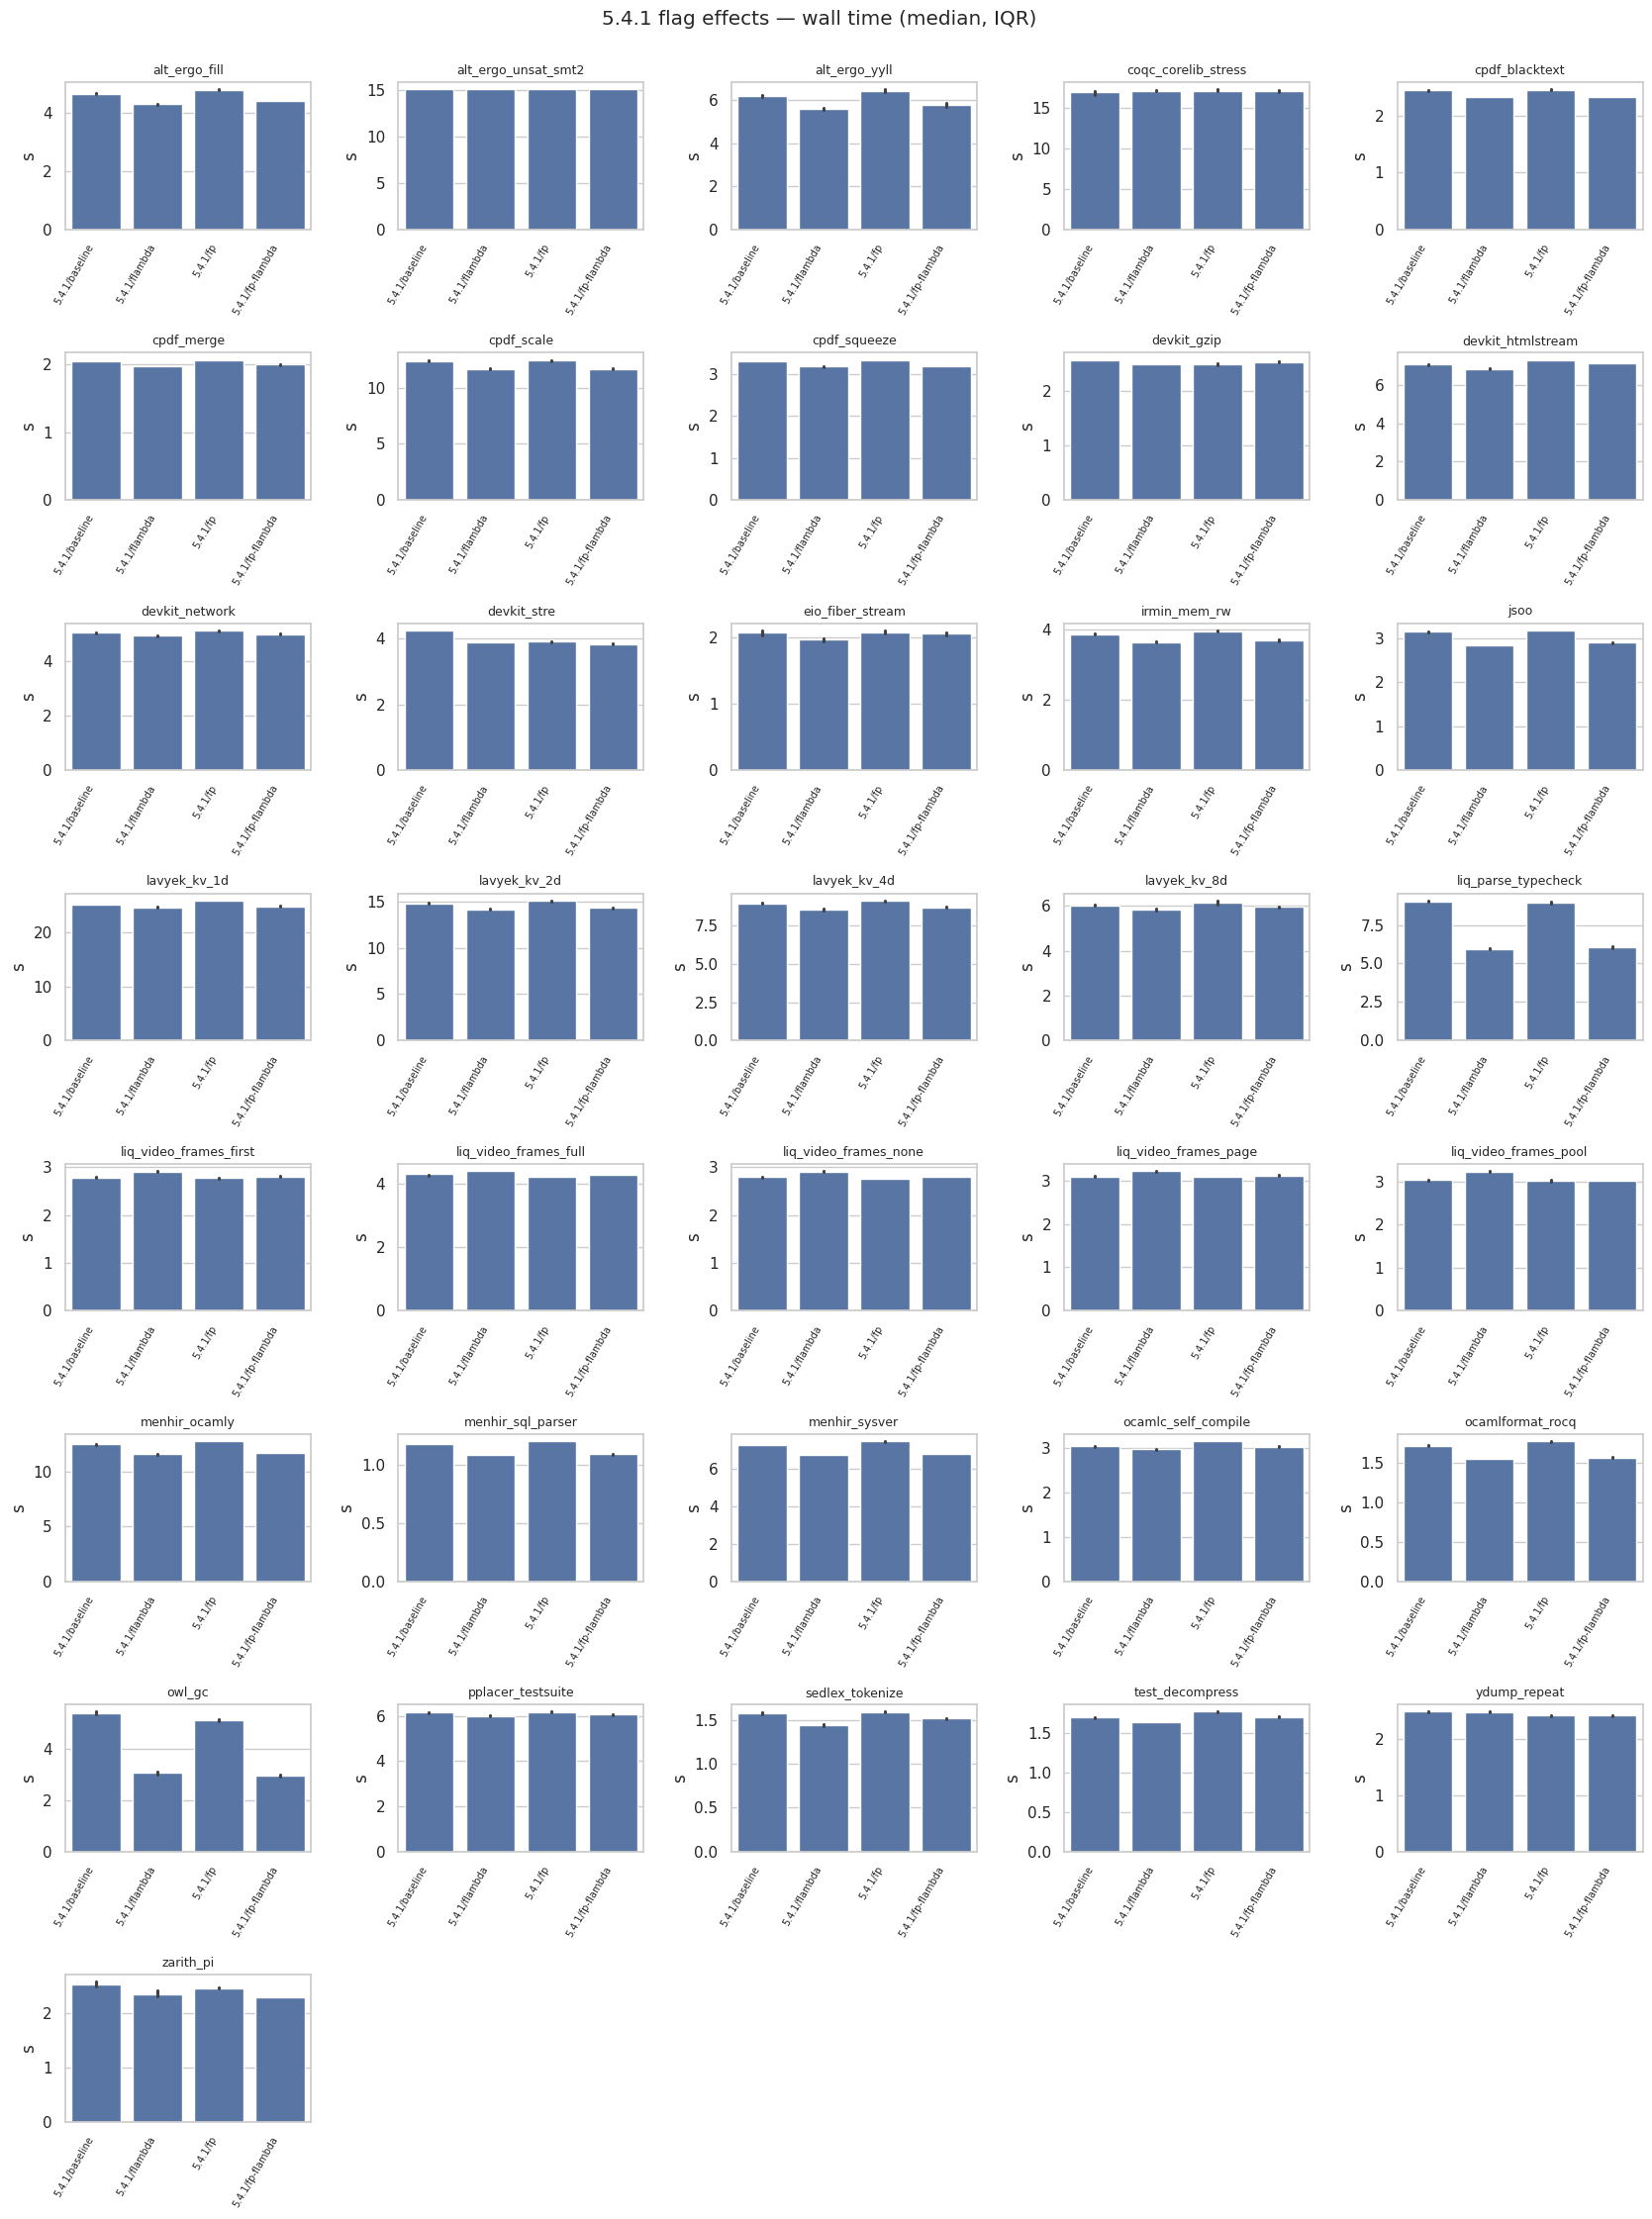

#### Mutator vs GC time

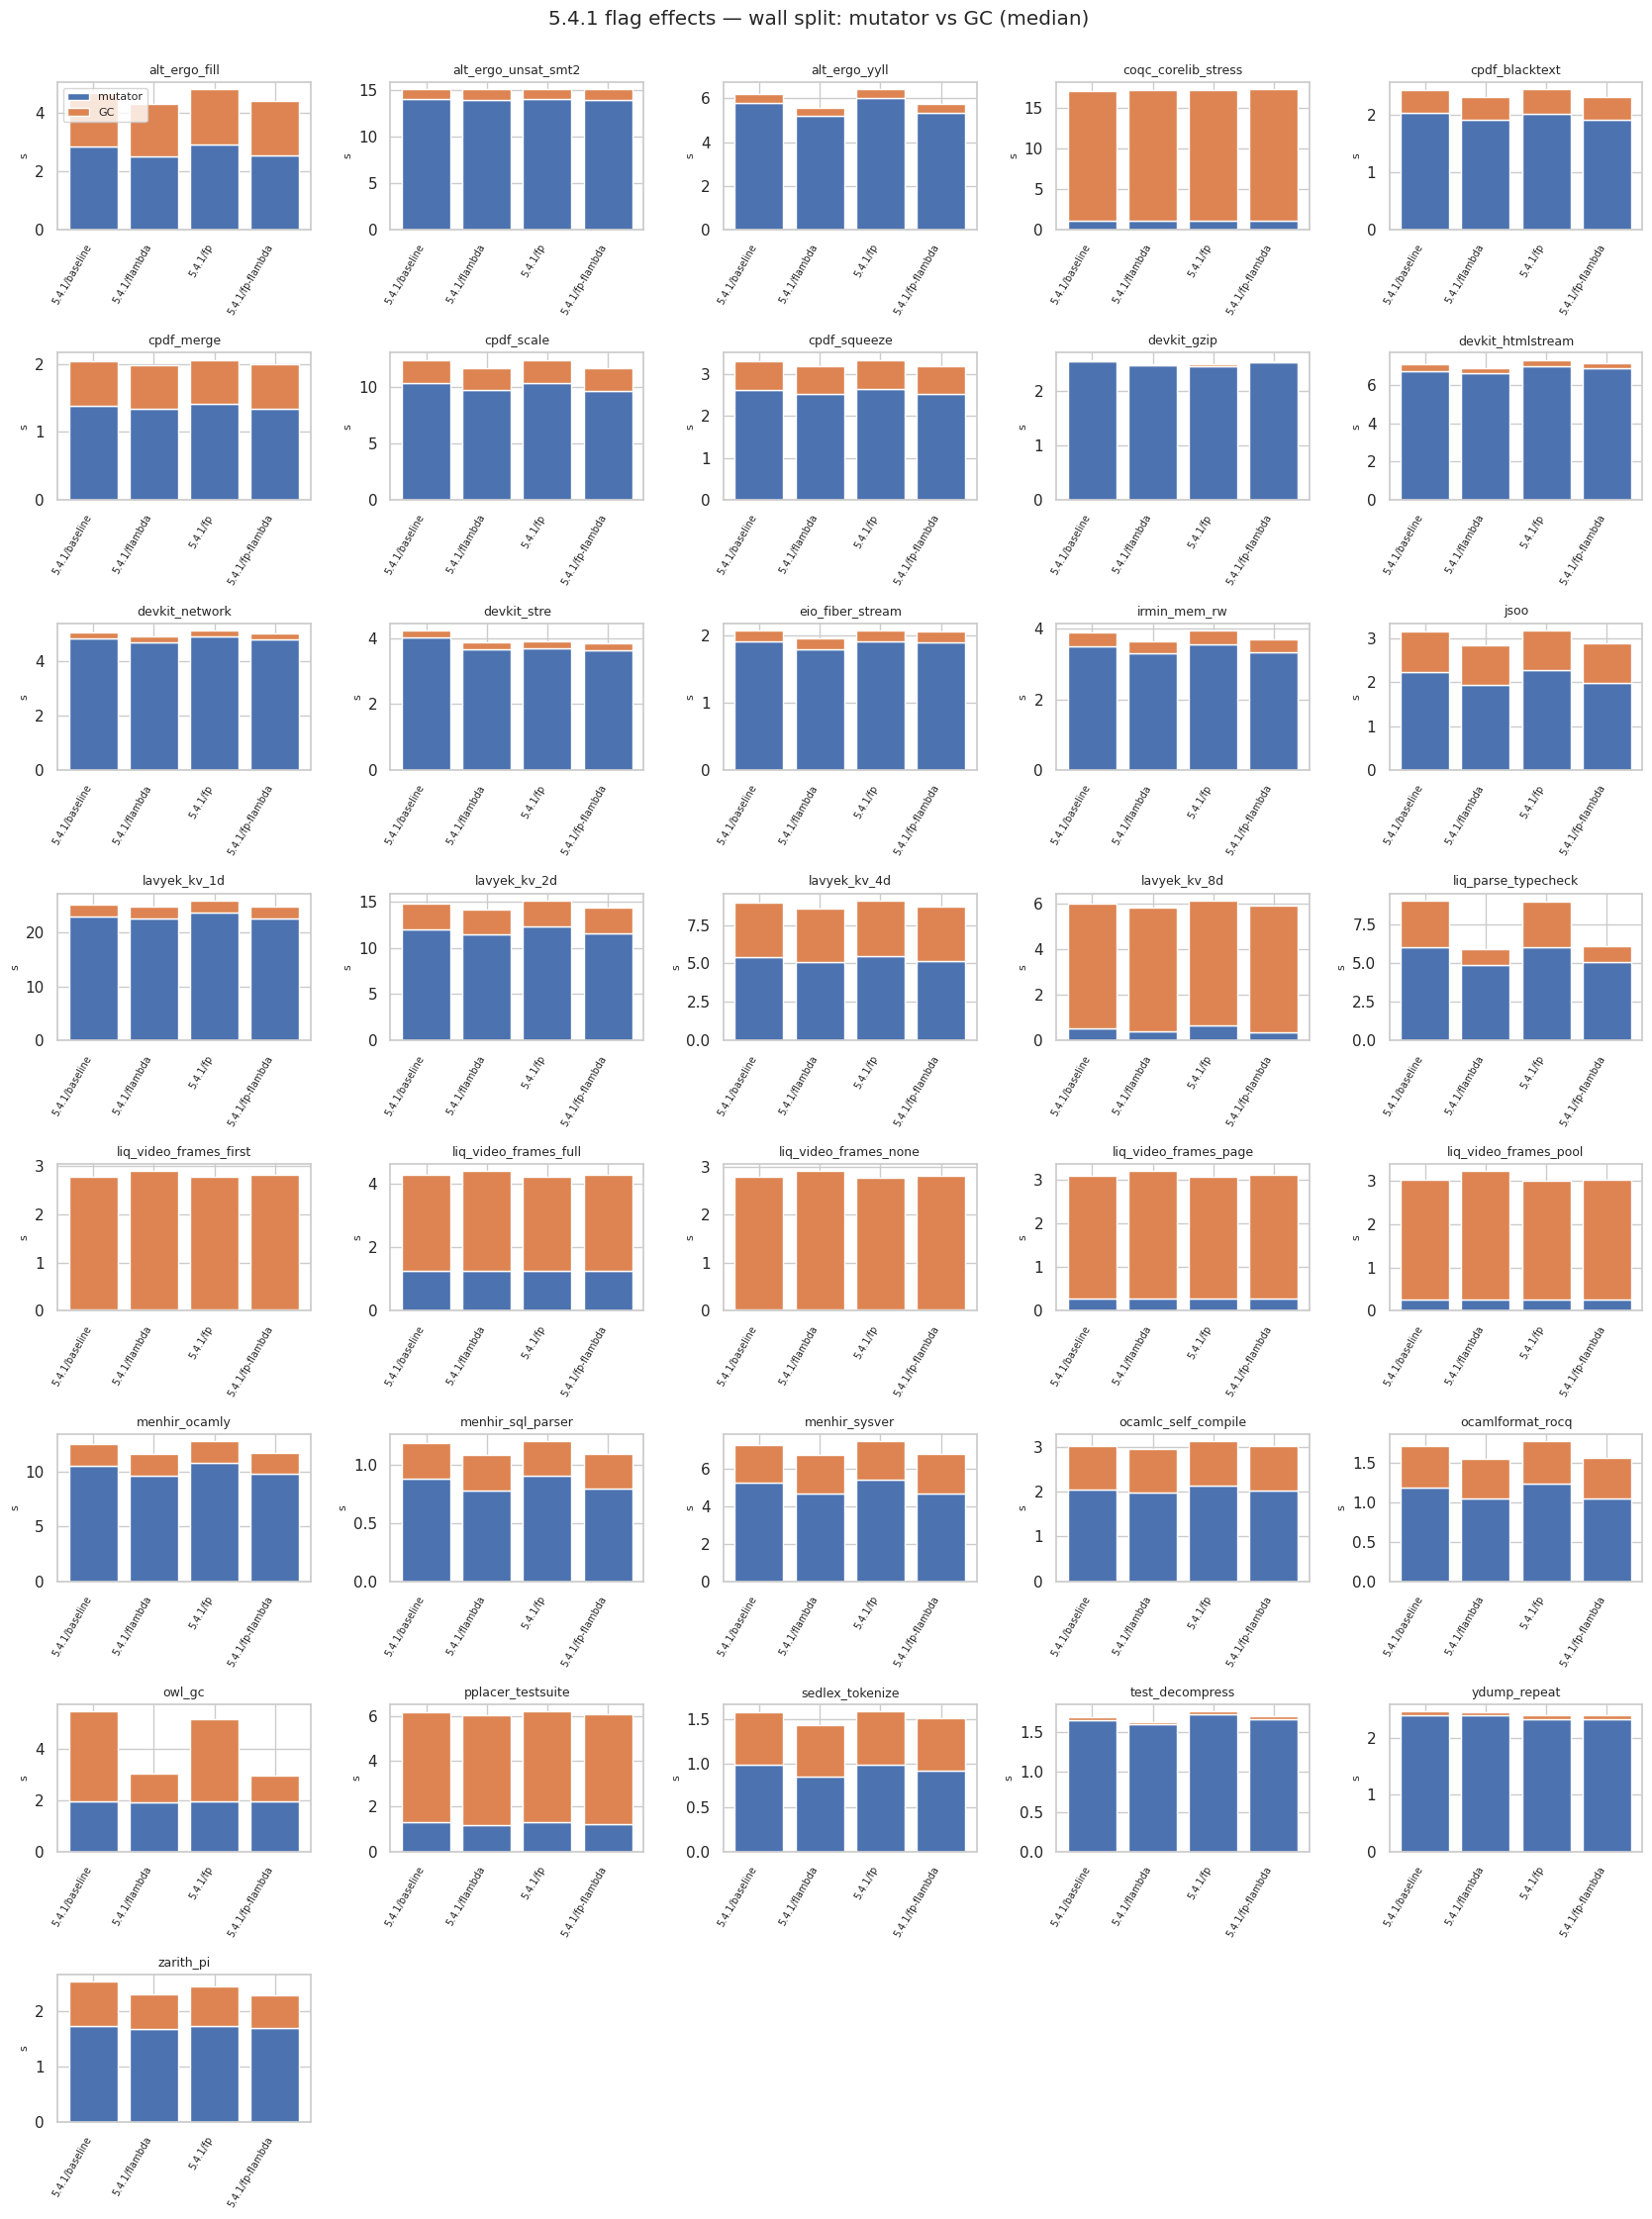

#### GC overhead (% of wall)

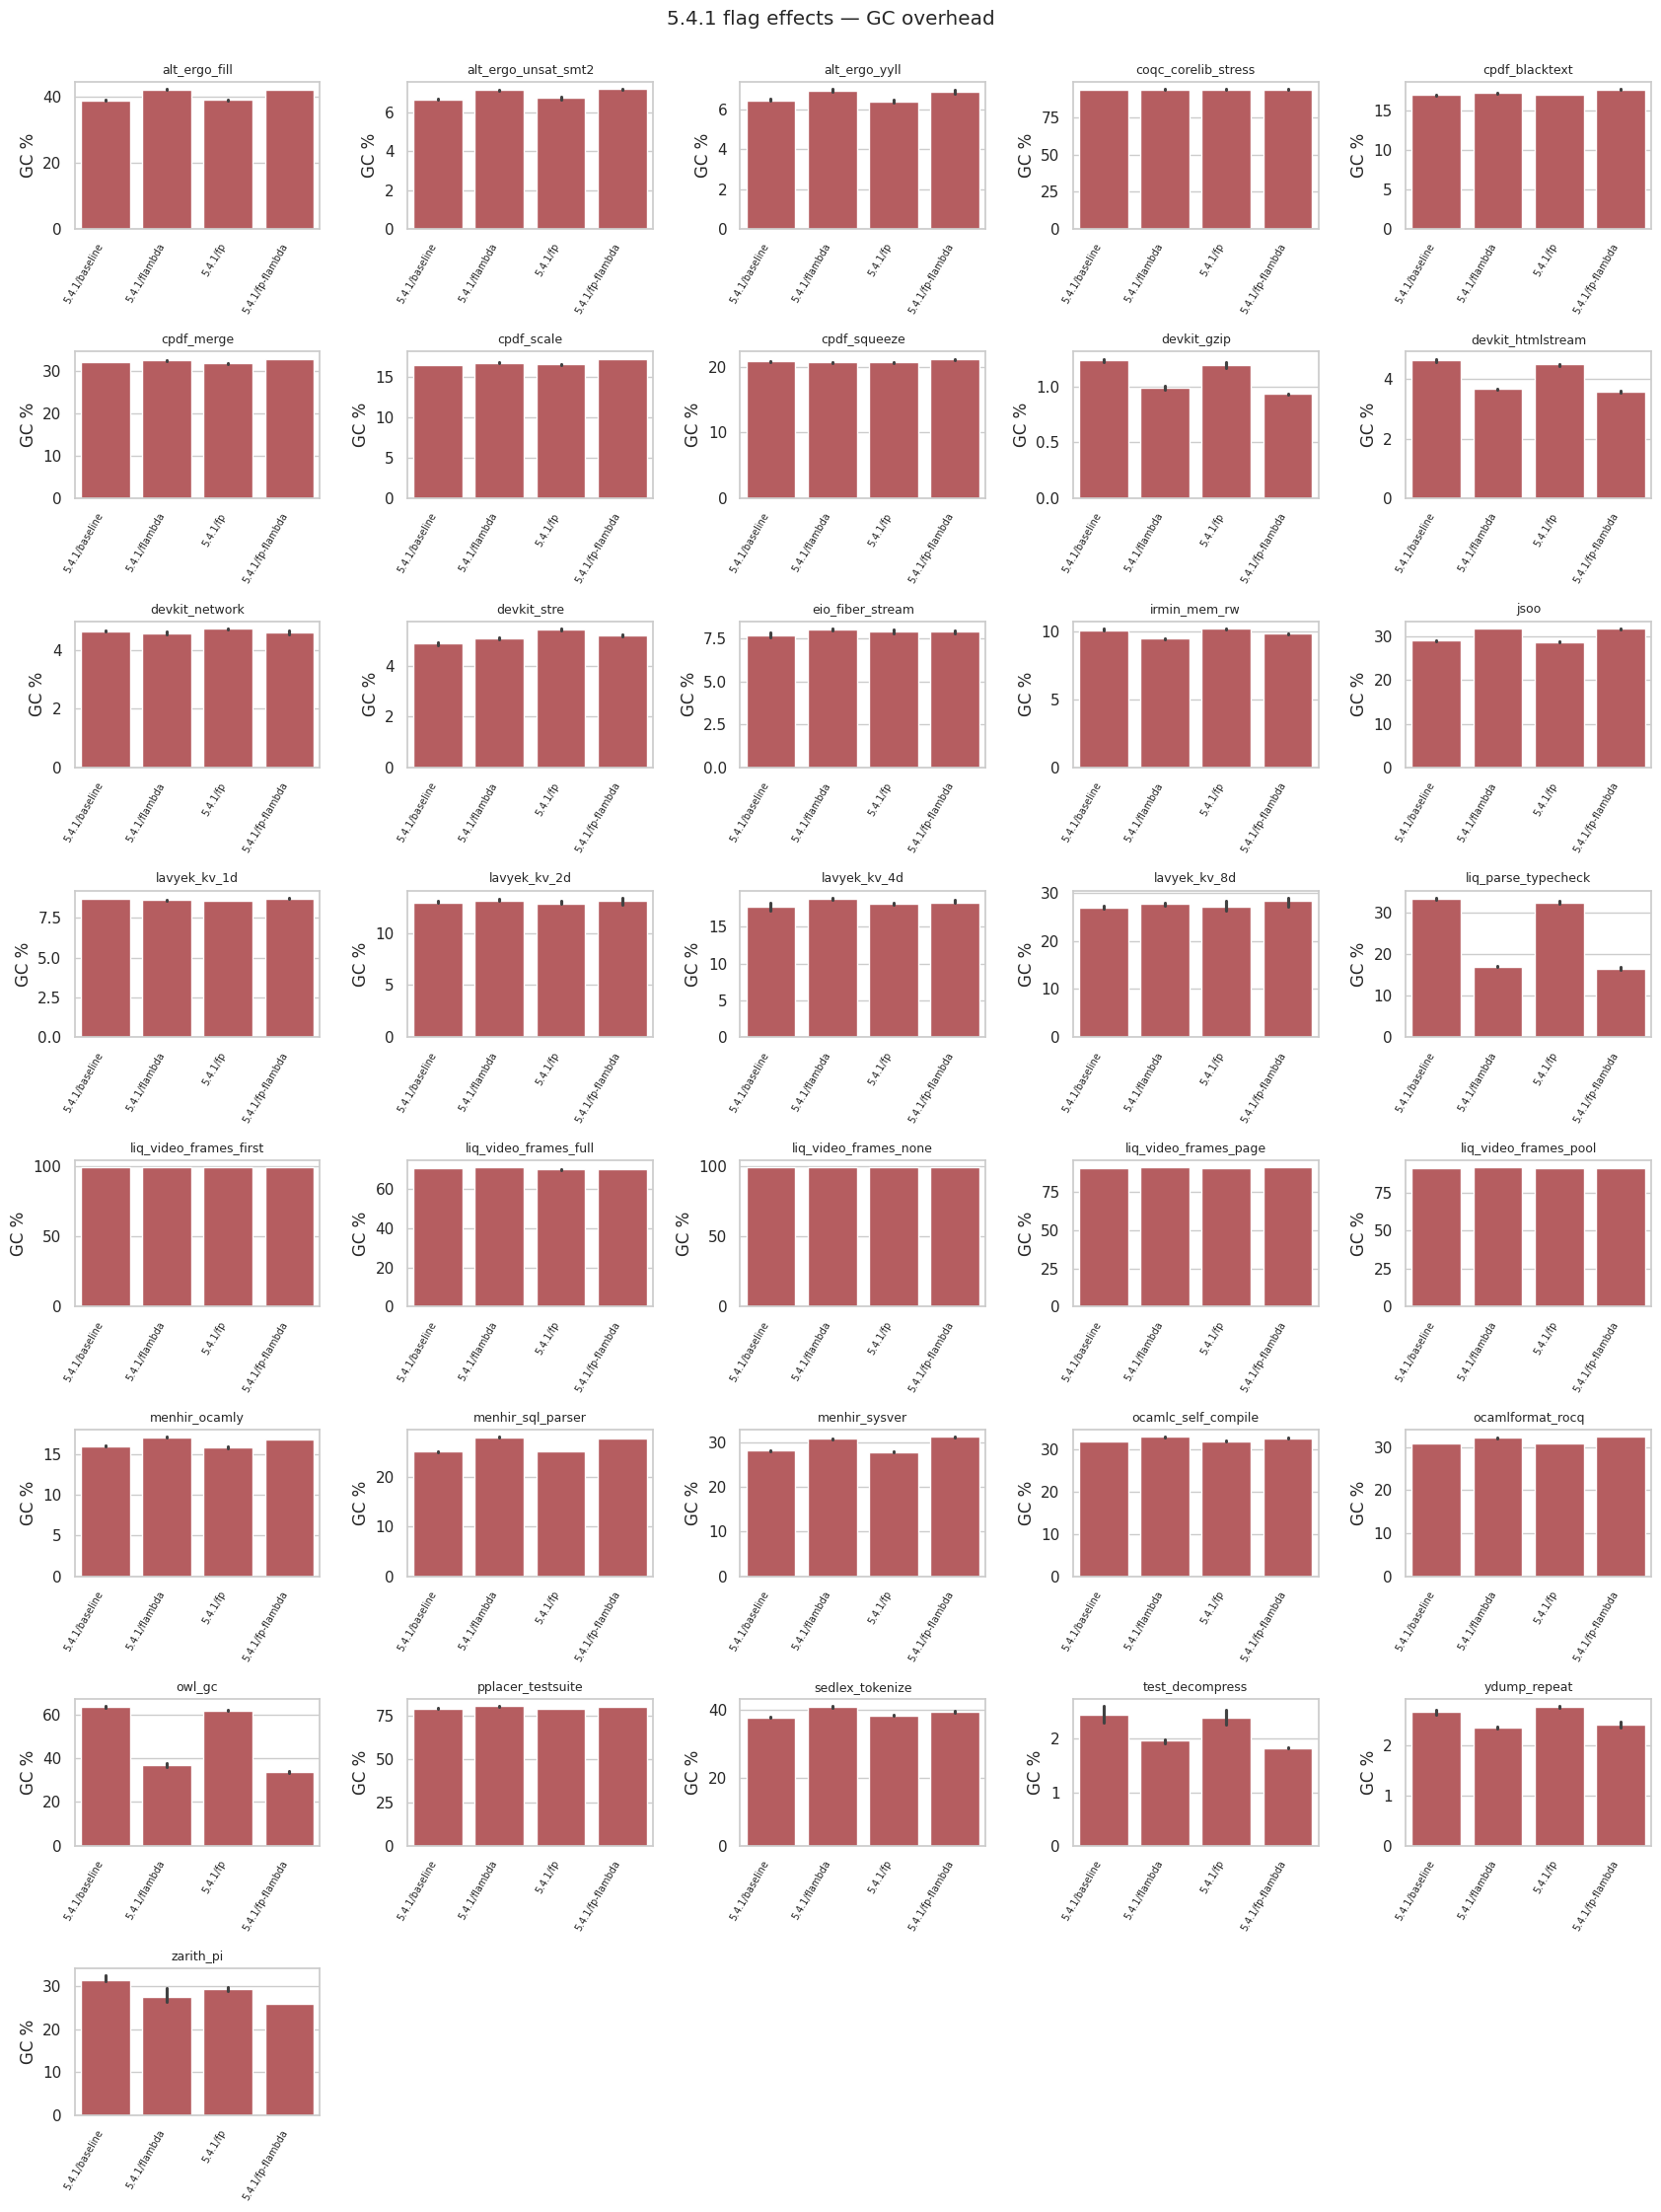

#### Latency ECDF

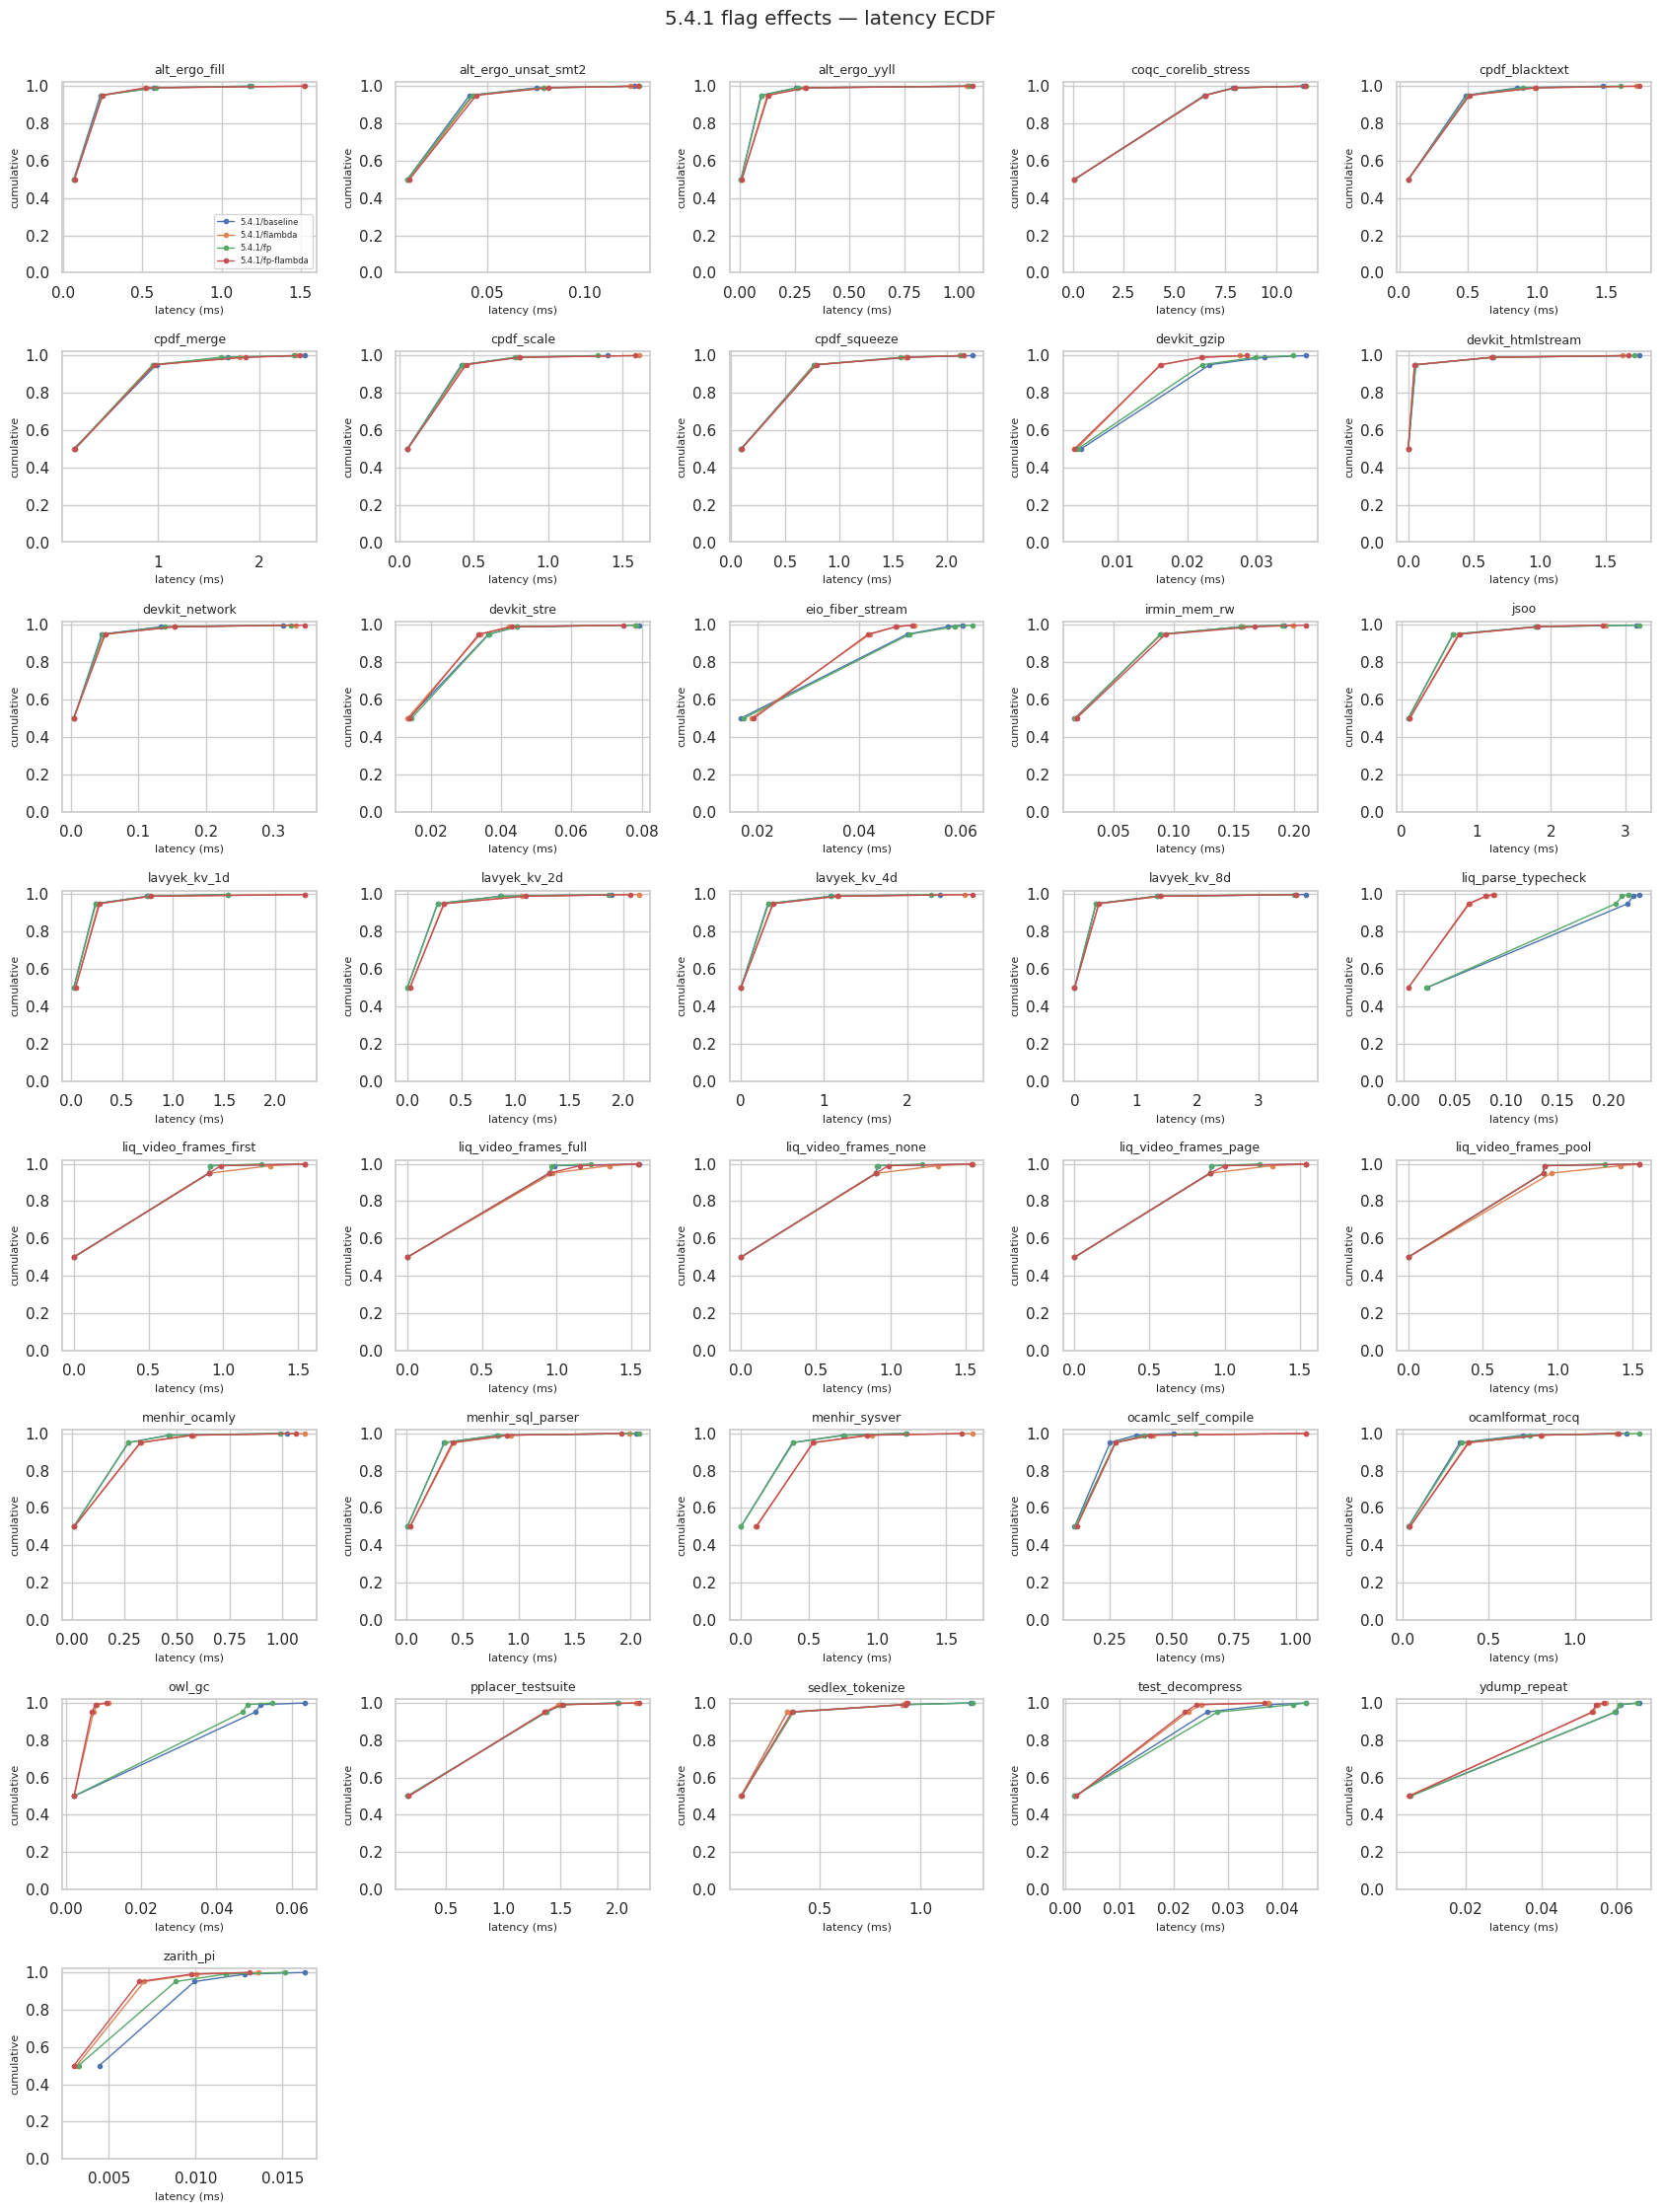

#### Wall-time distribution per cell

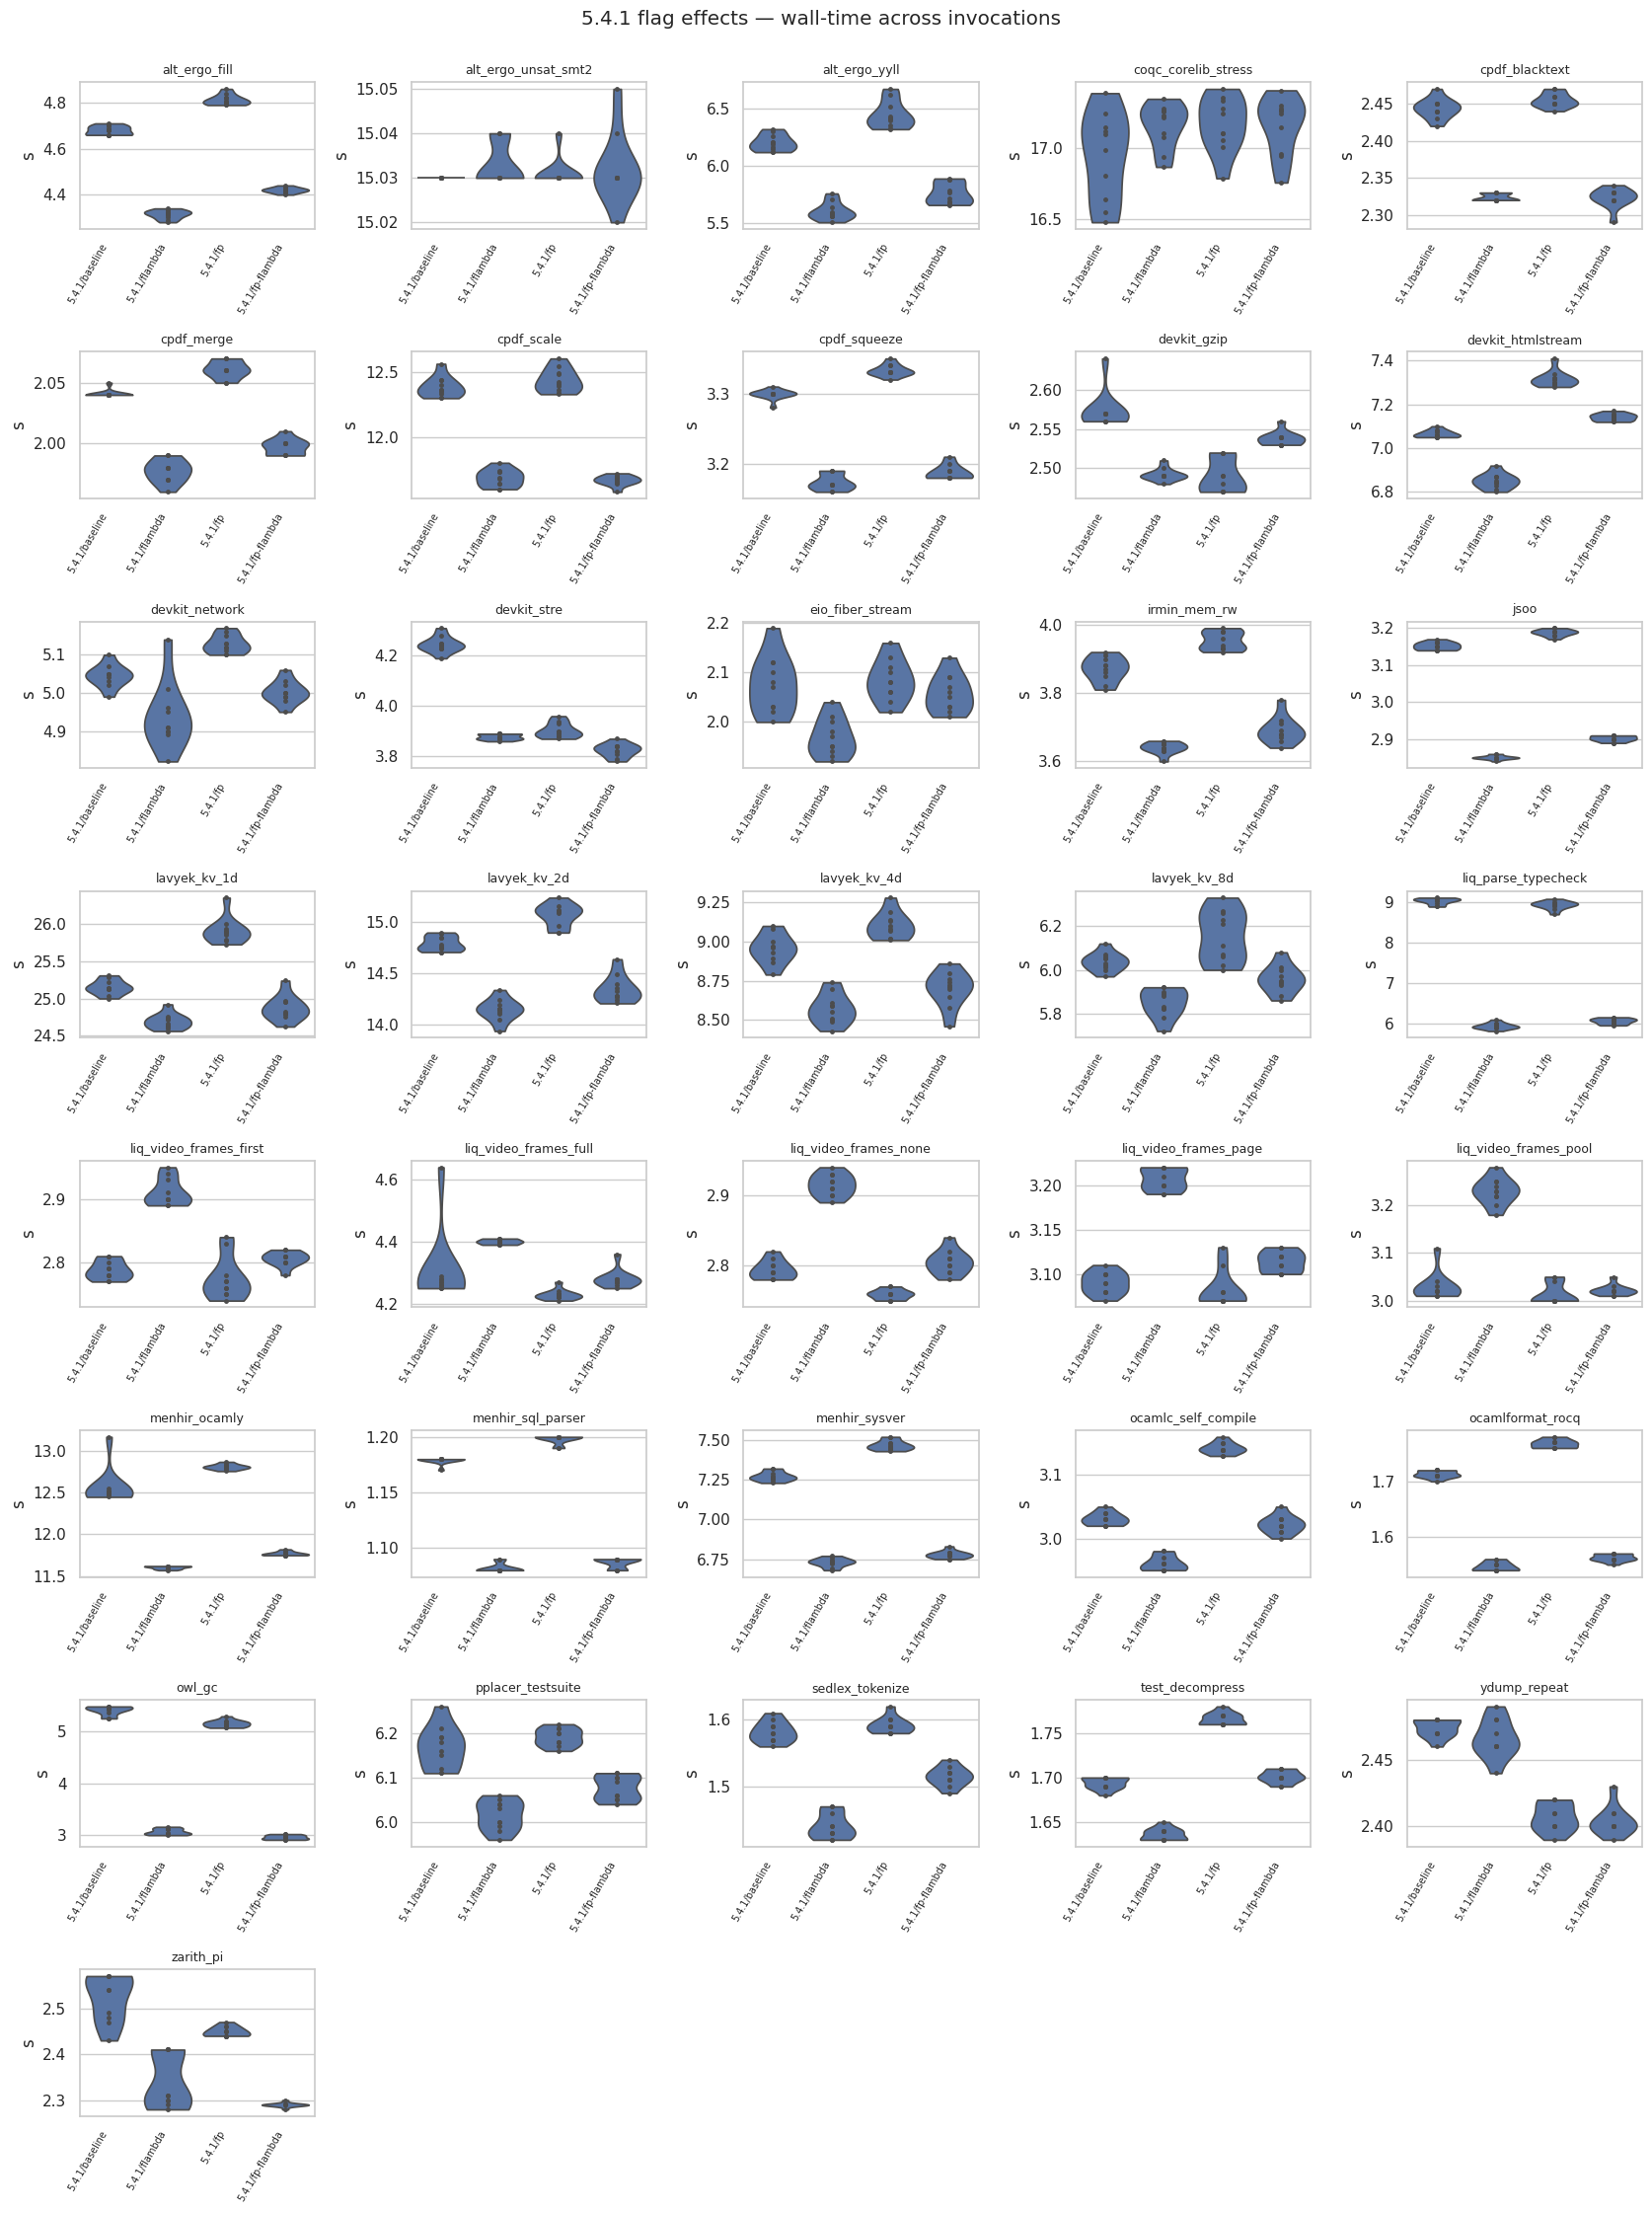

#### Allocation: promoted %

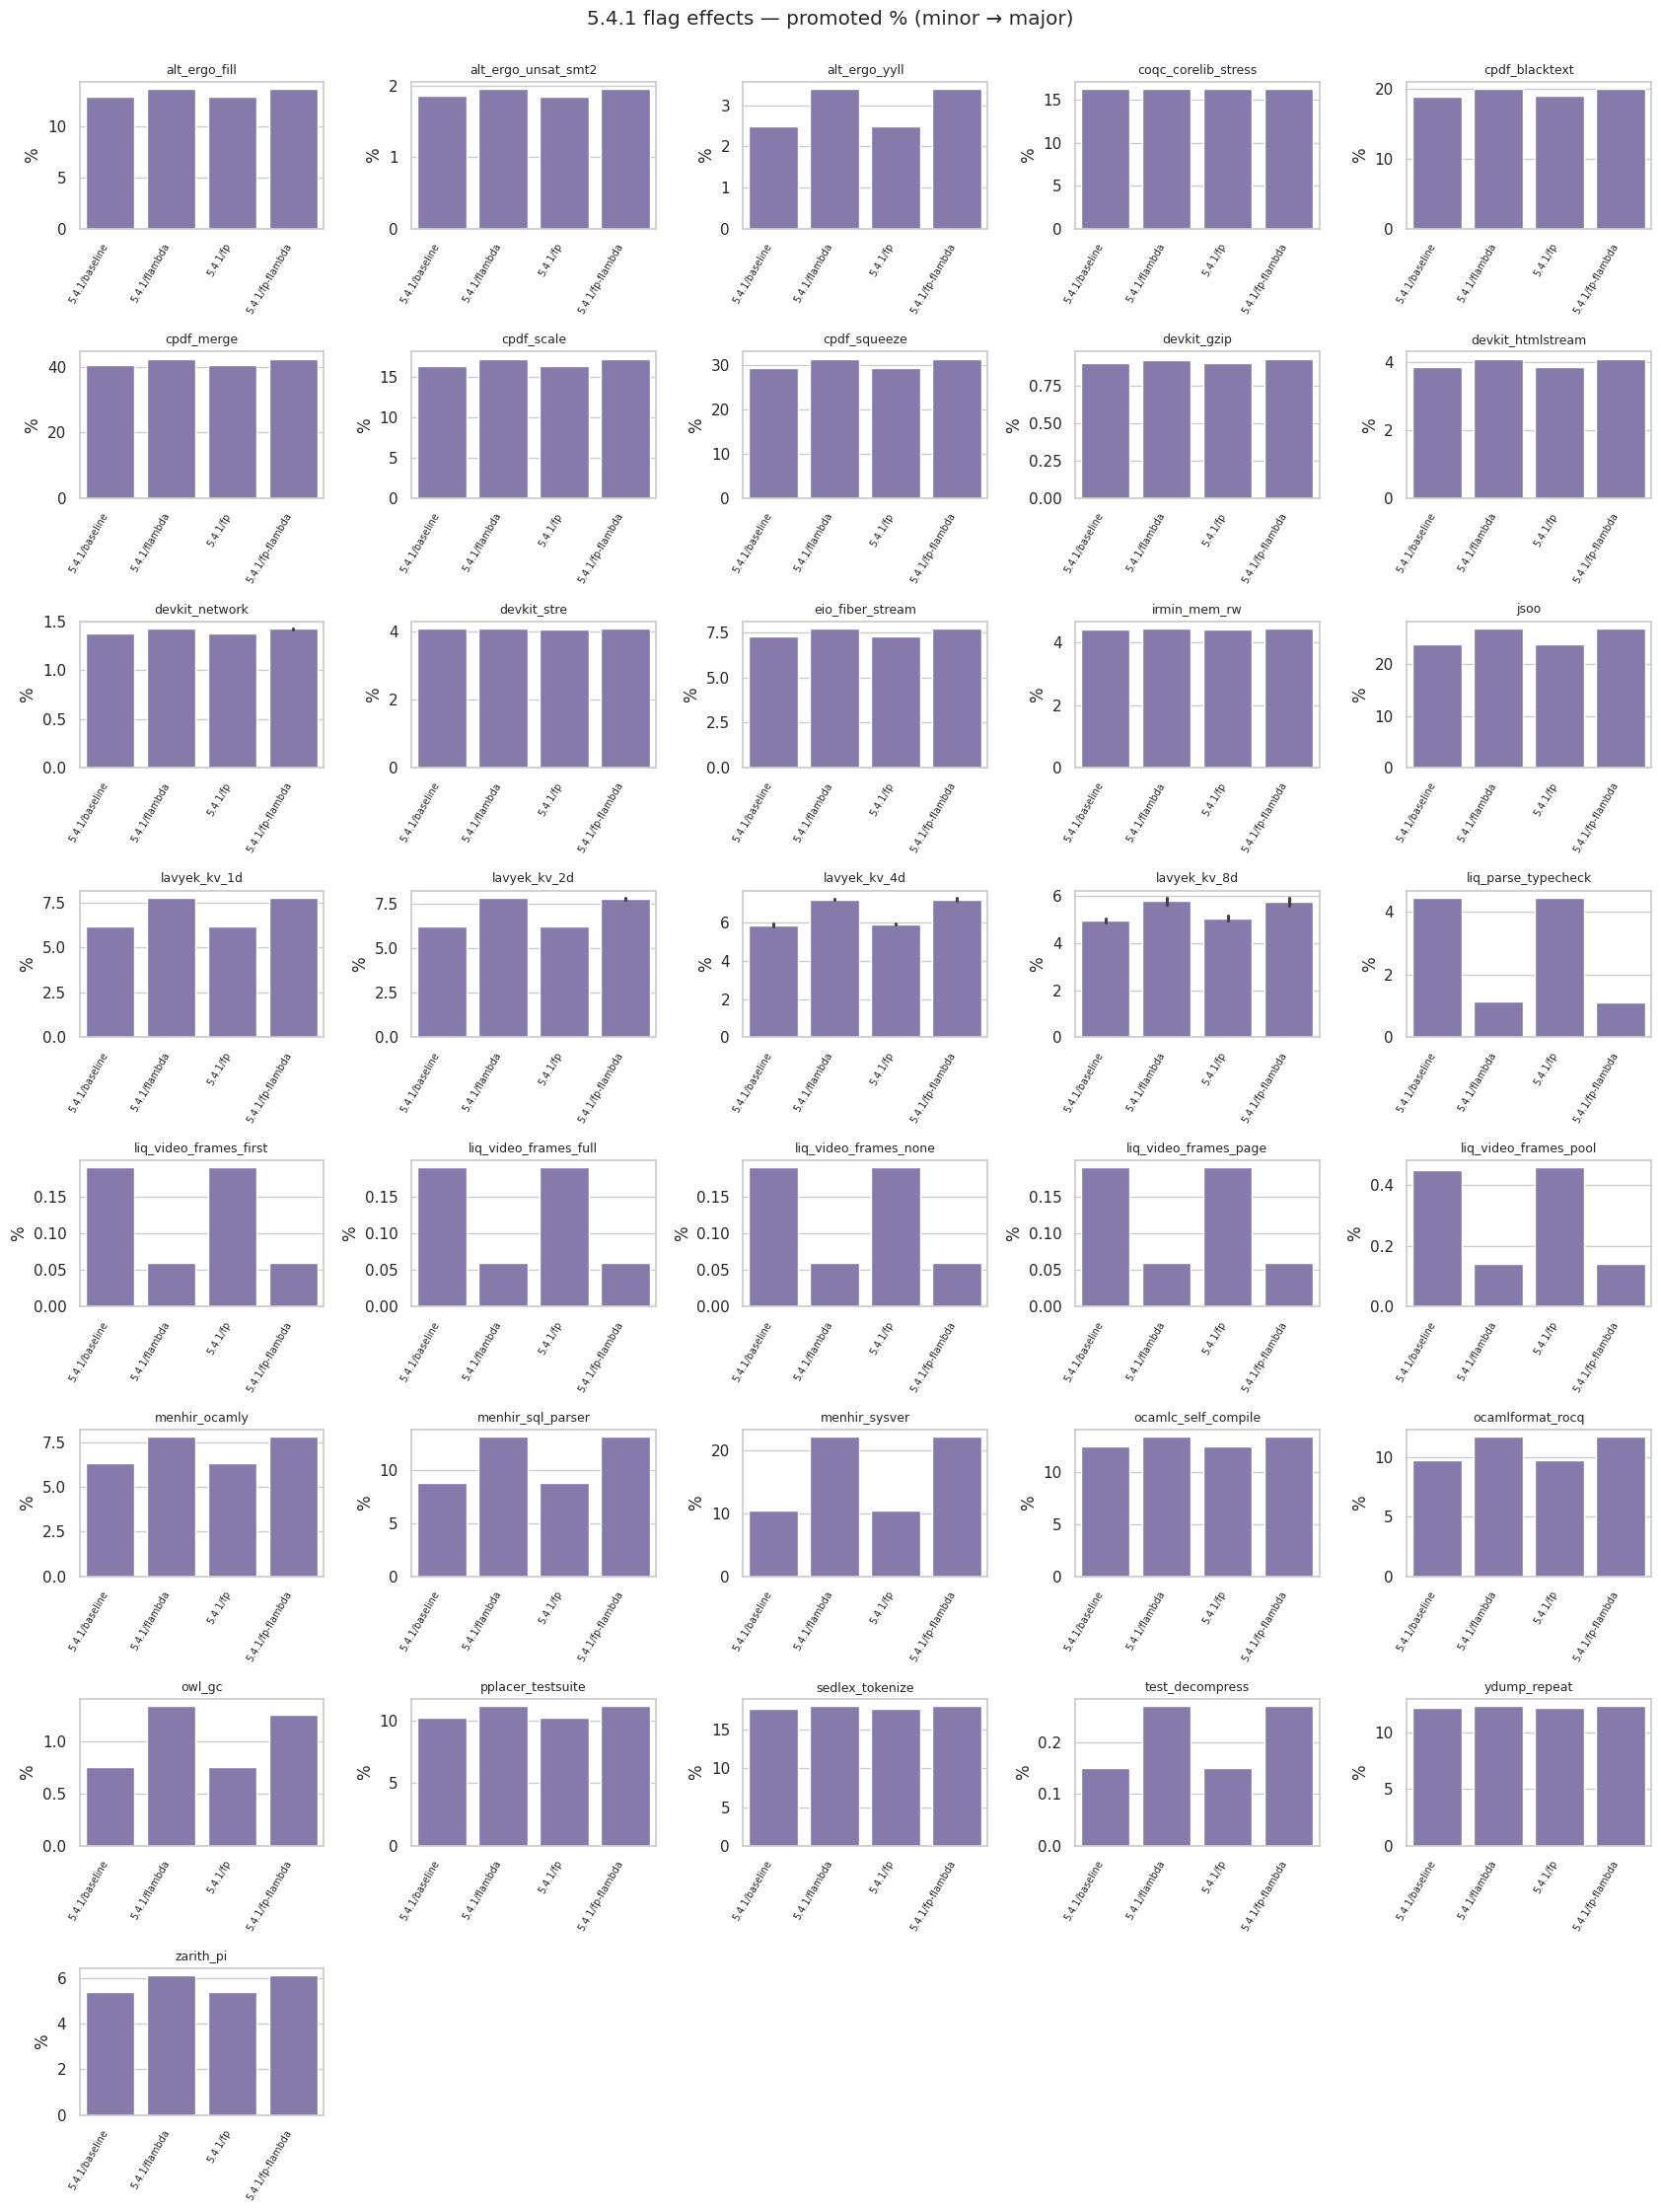

#### Hardware counters

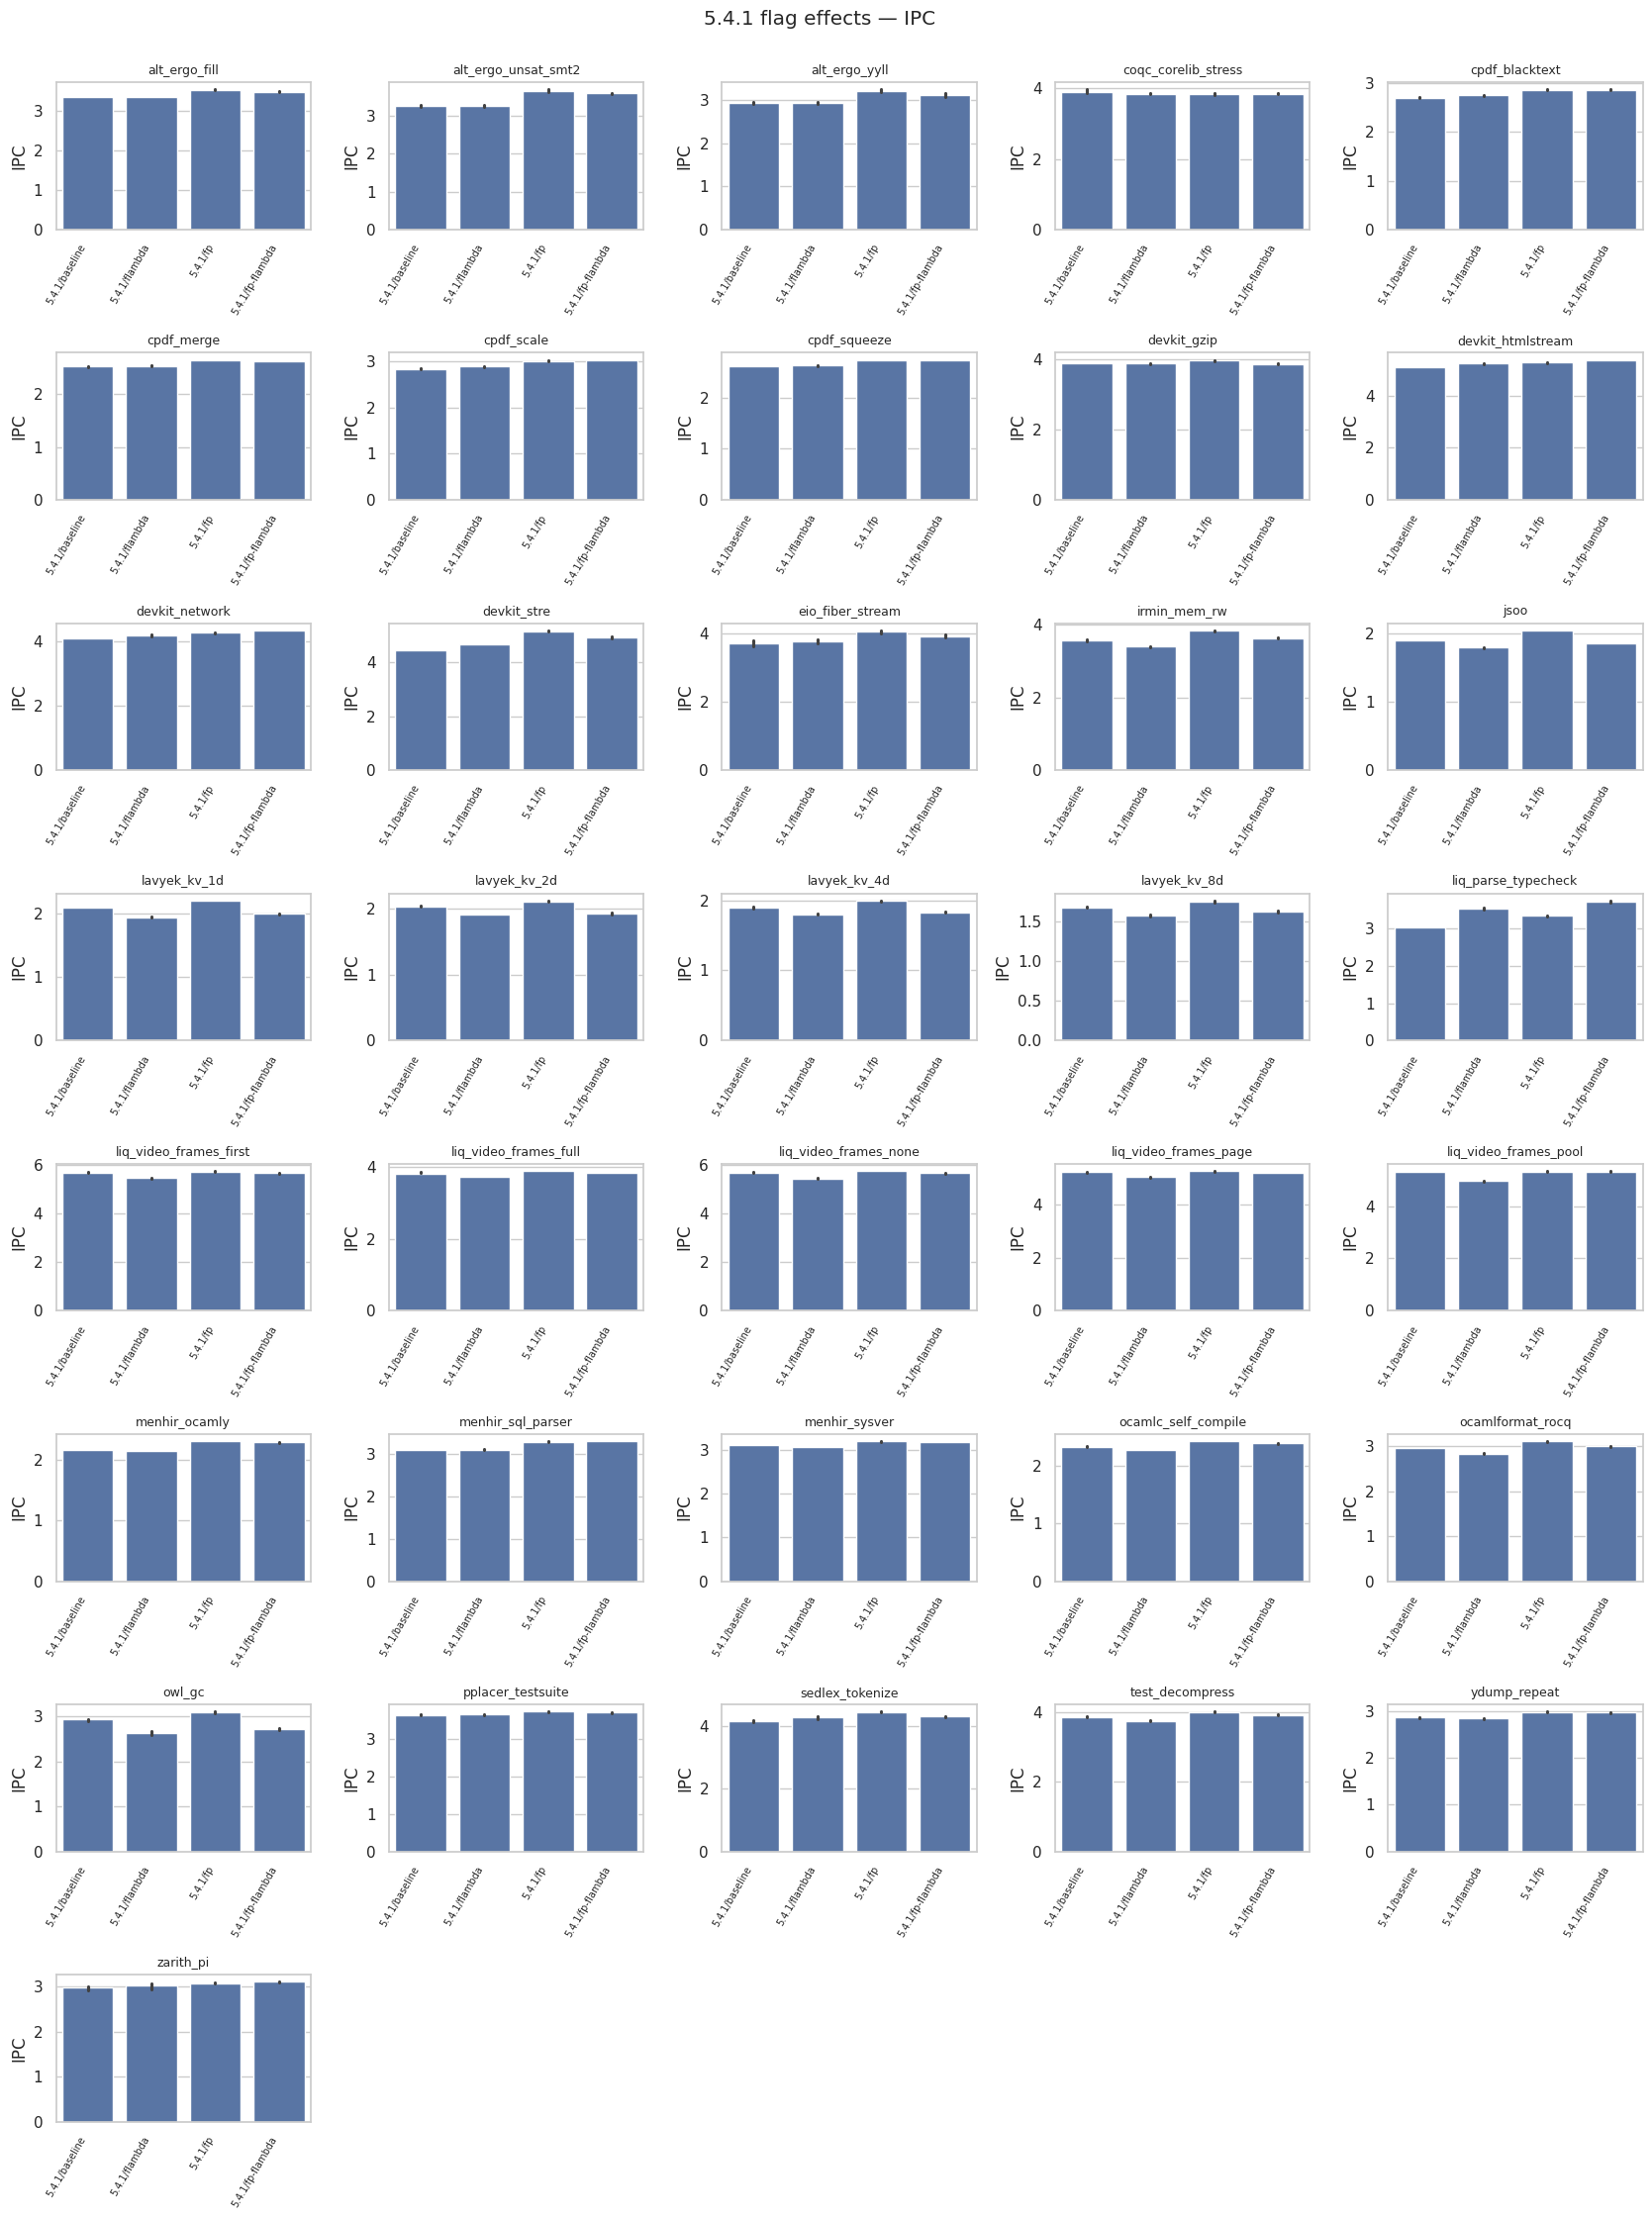

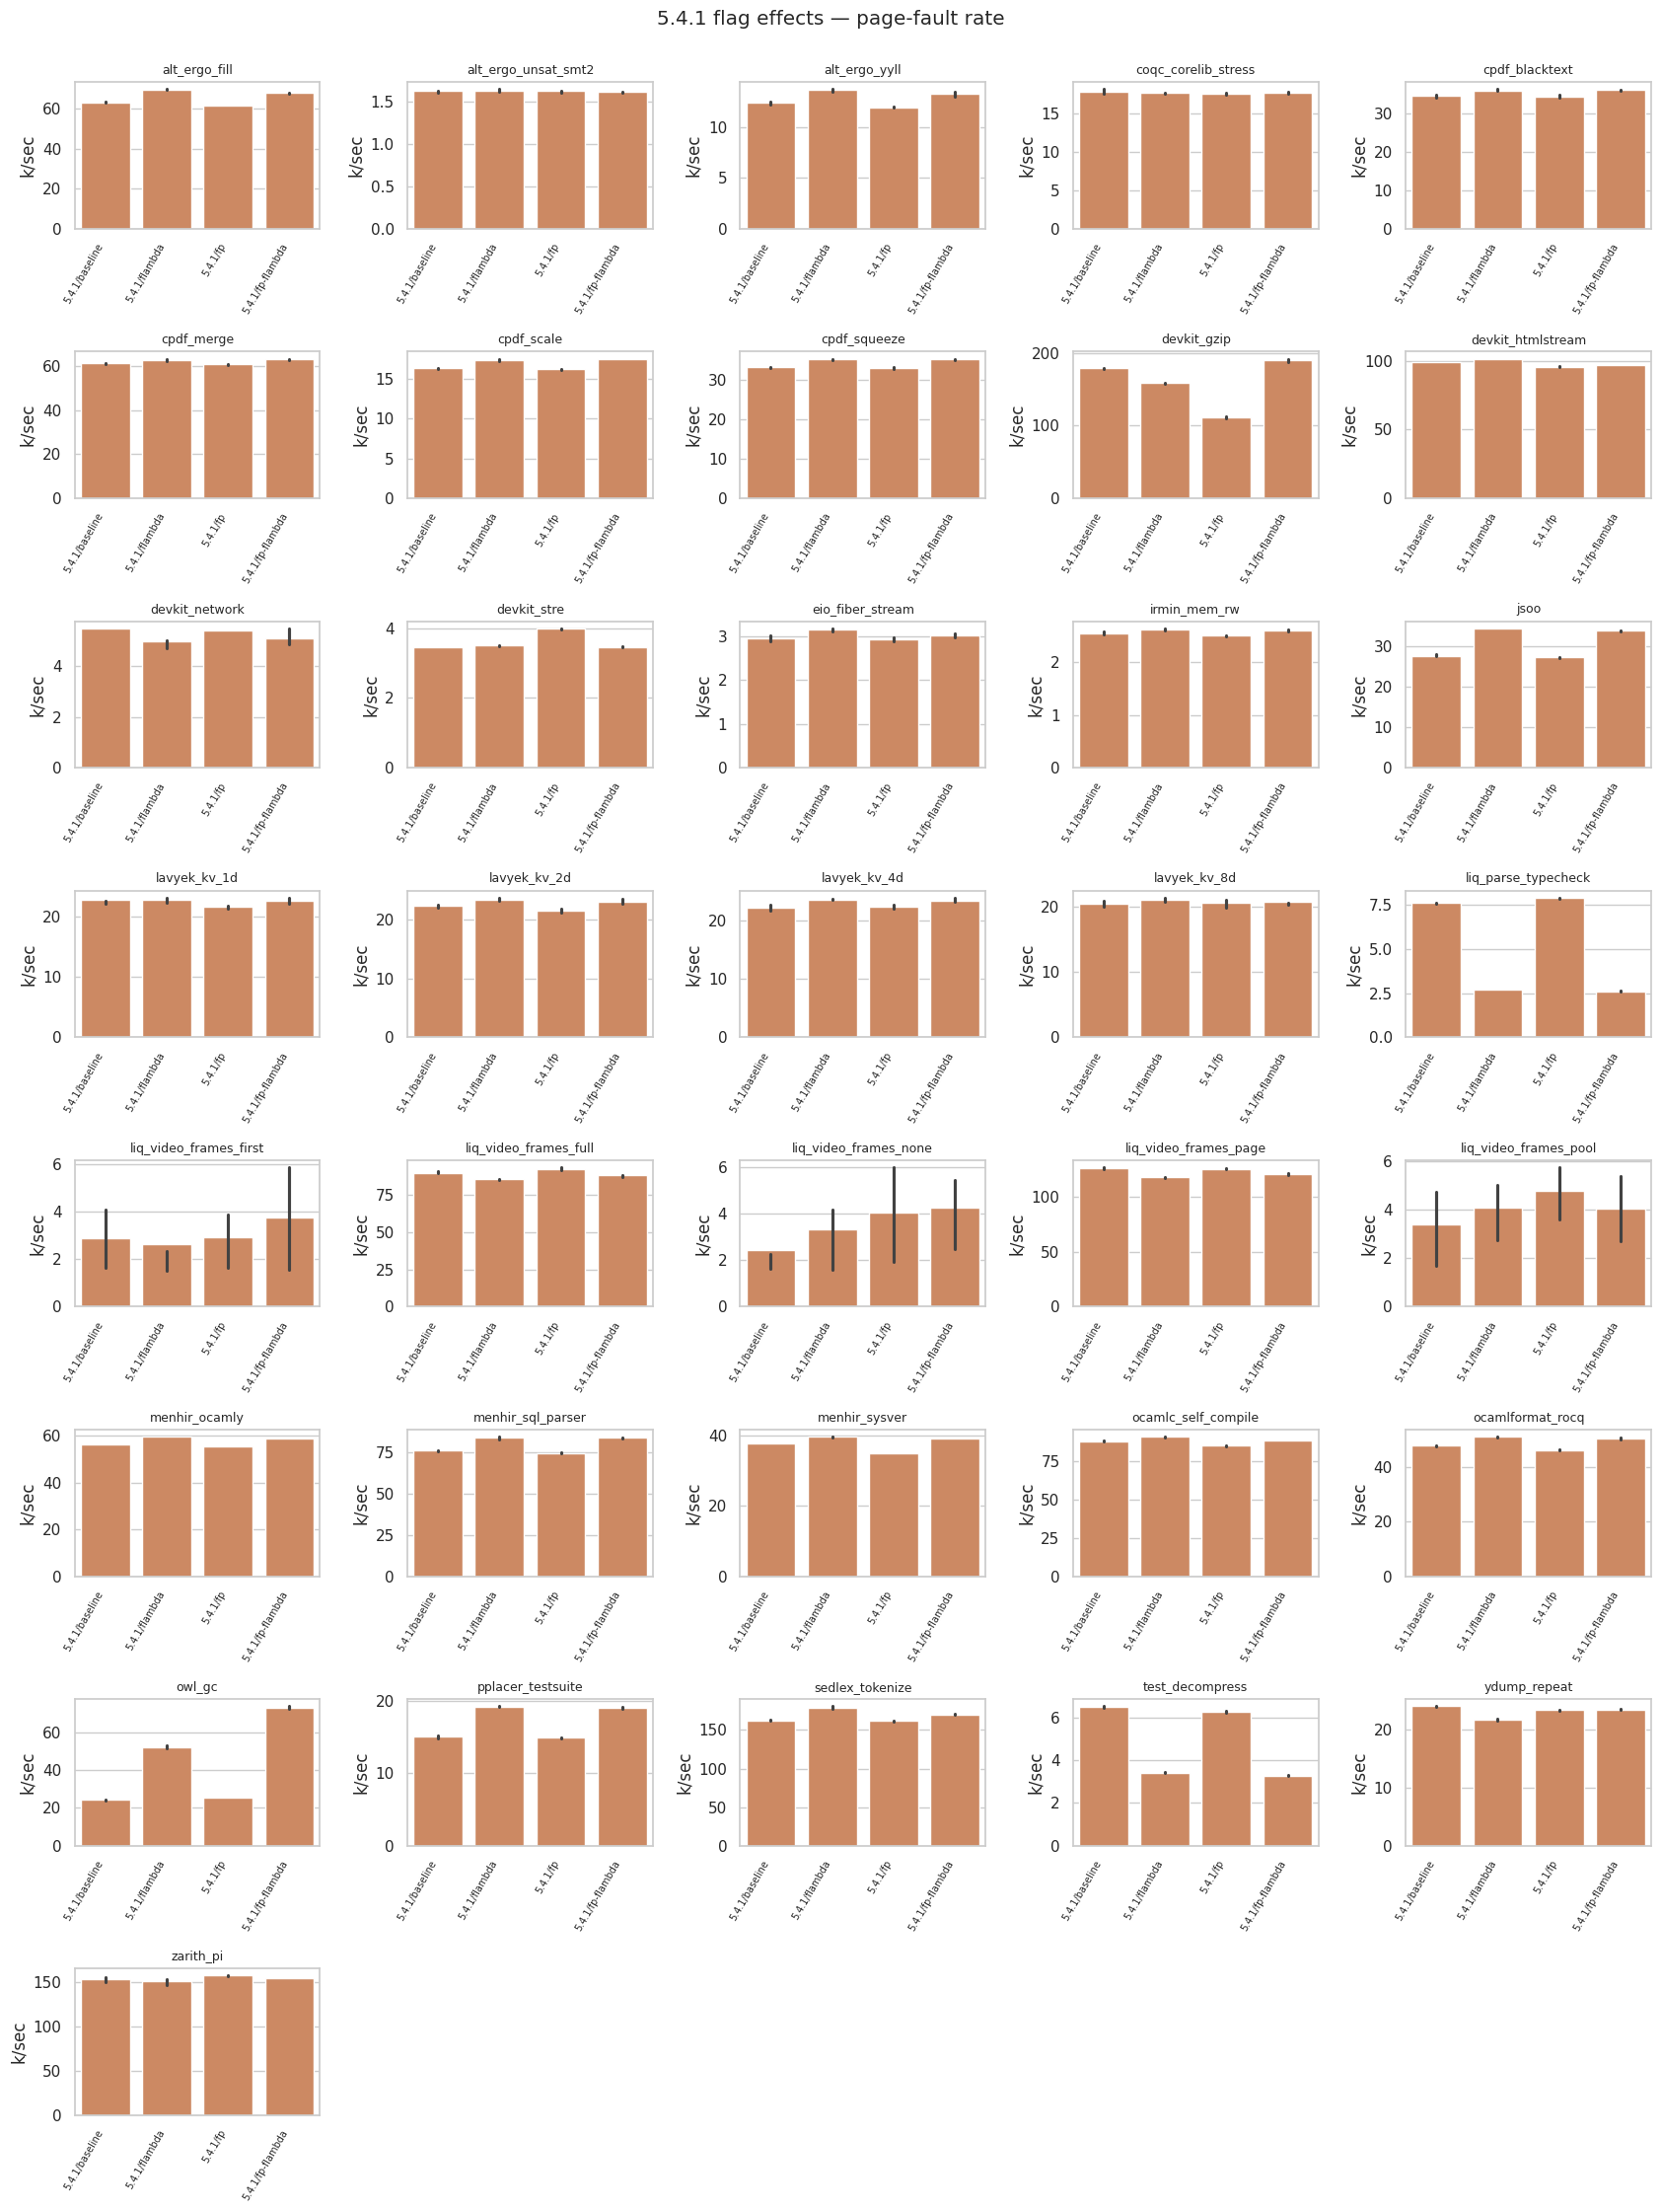

### d8bb46c flag effects

**Variants (4):** `d8bb46c/baseline`, `d8bb46c/flambda`, `d8bb46c/fp`, `d8bb46c/fp-flambda`

**Pairs:**

- `d8bb46c/baseline`  →  `d8bb46c/fp`
- `d8bb46c/baseline`  →  `d8bb46c/flambda`
- `d8bb46c/baseline`  →  `d8bb46c/fp-flambda`

#### Wall time (raw)

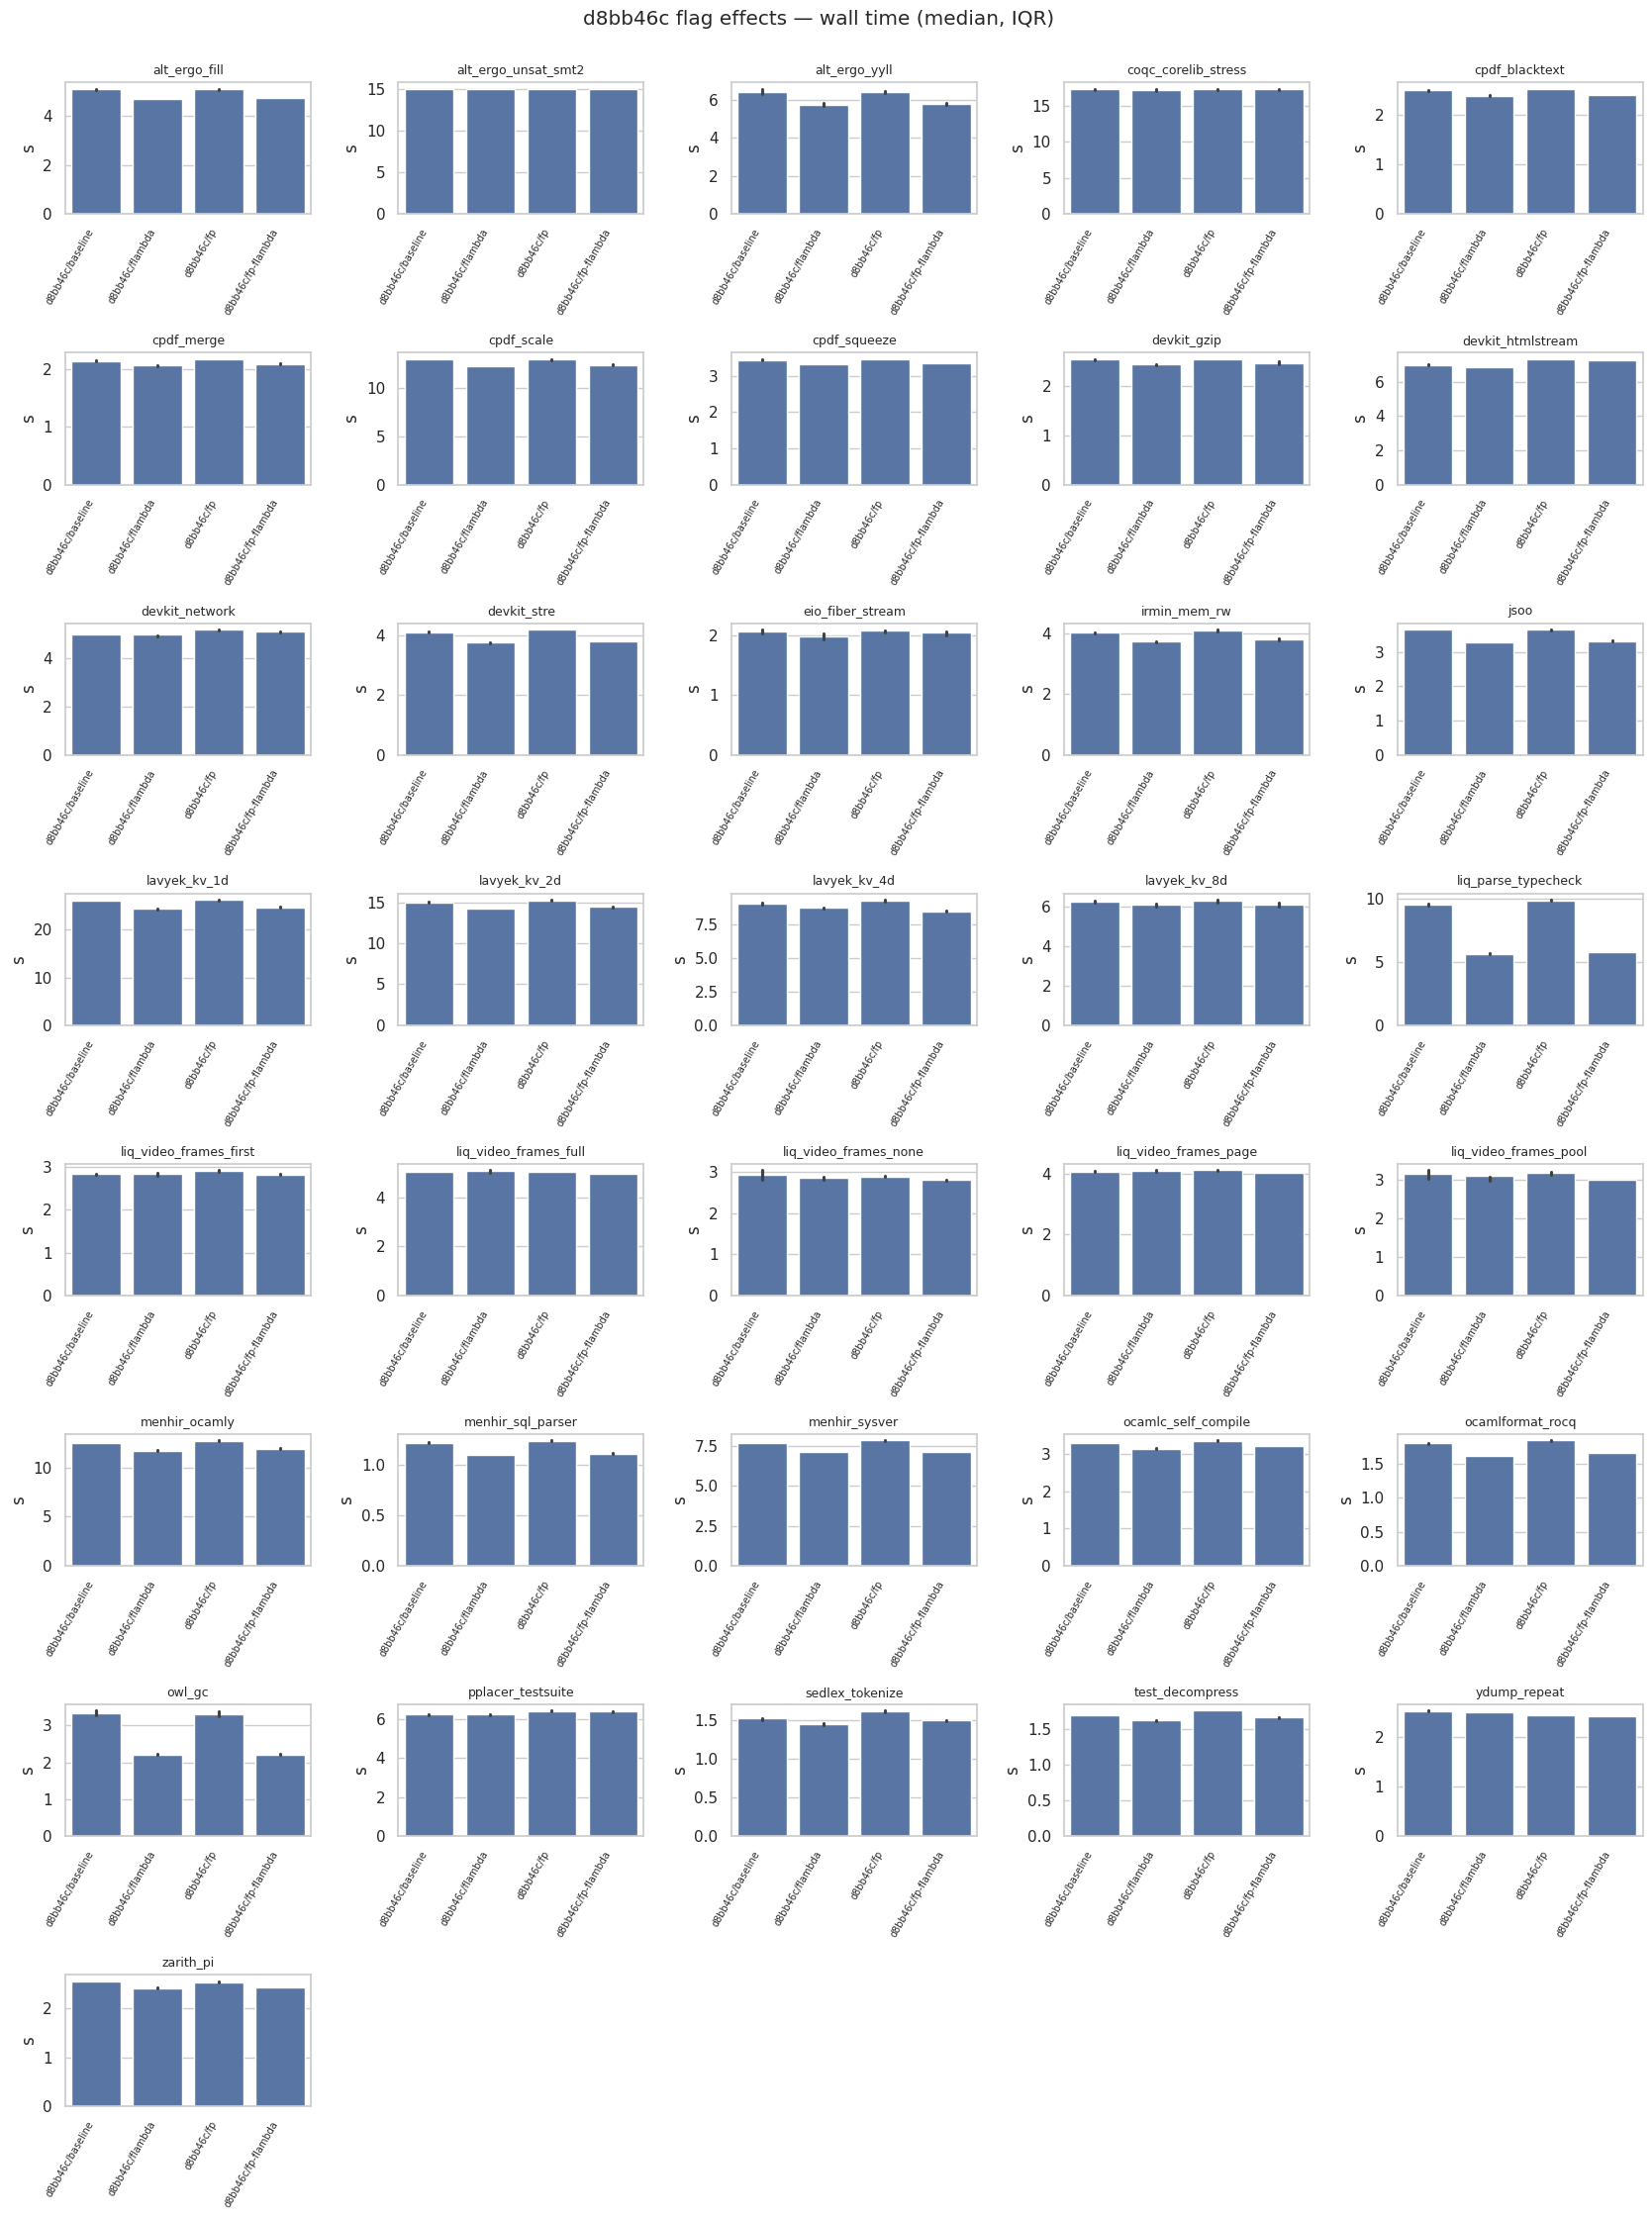

#### Mutator vs GC time

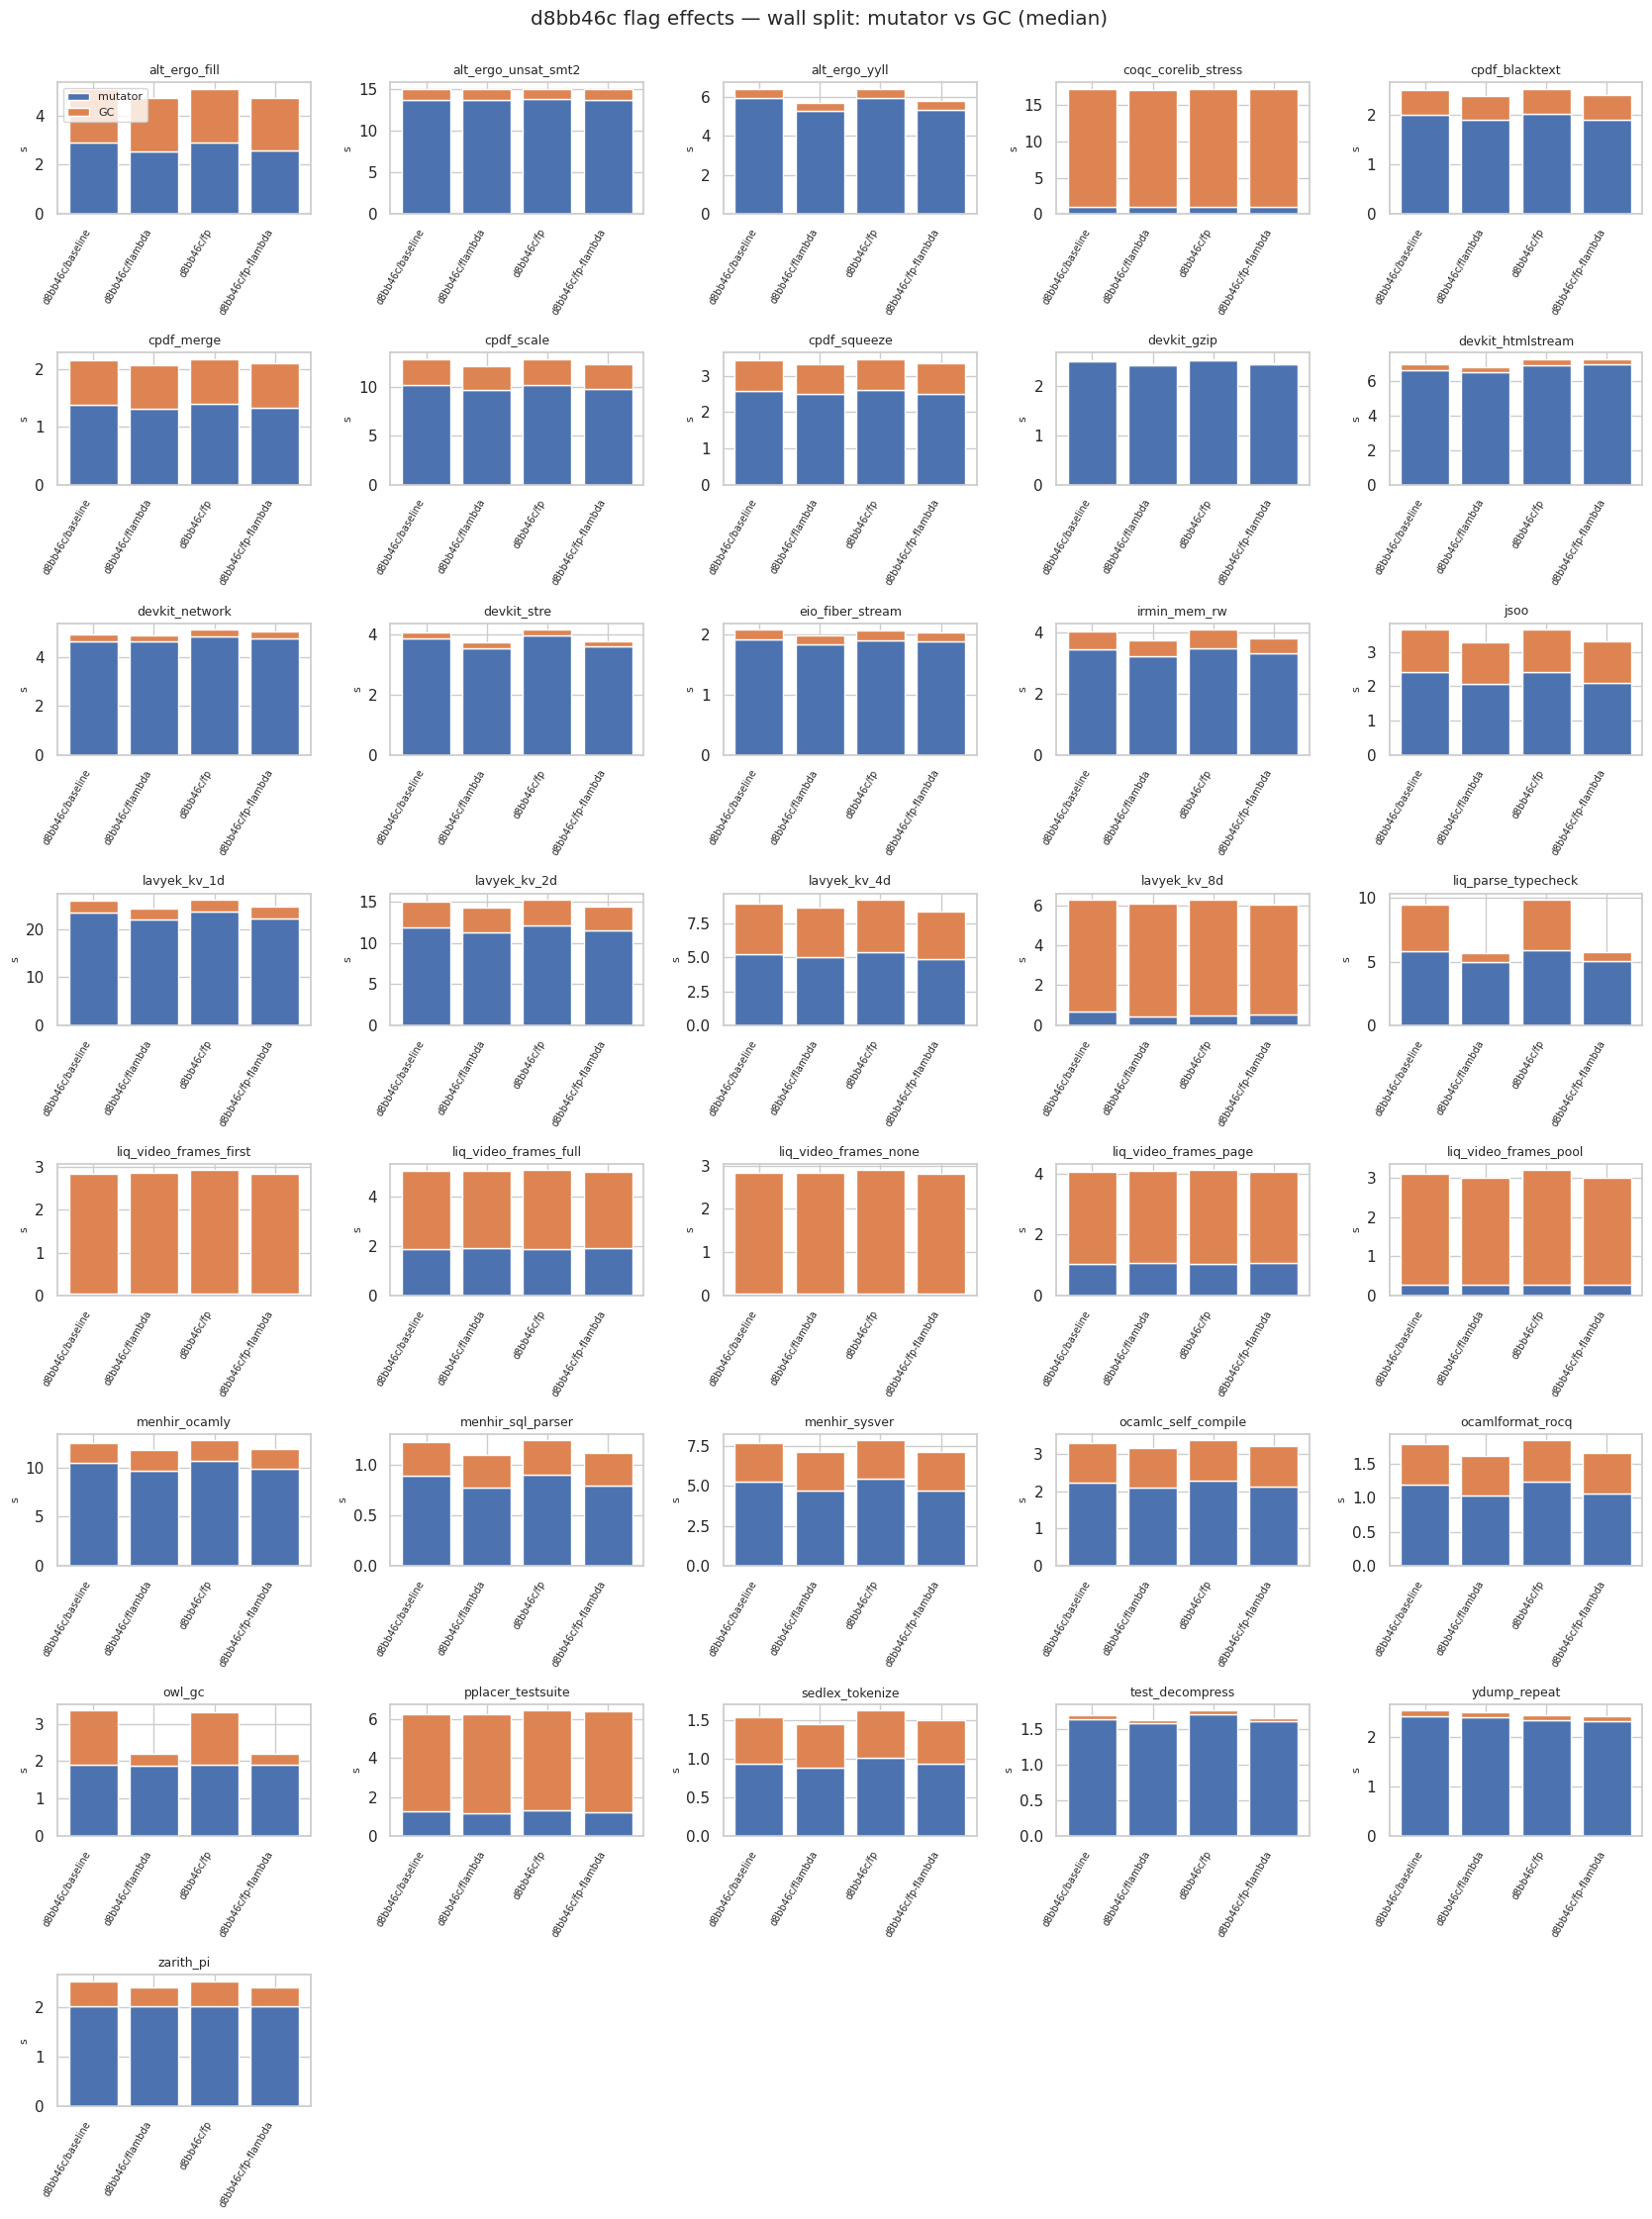

#### GC overhead (% of wall)

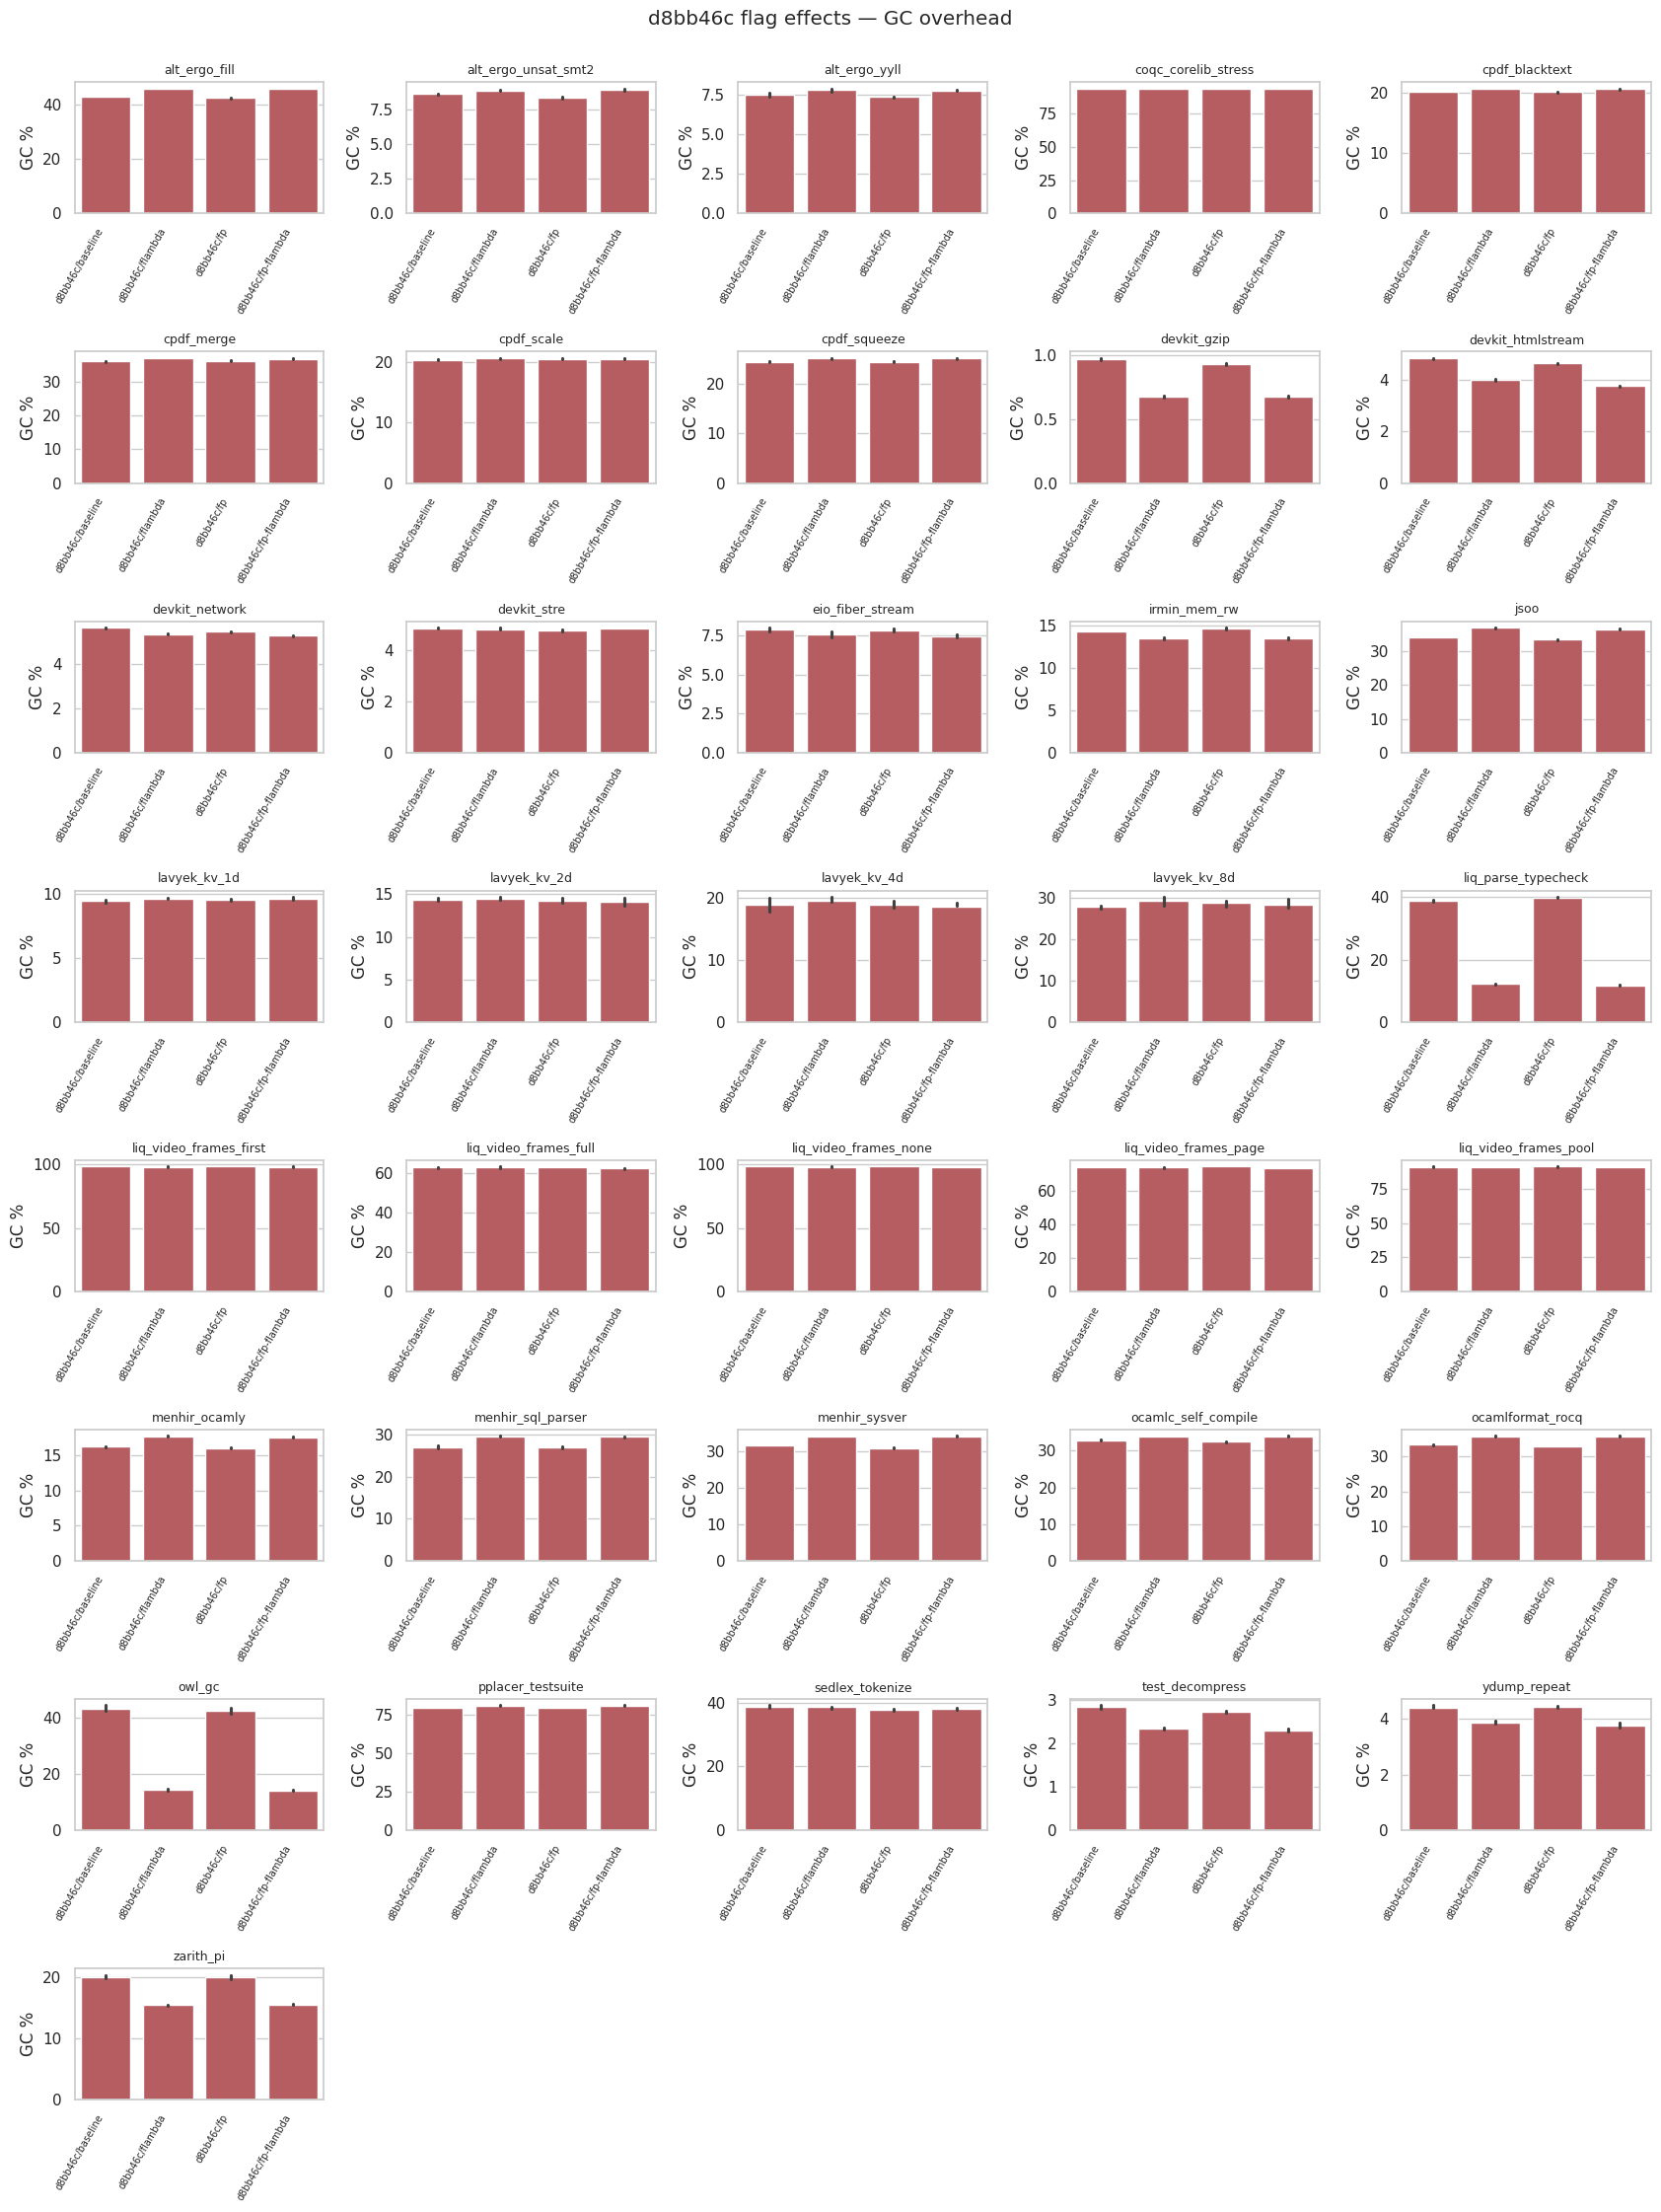

#### Latency ECDF

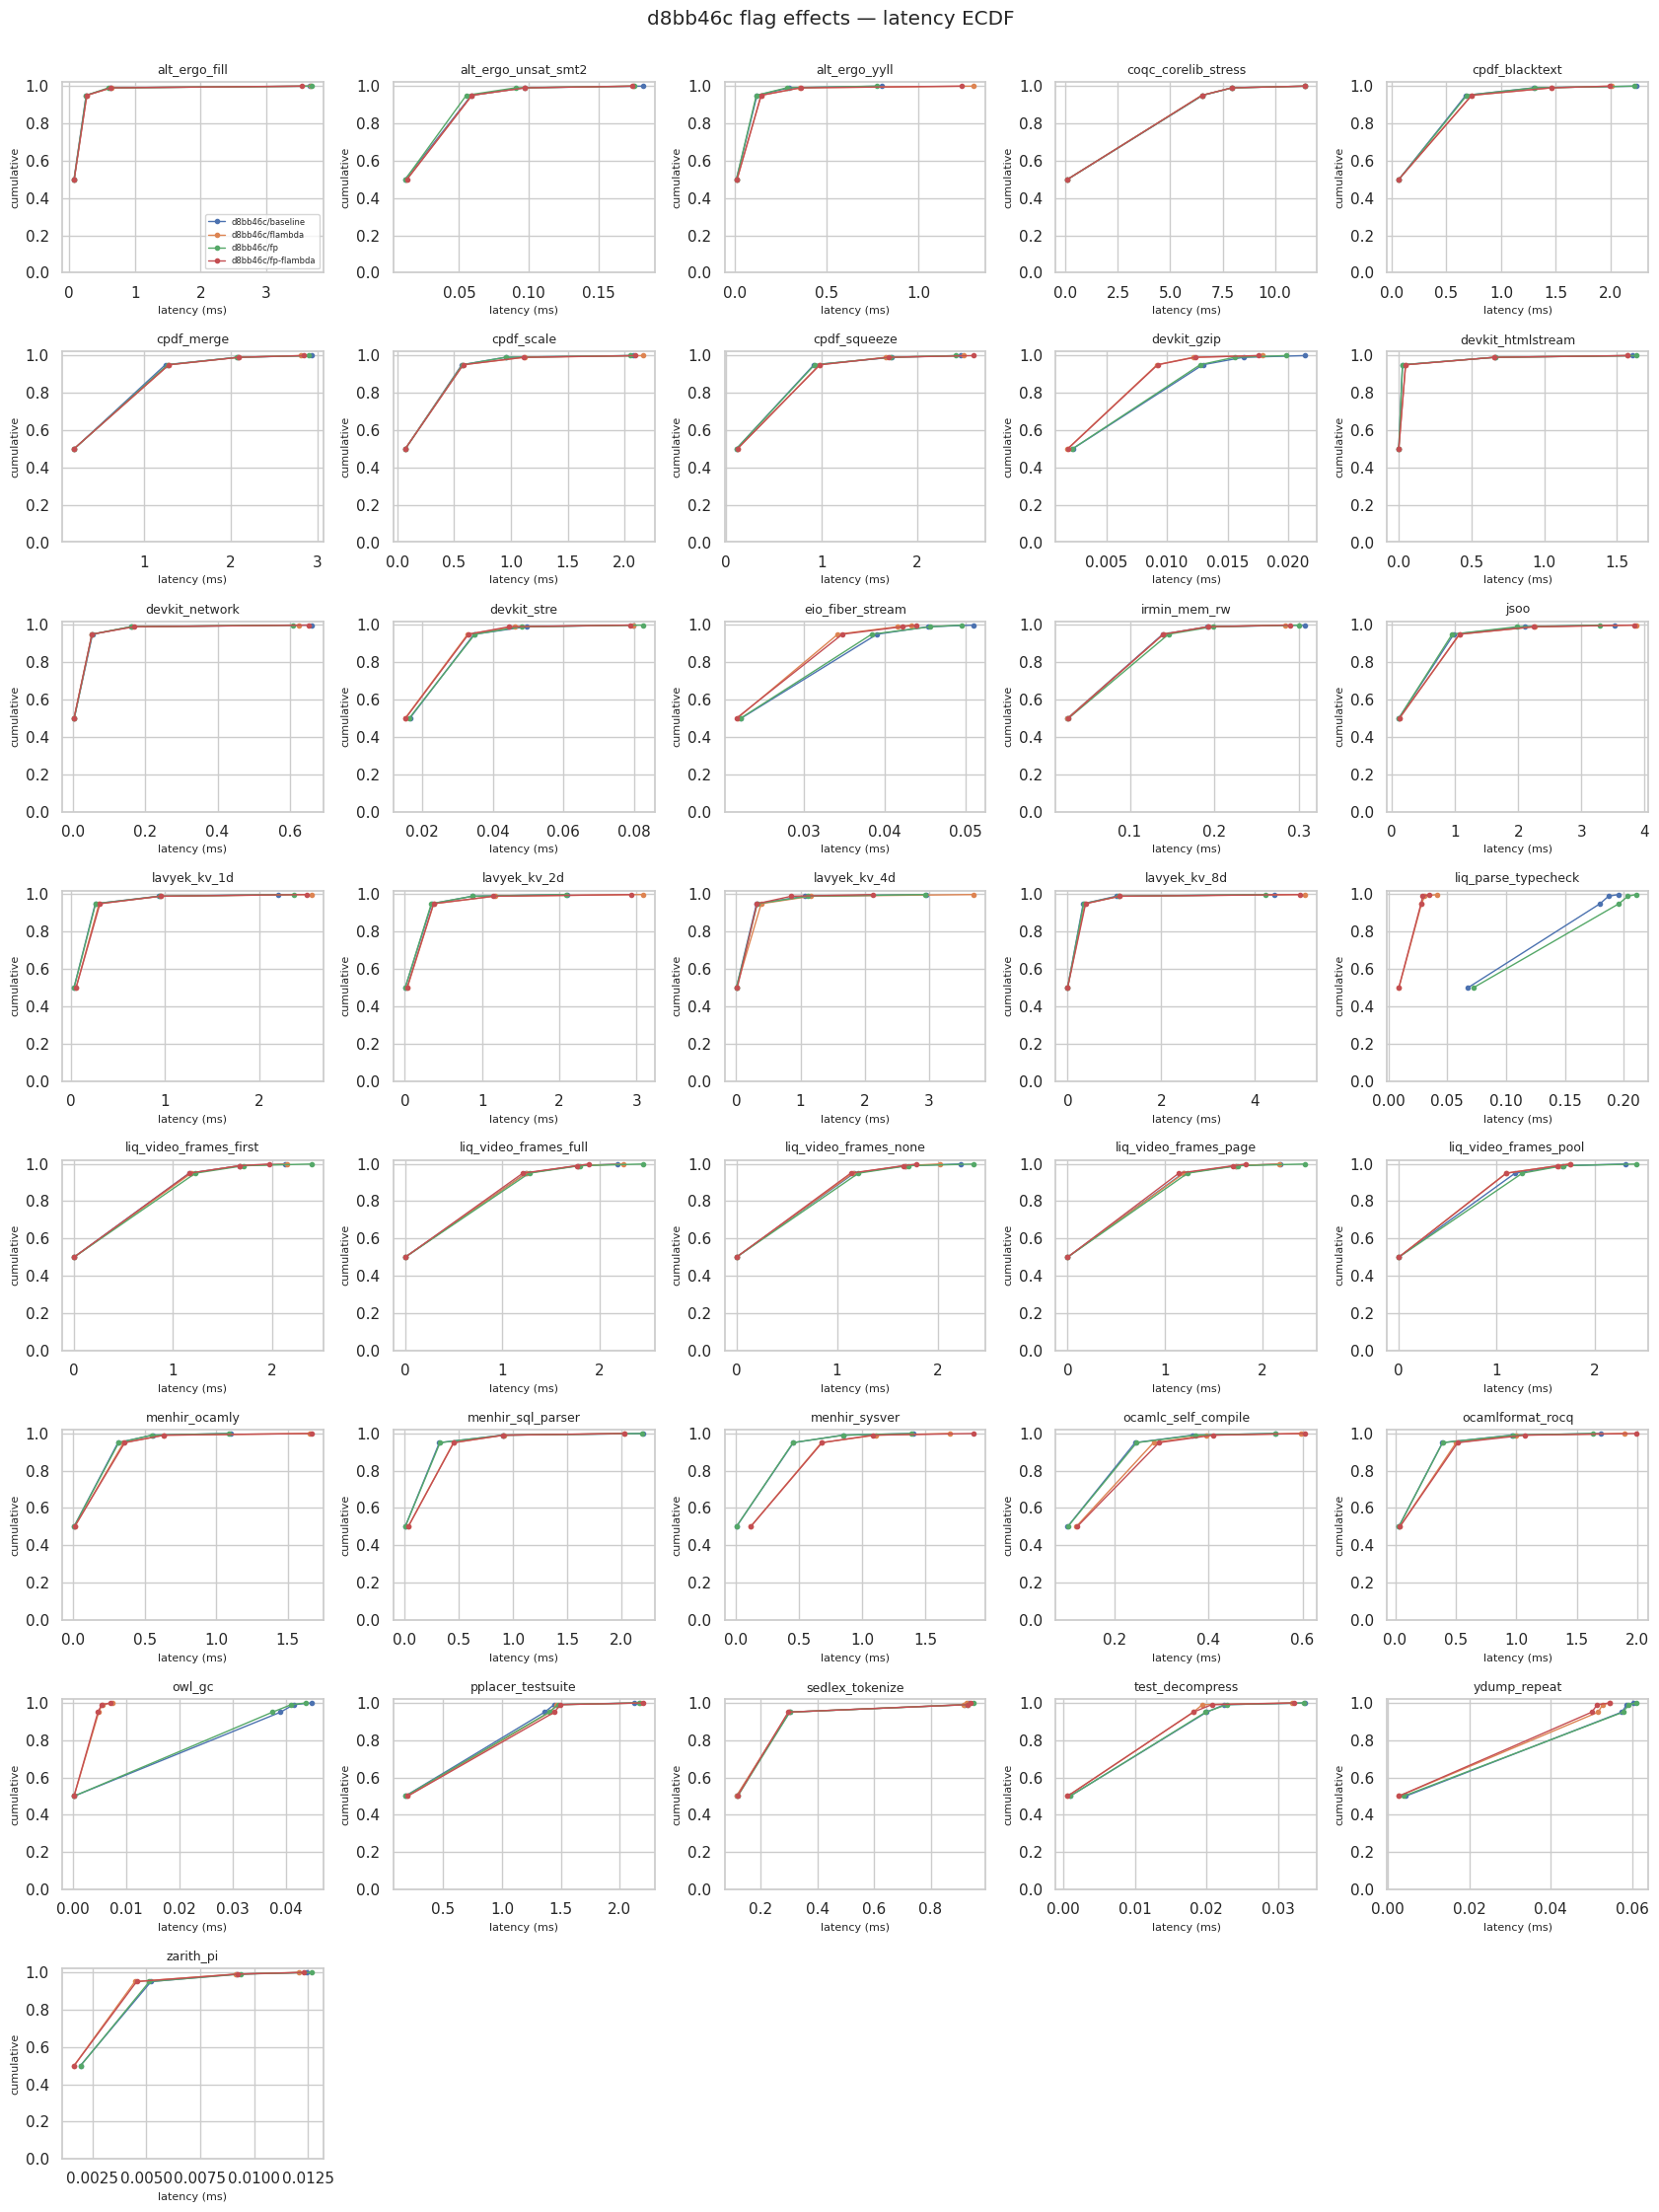

#### Wall-time distribution per cell

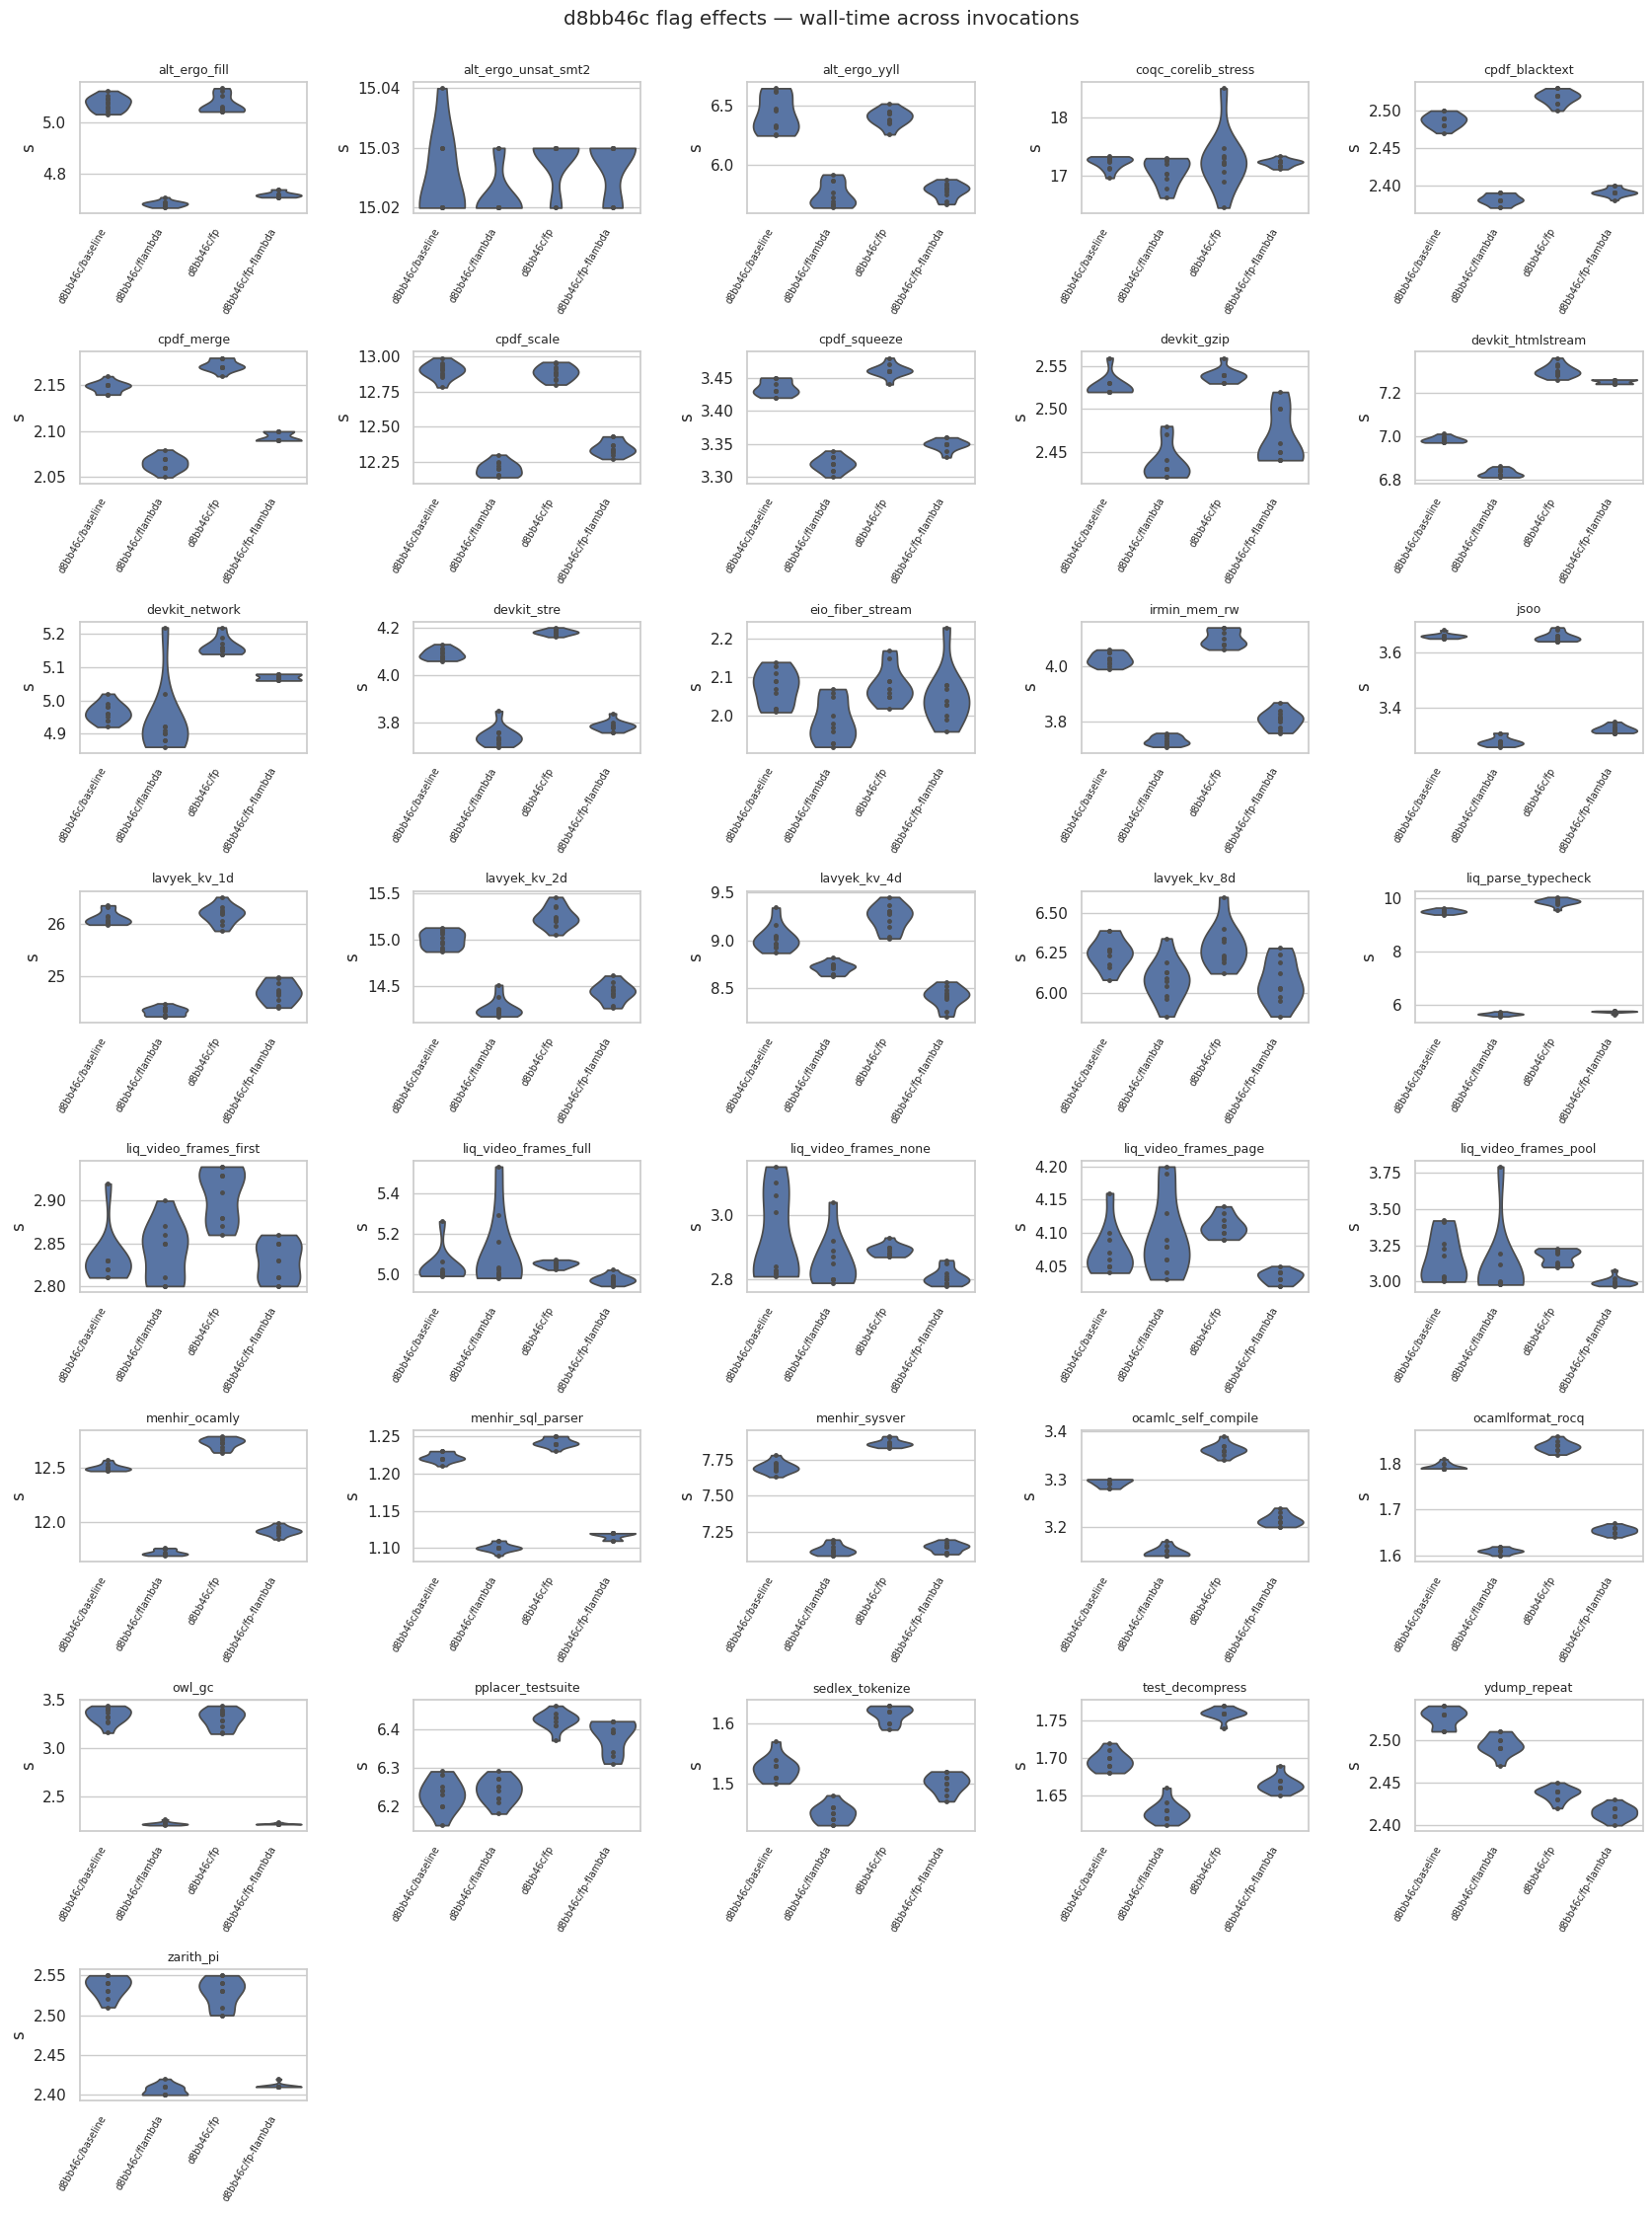

#### Allocation: promoted %

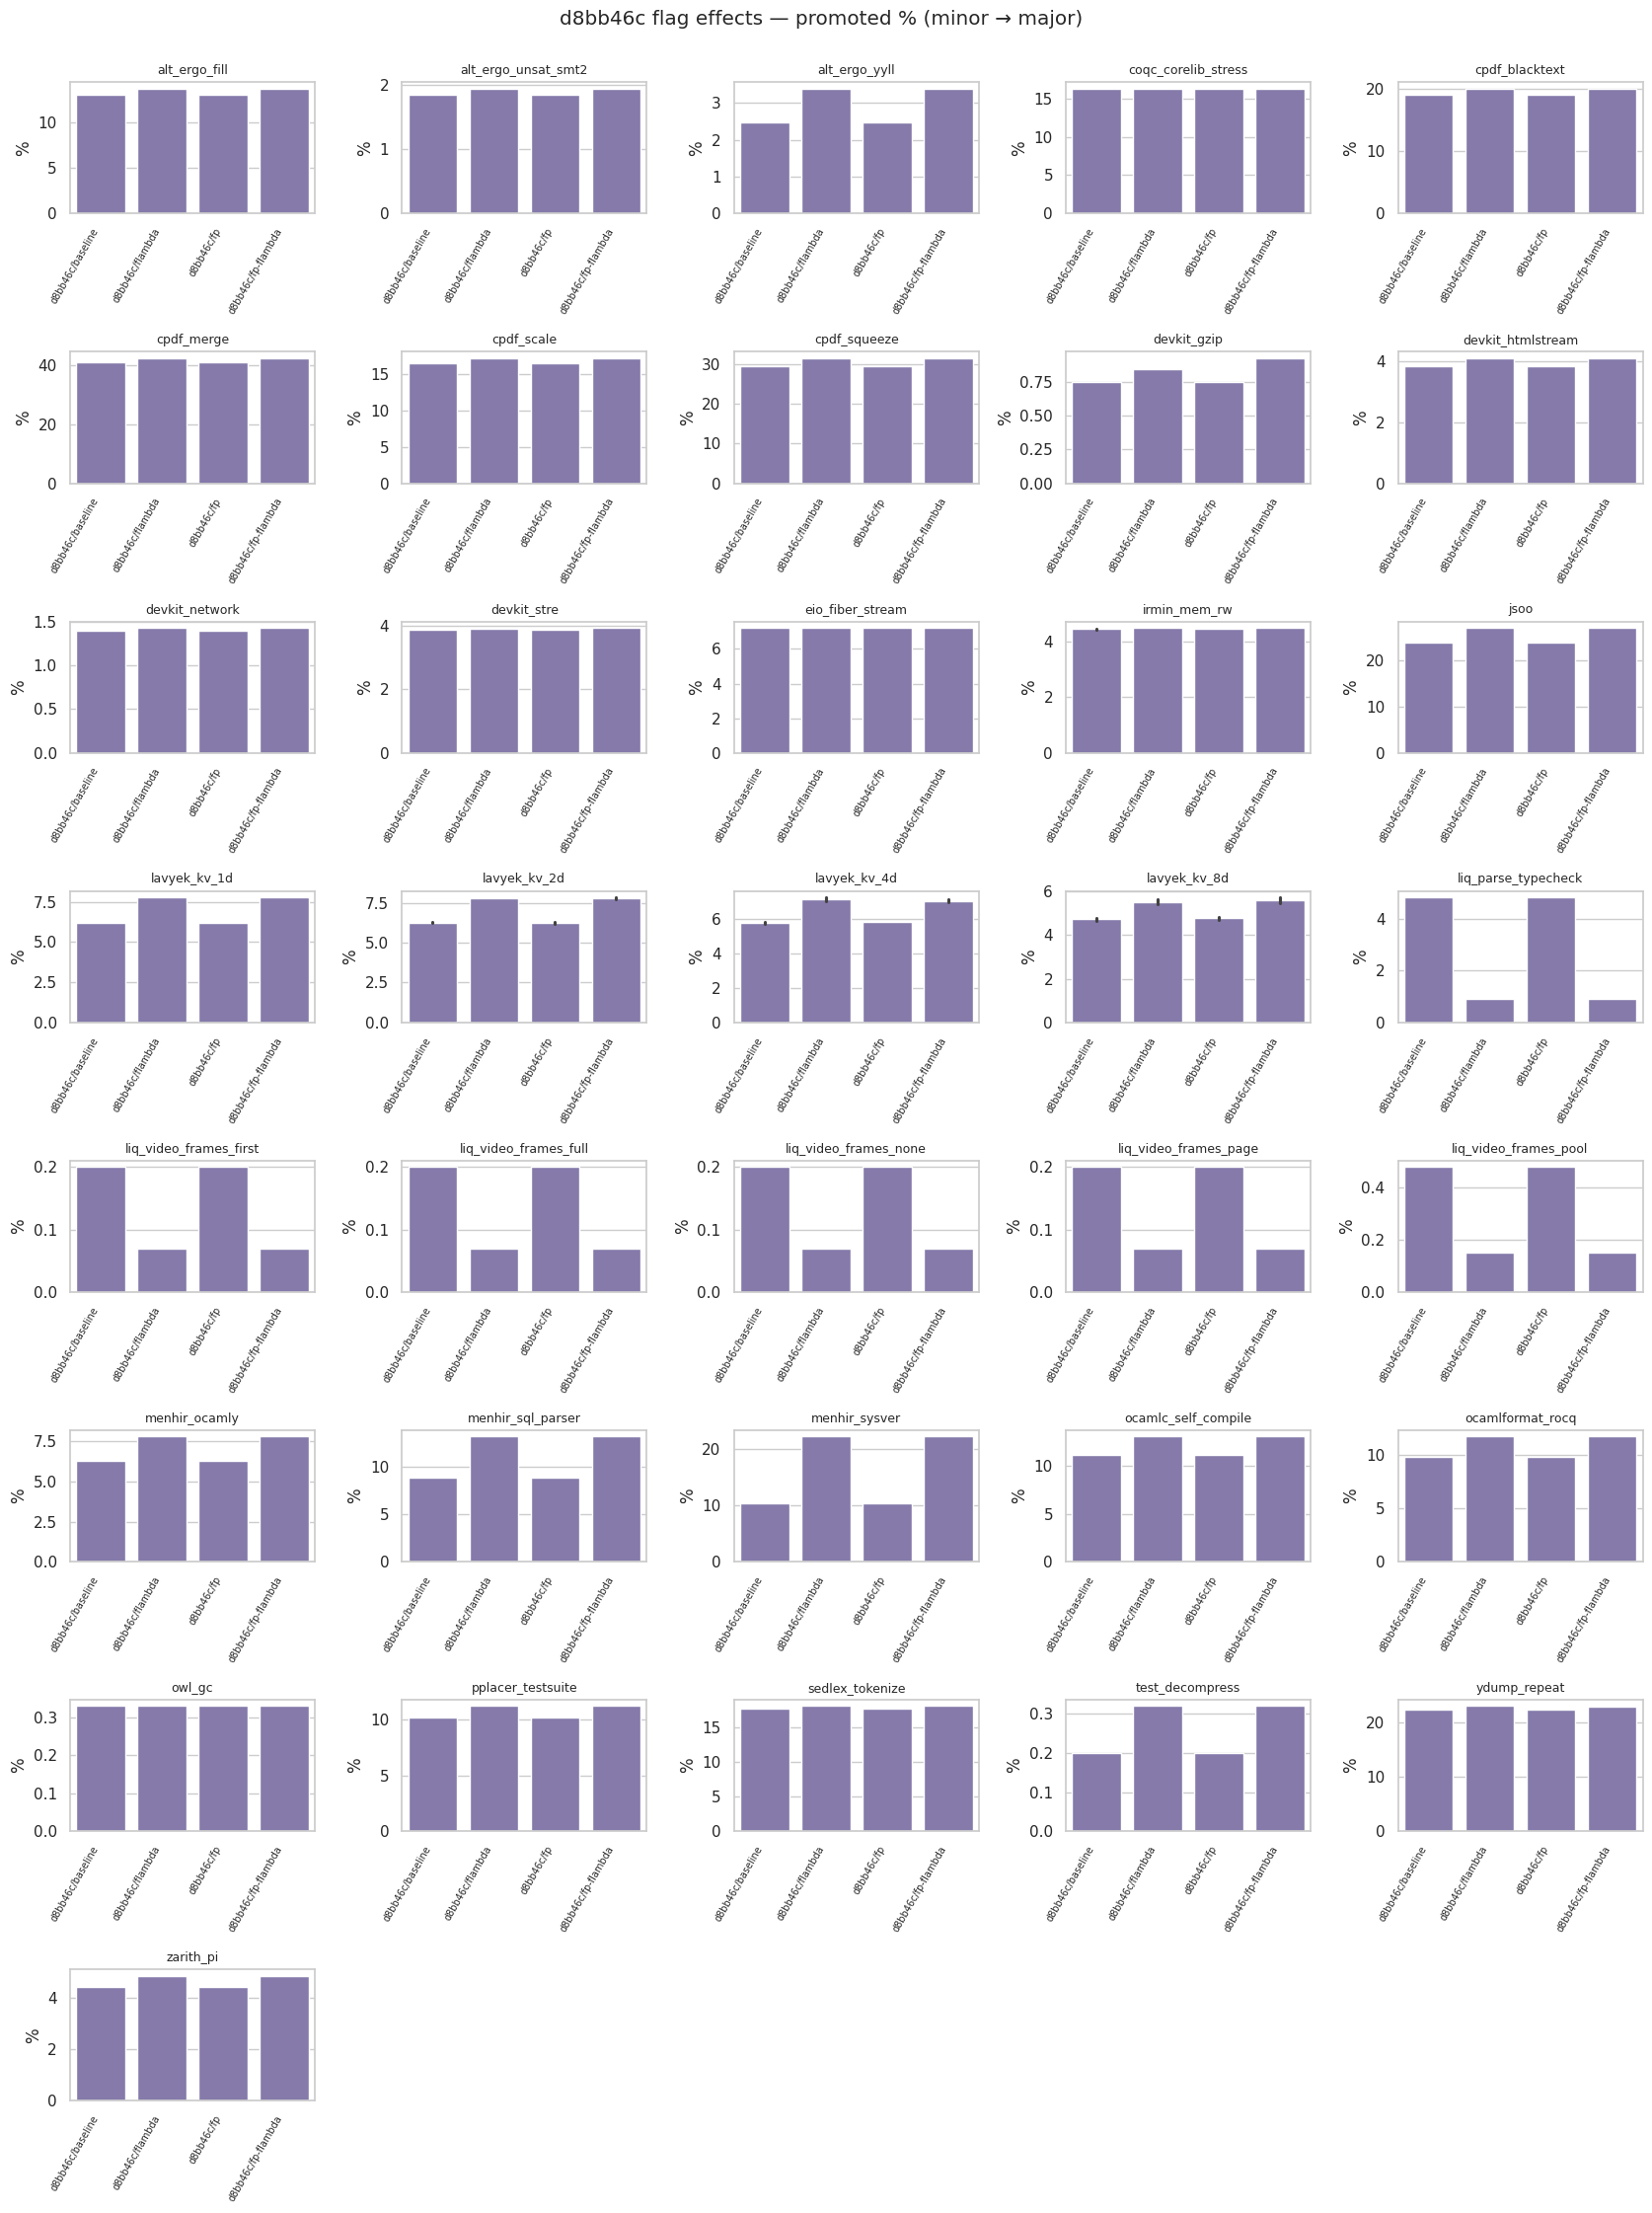

#### Hardware counters

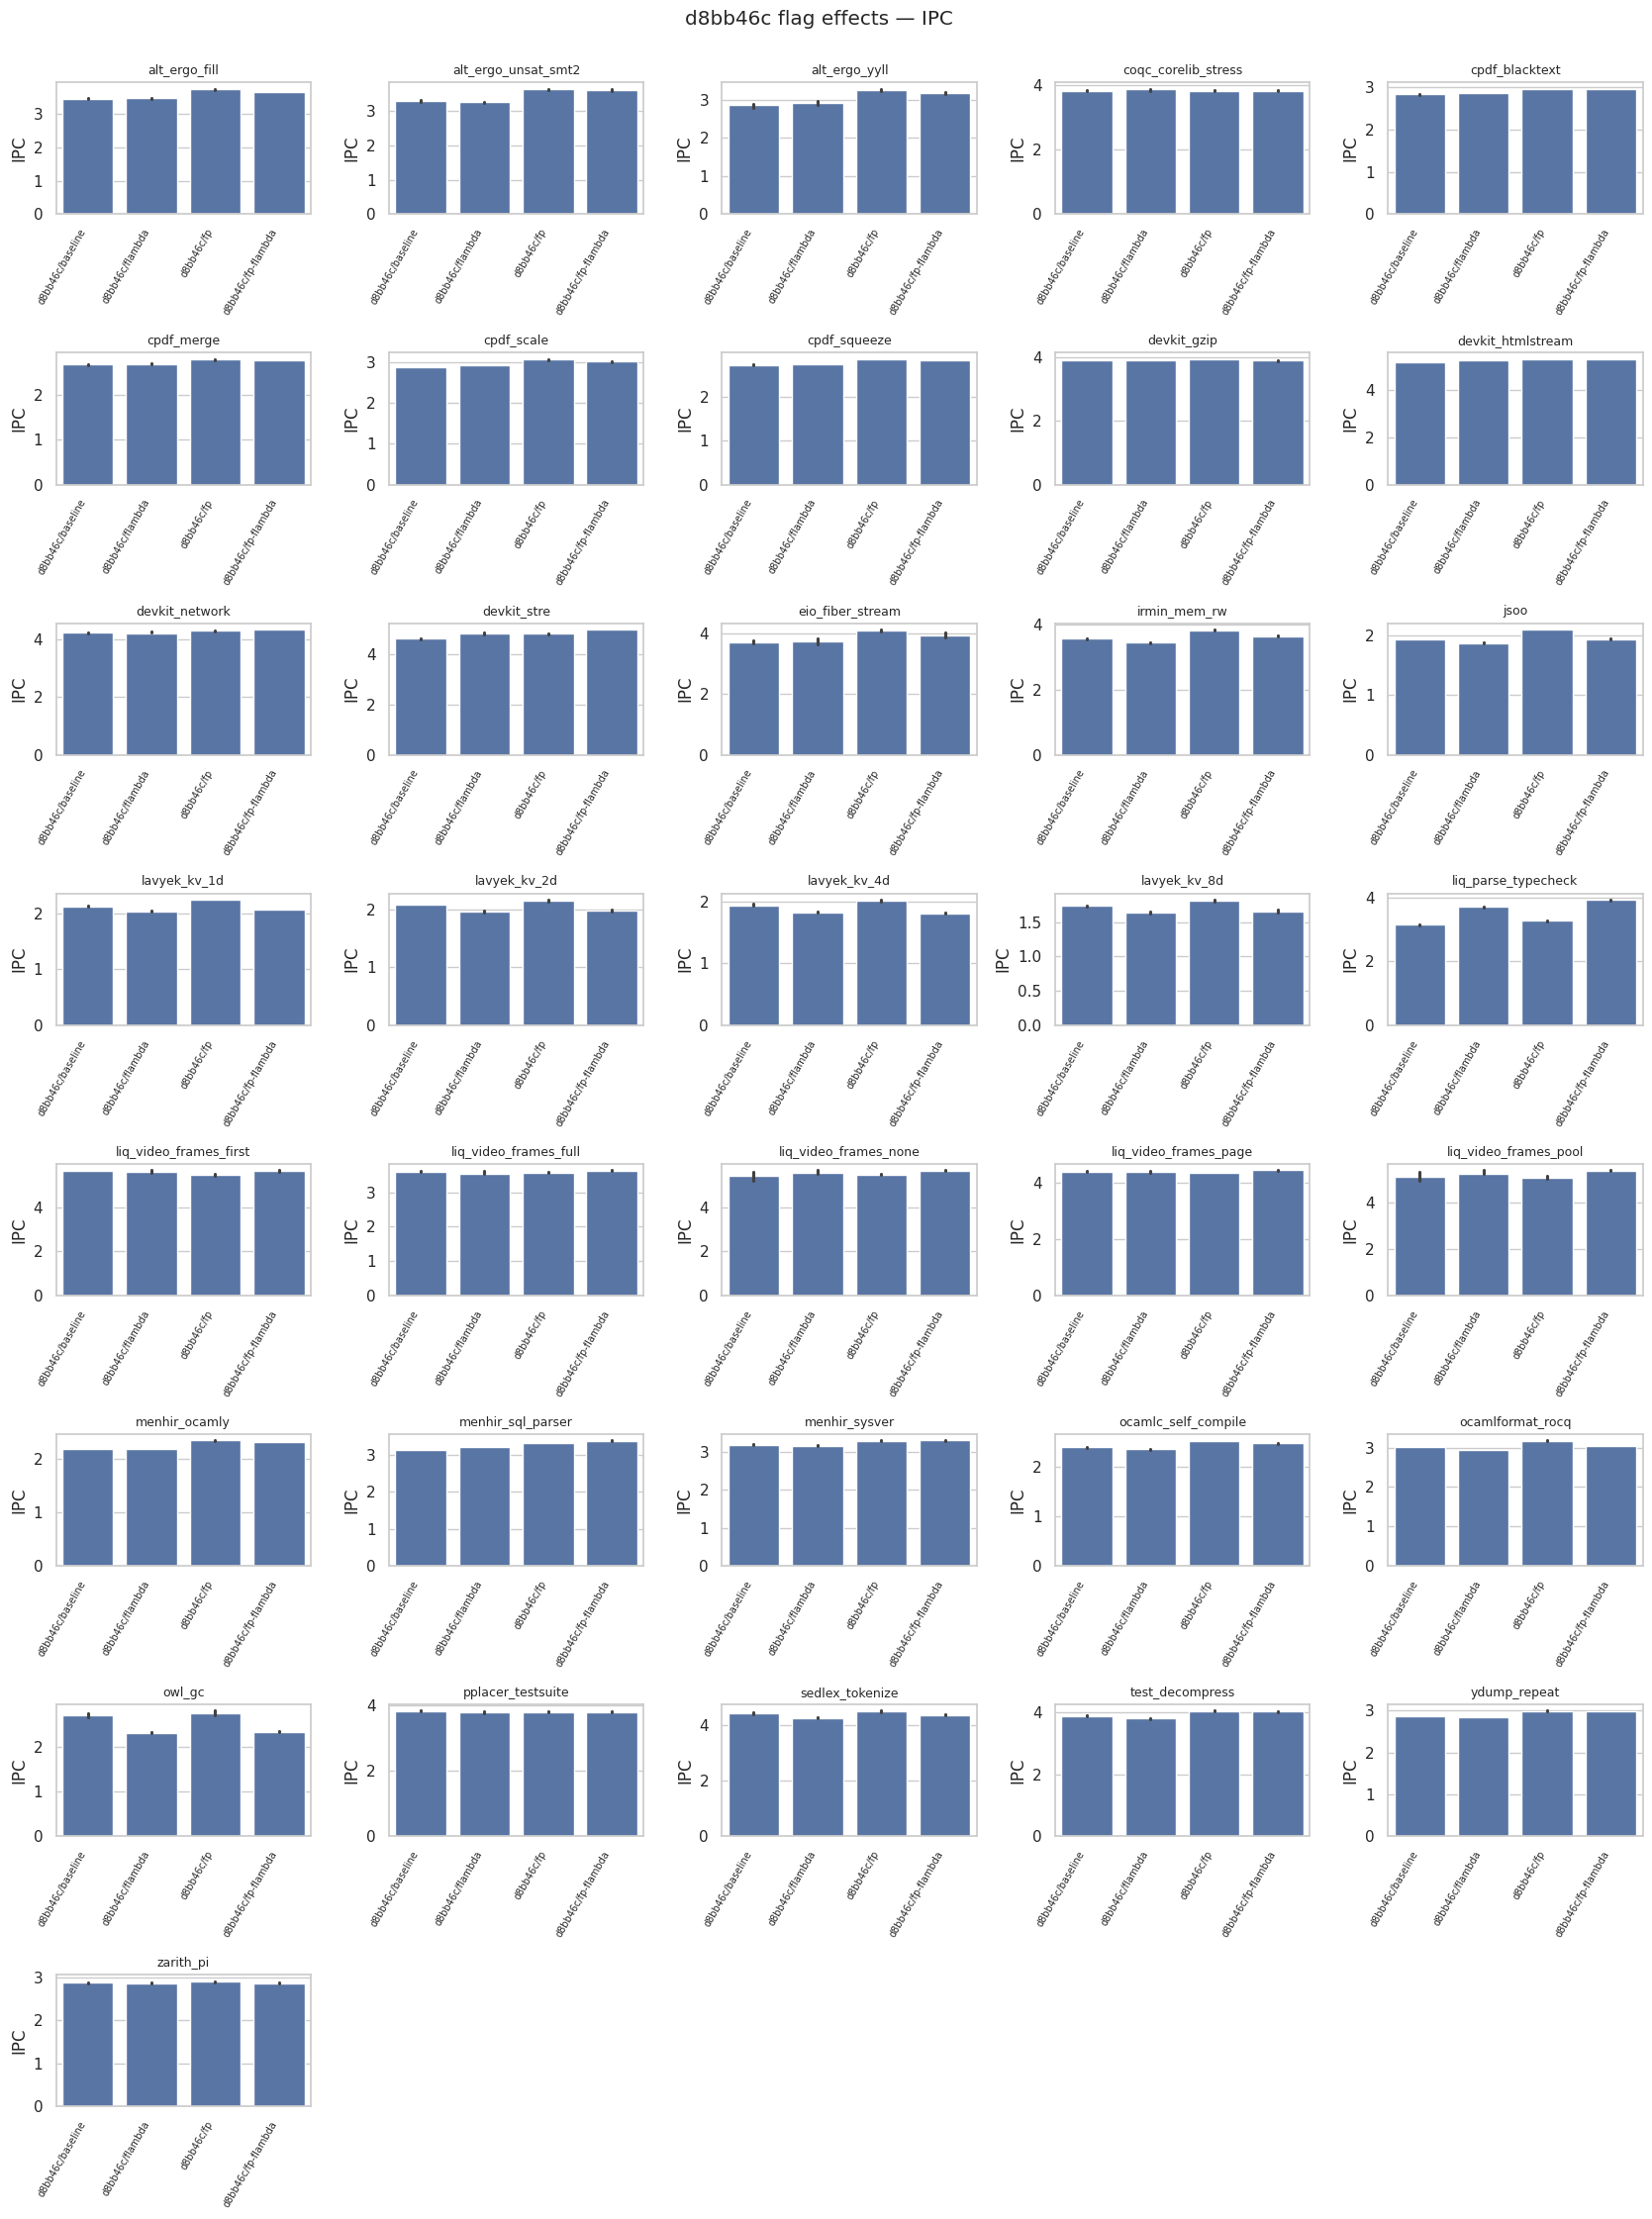

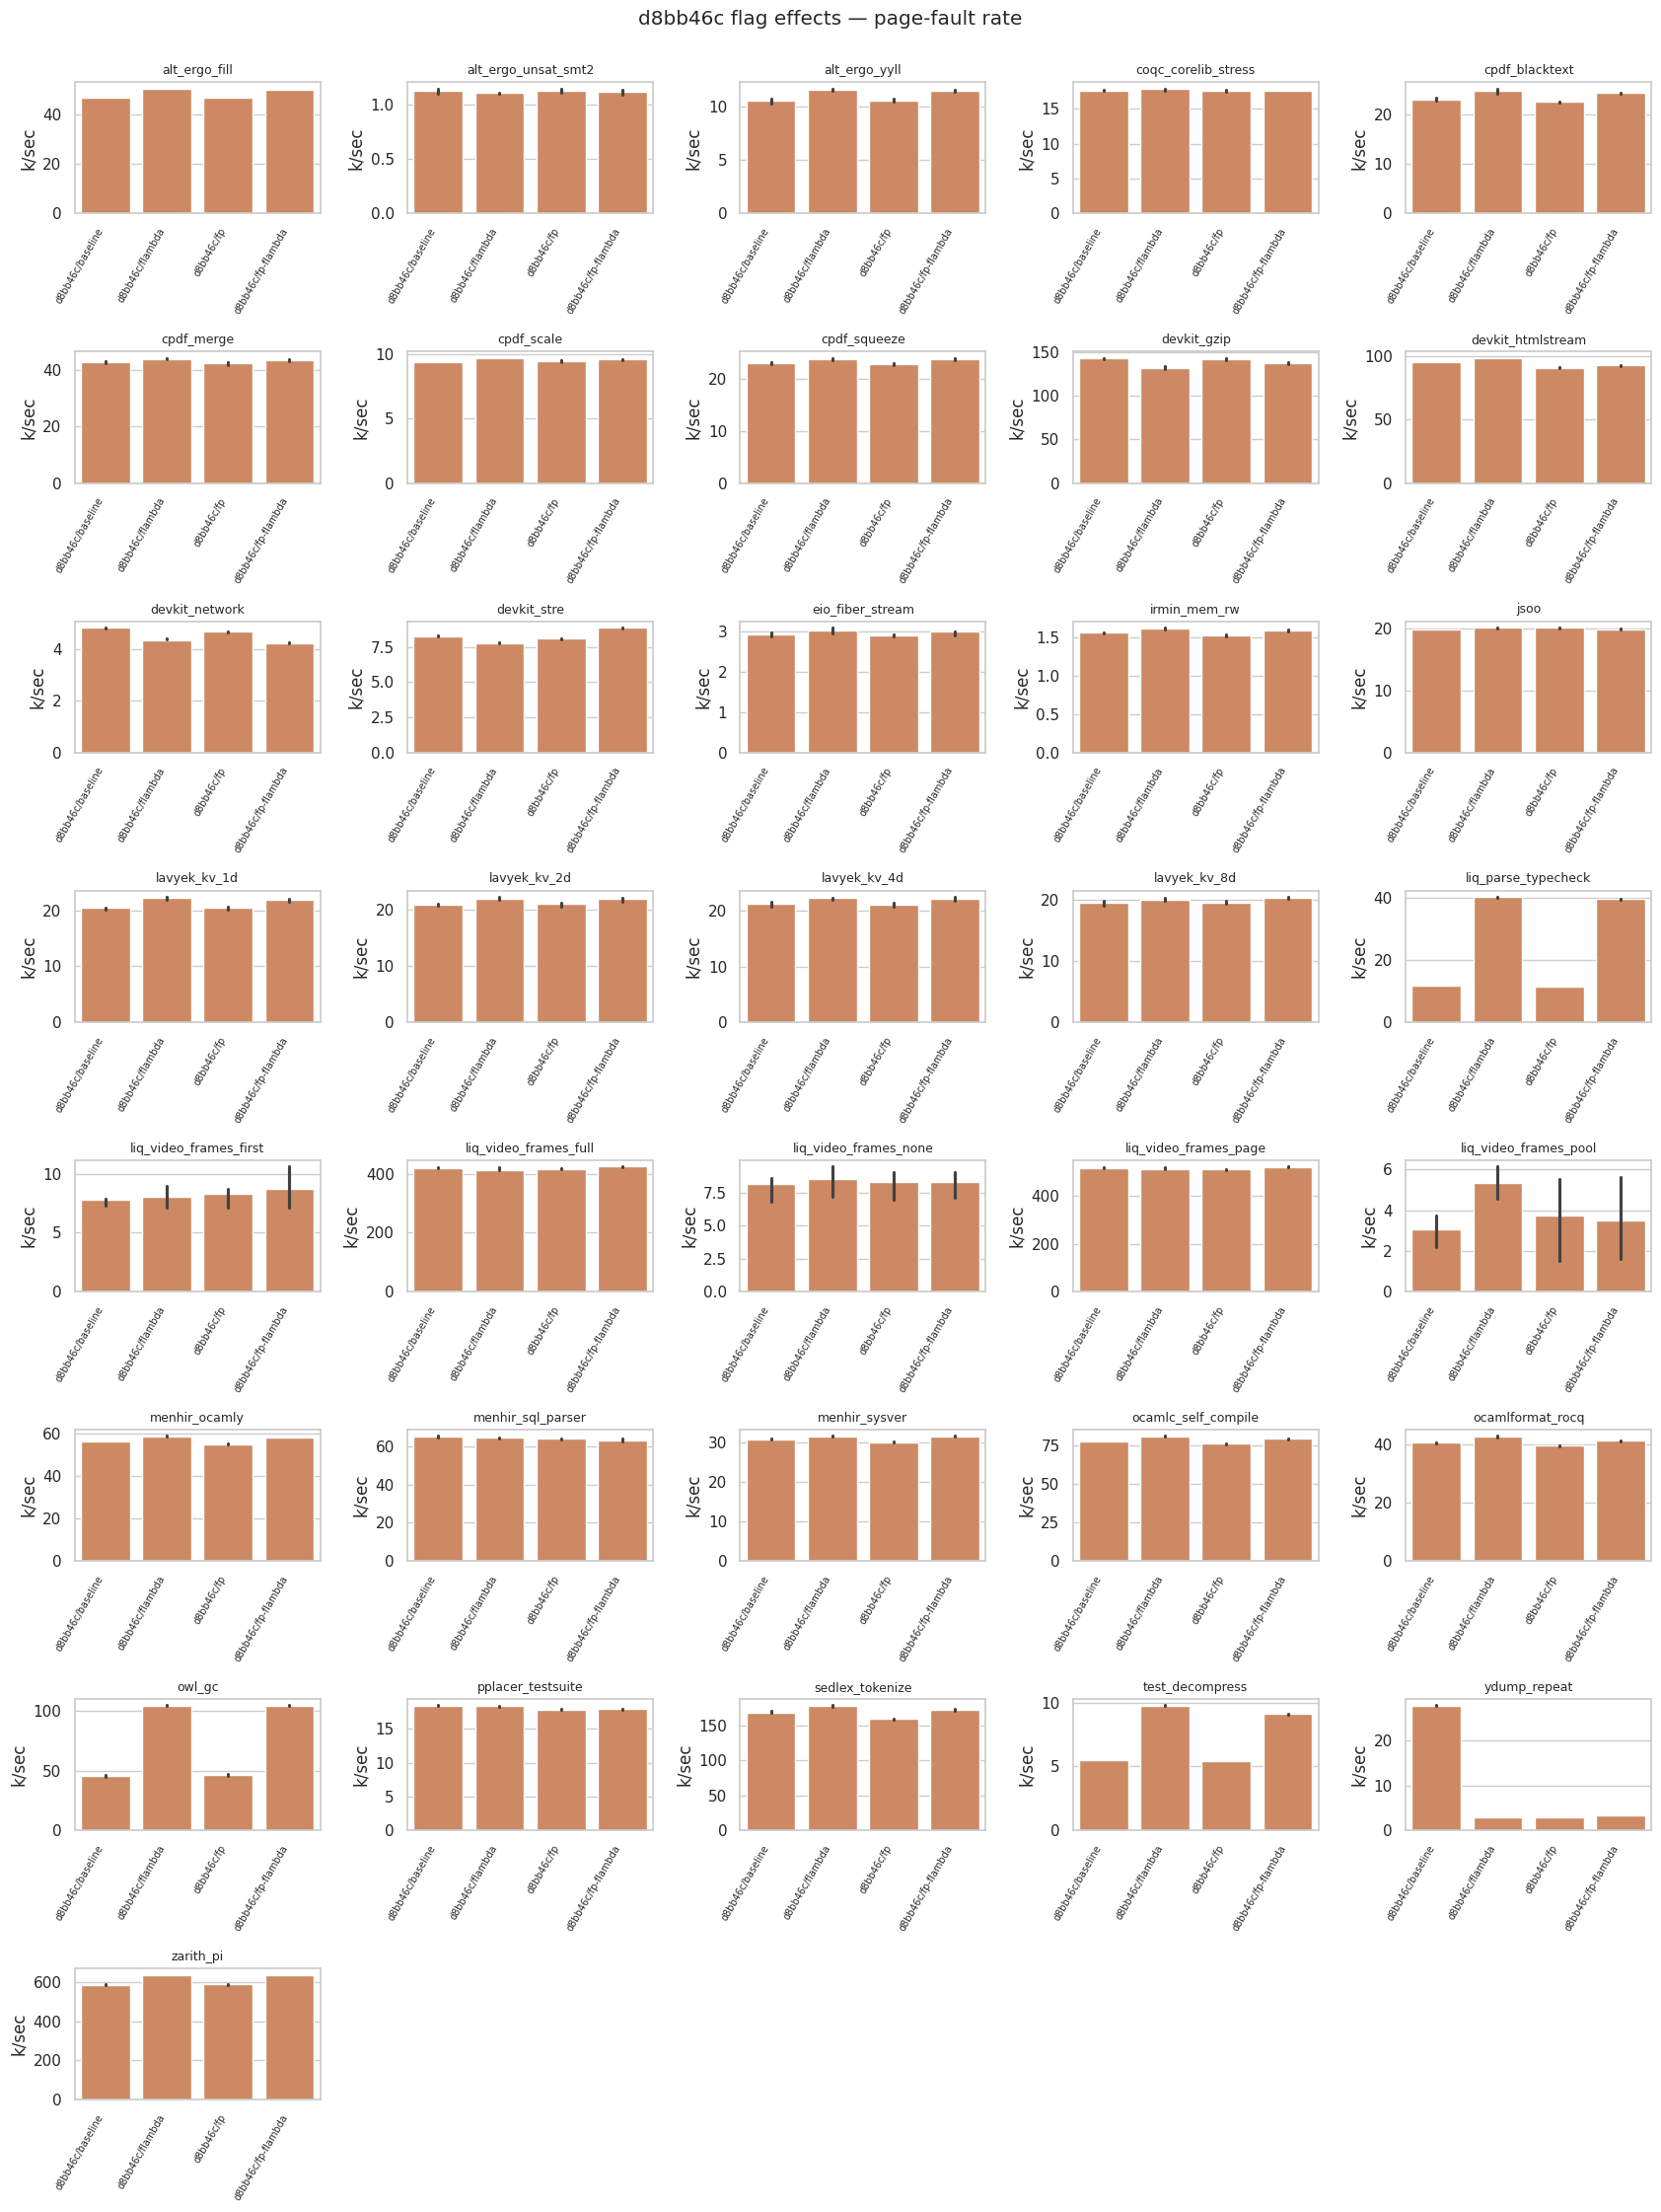

### version effect (by flag combo)

**Variants (8):** `5.4.1/baseline`, `5.4.1/flambda`, `5.4.1/fp`, `5.4.1/fp-flambda`, `d8bb46c/baseline`, `d8bb46c/flambda`, `d8bb46c/fp`, `d8bb46c/fp-flambda`

**Pairs:**

- `5.4.1/baseline`  →  `d8bb46c/baseline`
- `5.4.1/fp`  →  `d8bb46c/fp`
- `5.4.1/flambda`  →  `d8bb46c/flambda`
- `5.4.1/fp-flambda`  →  `d8bb46c/fp-flambda`

#### Wall time (raw)

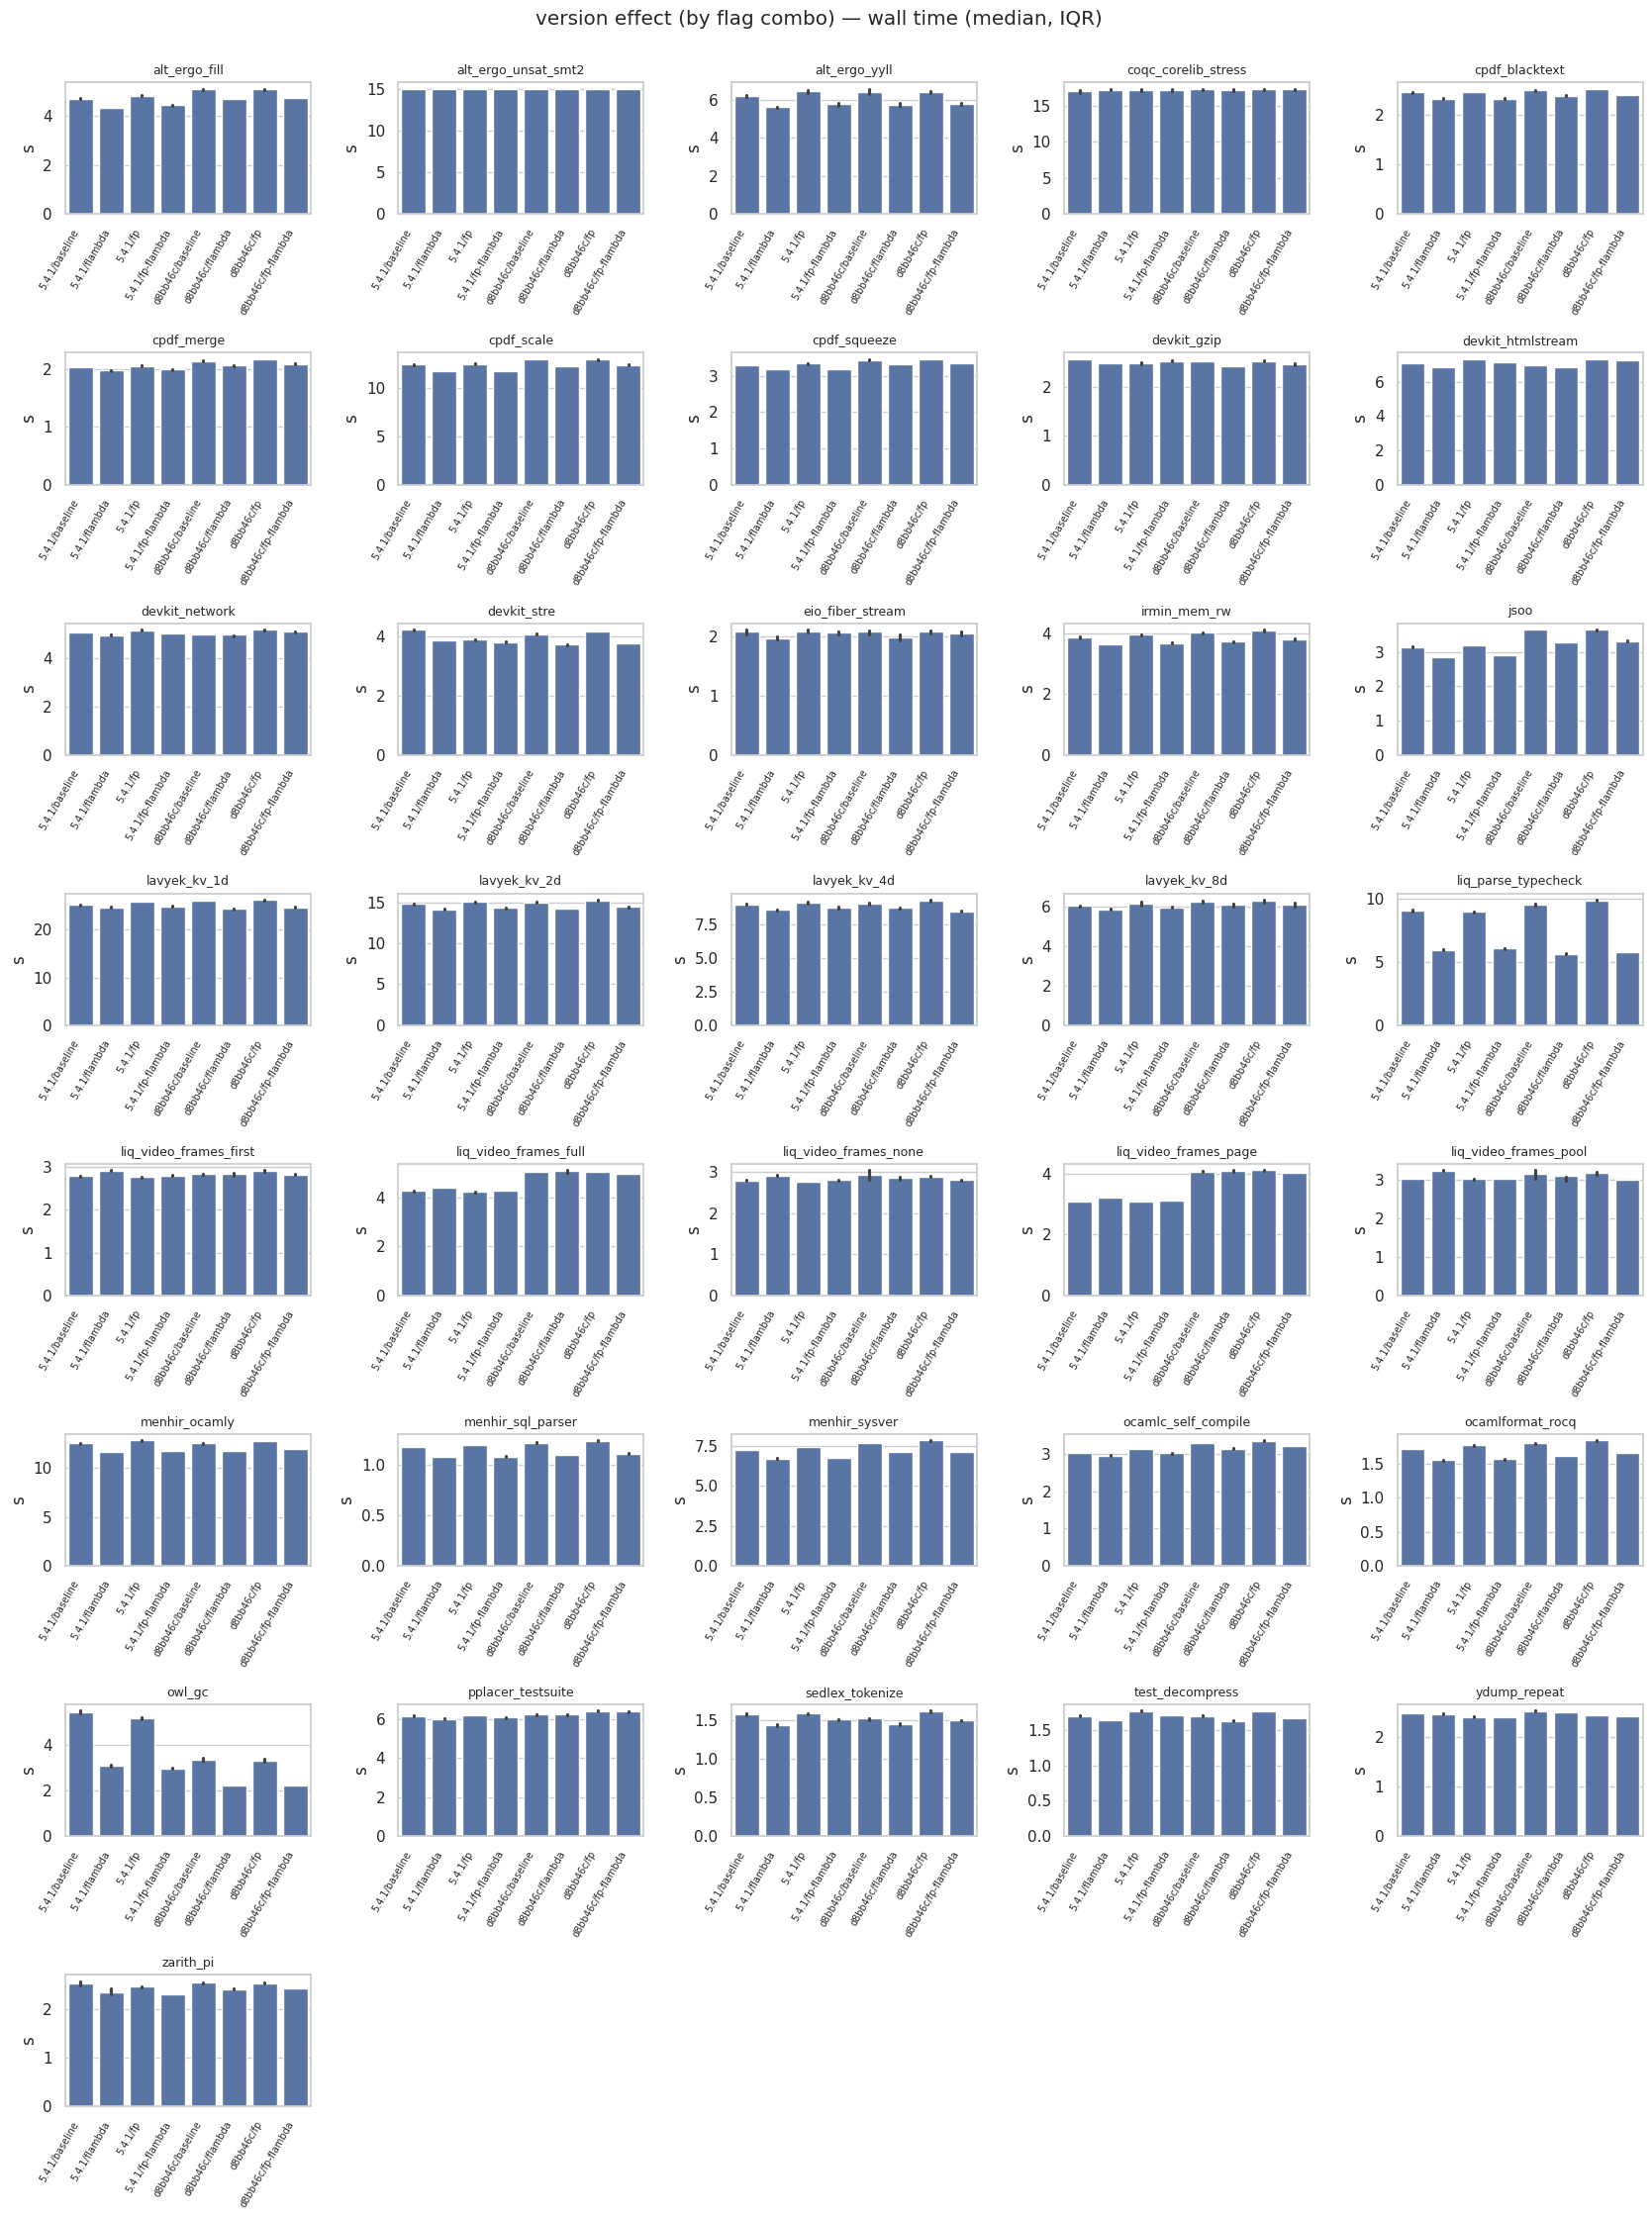

#### Mutator vs GC time

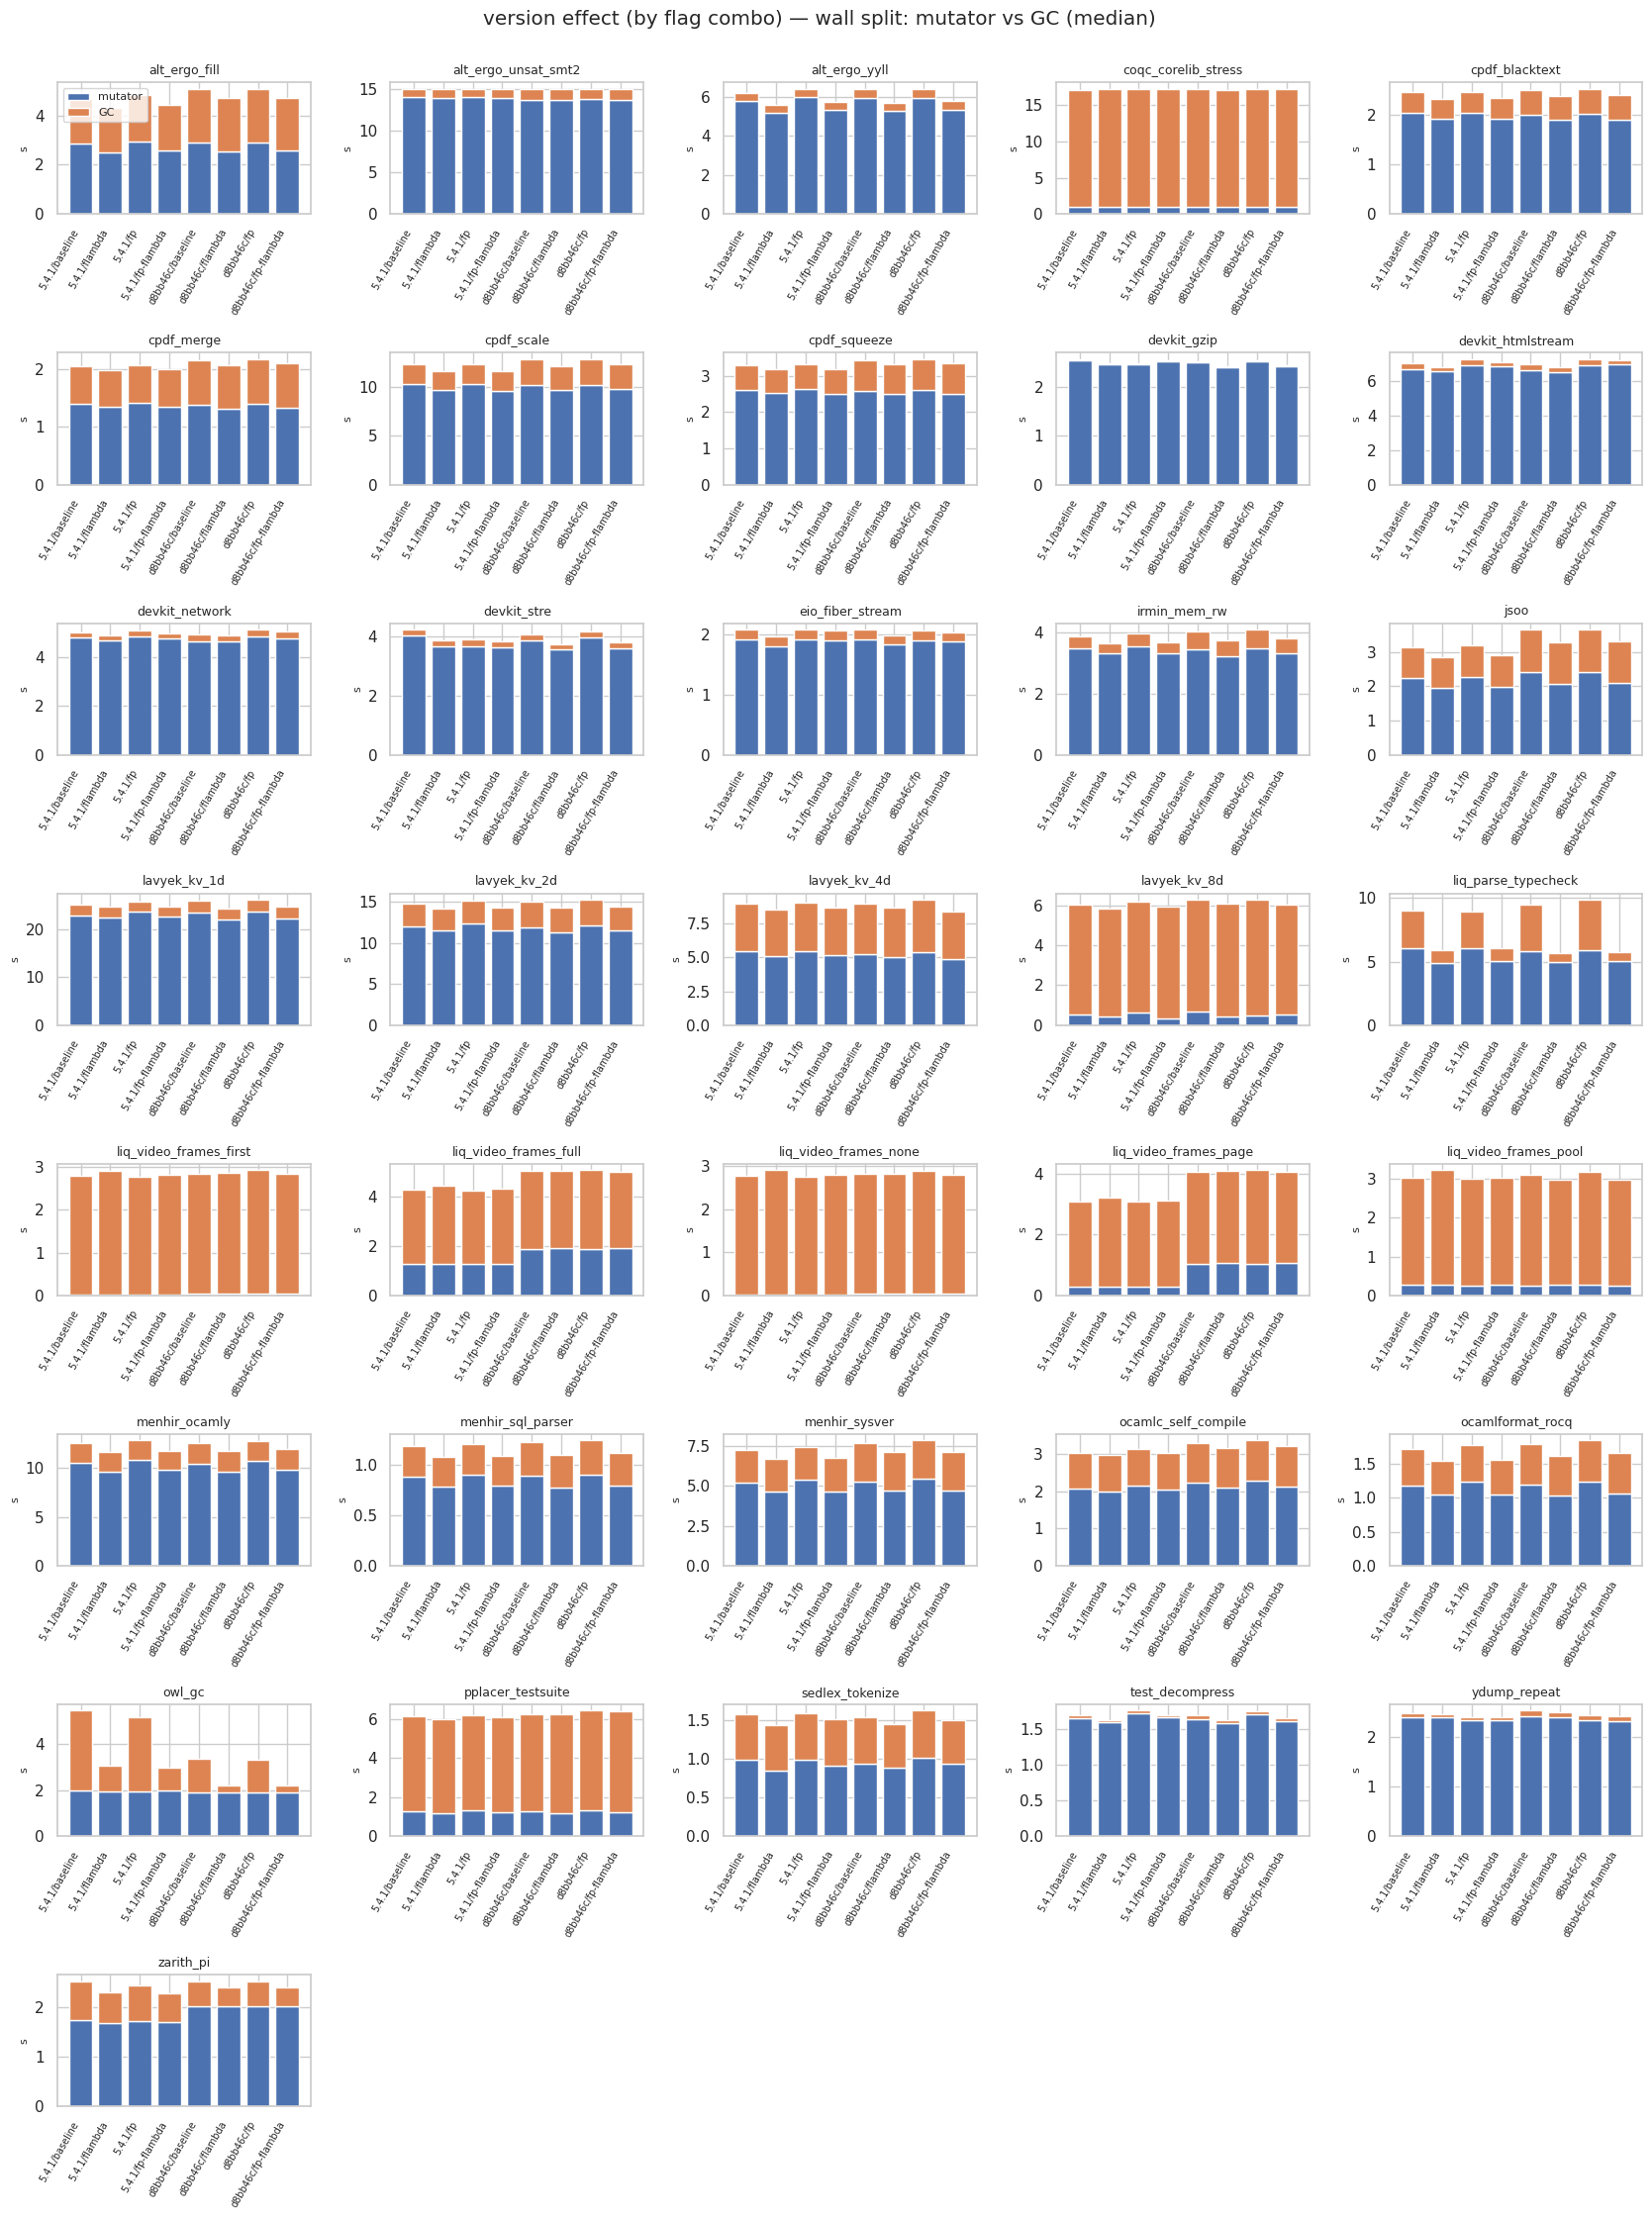

#### GC overhead (% of wall)

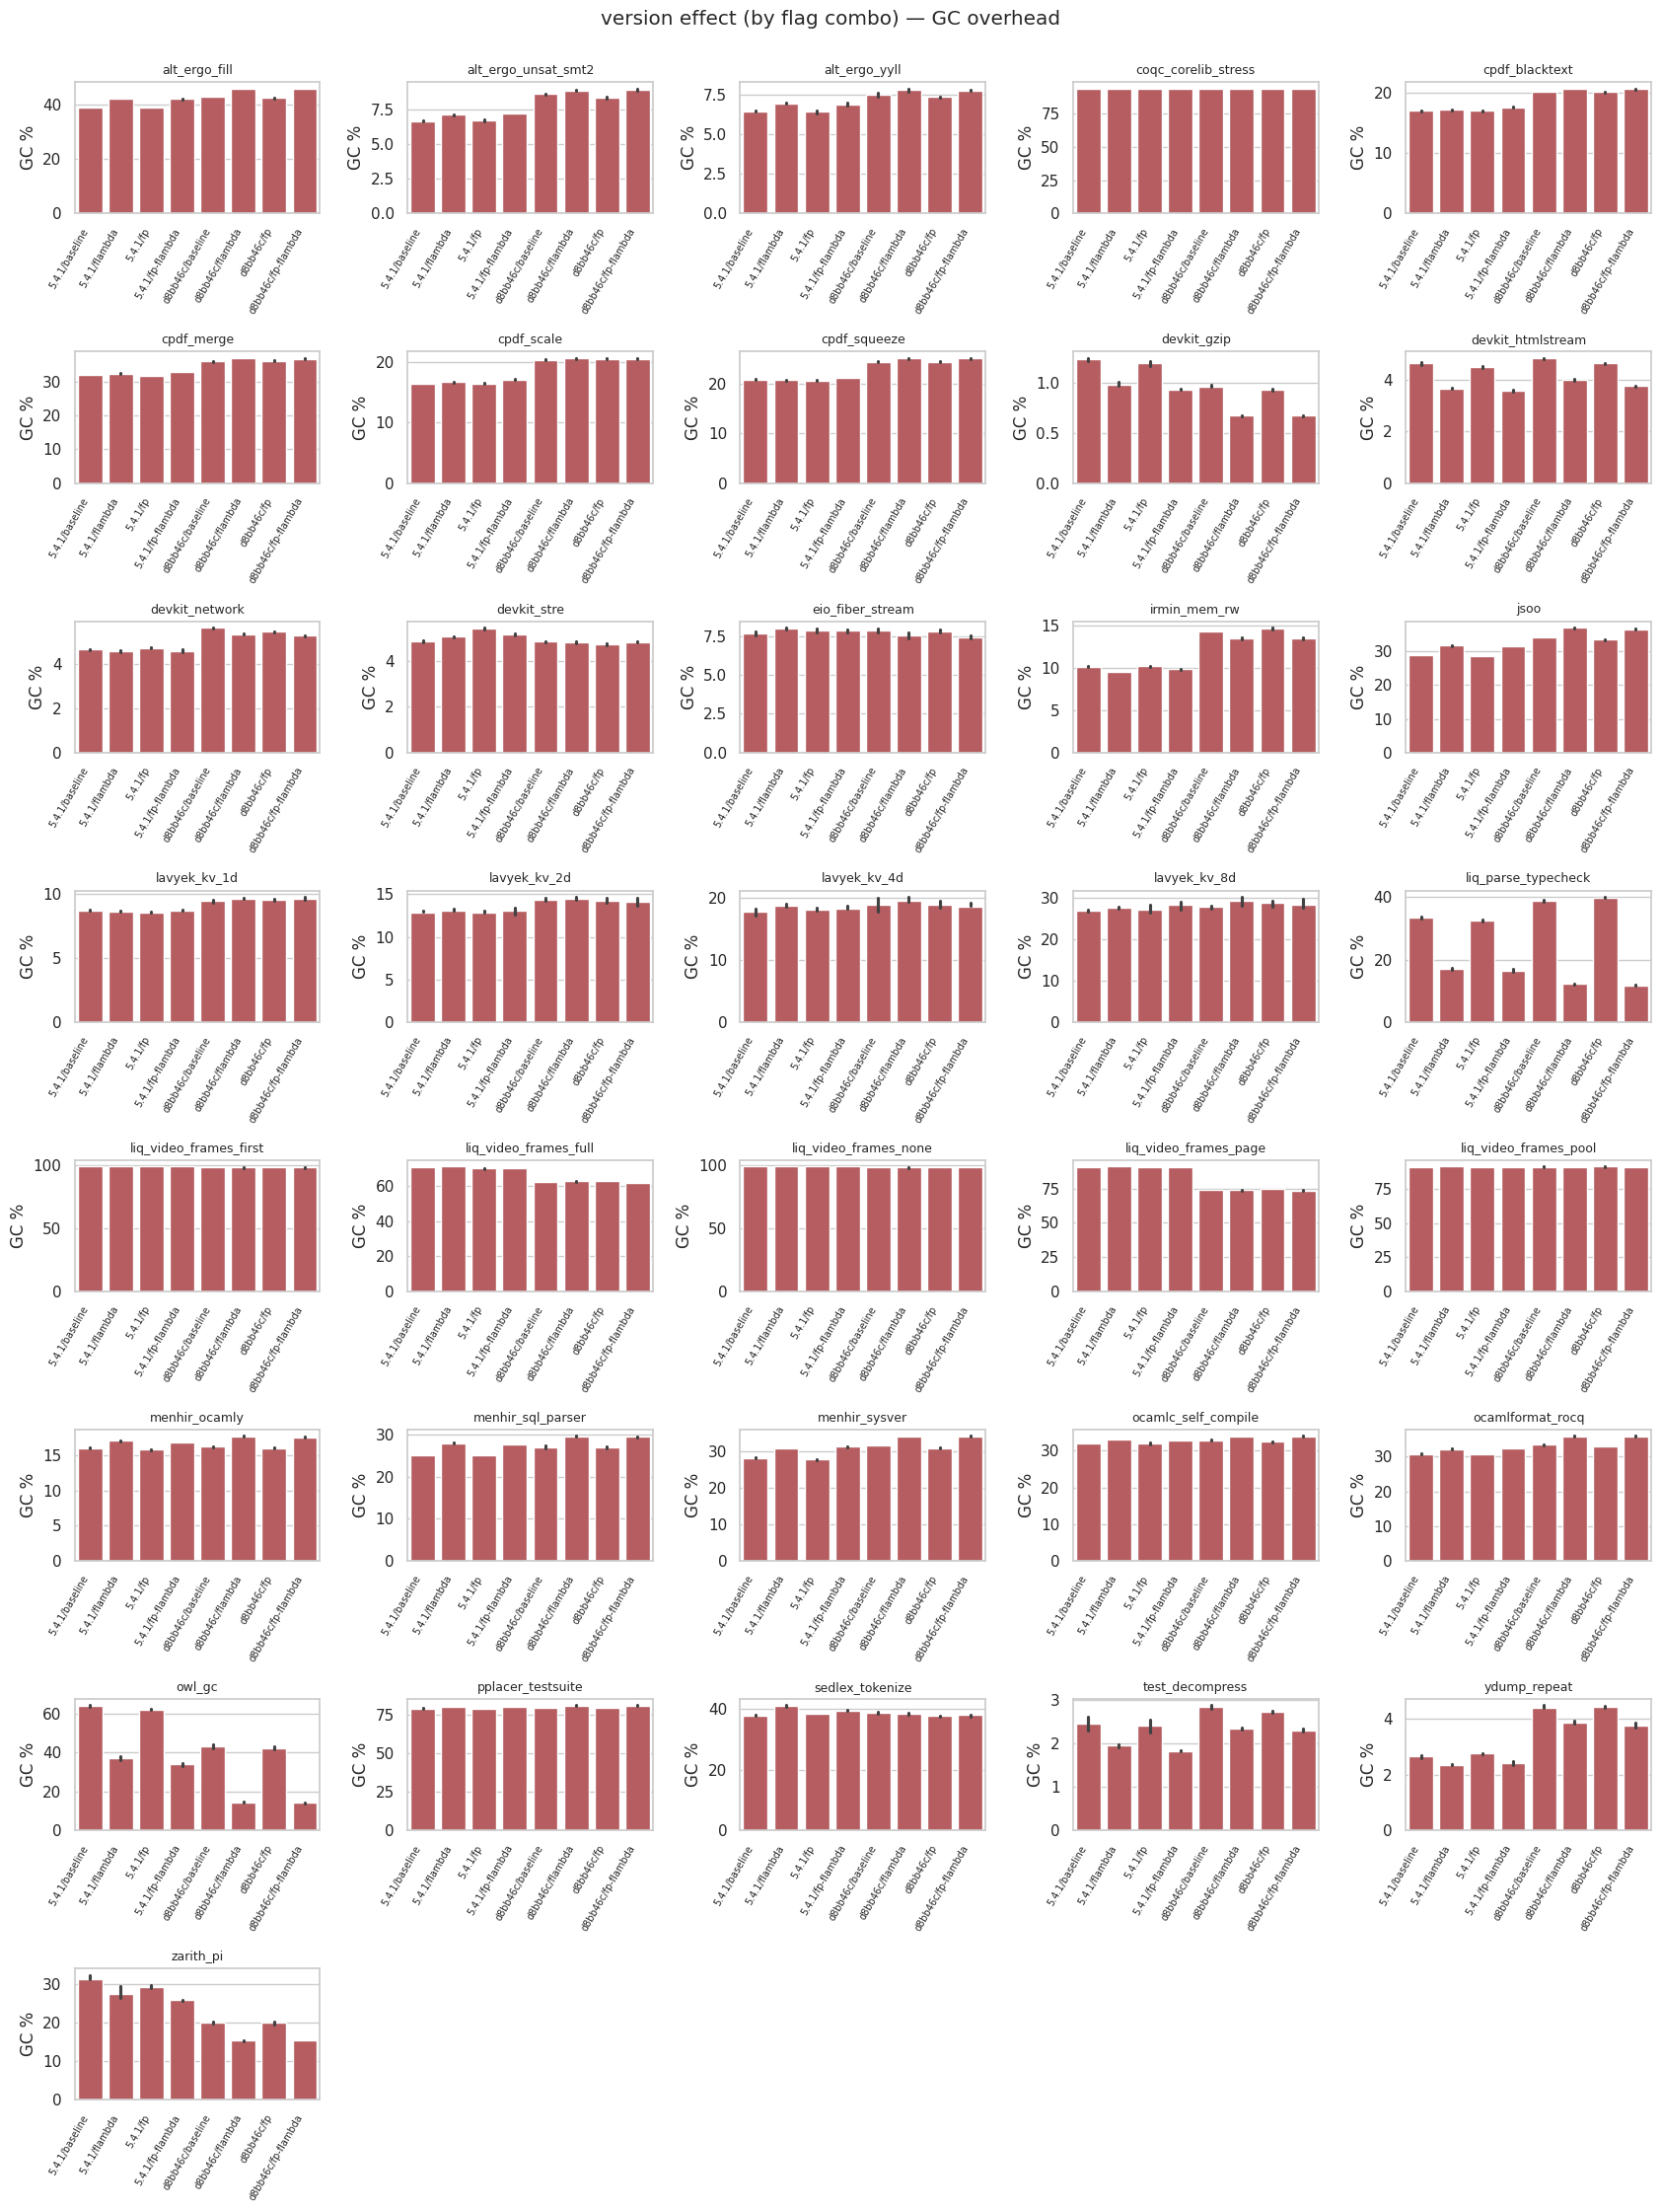

#### Latency ECDF

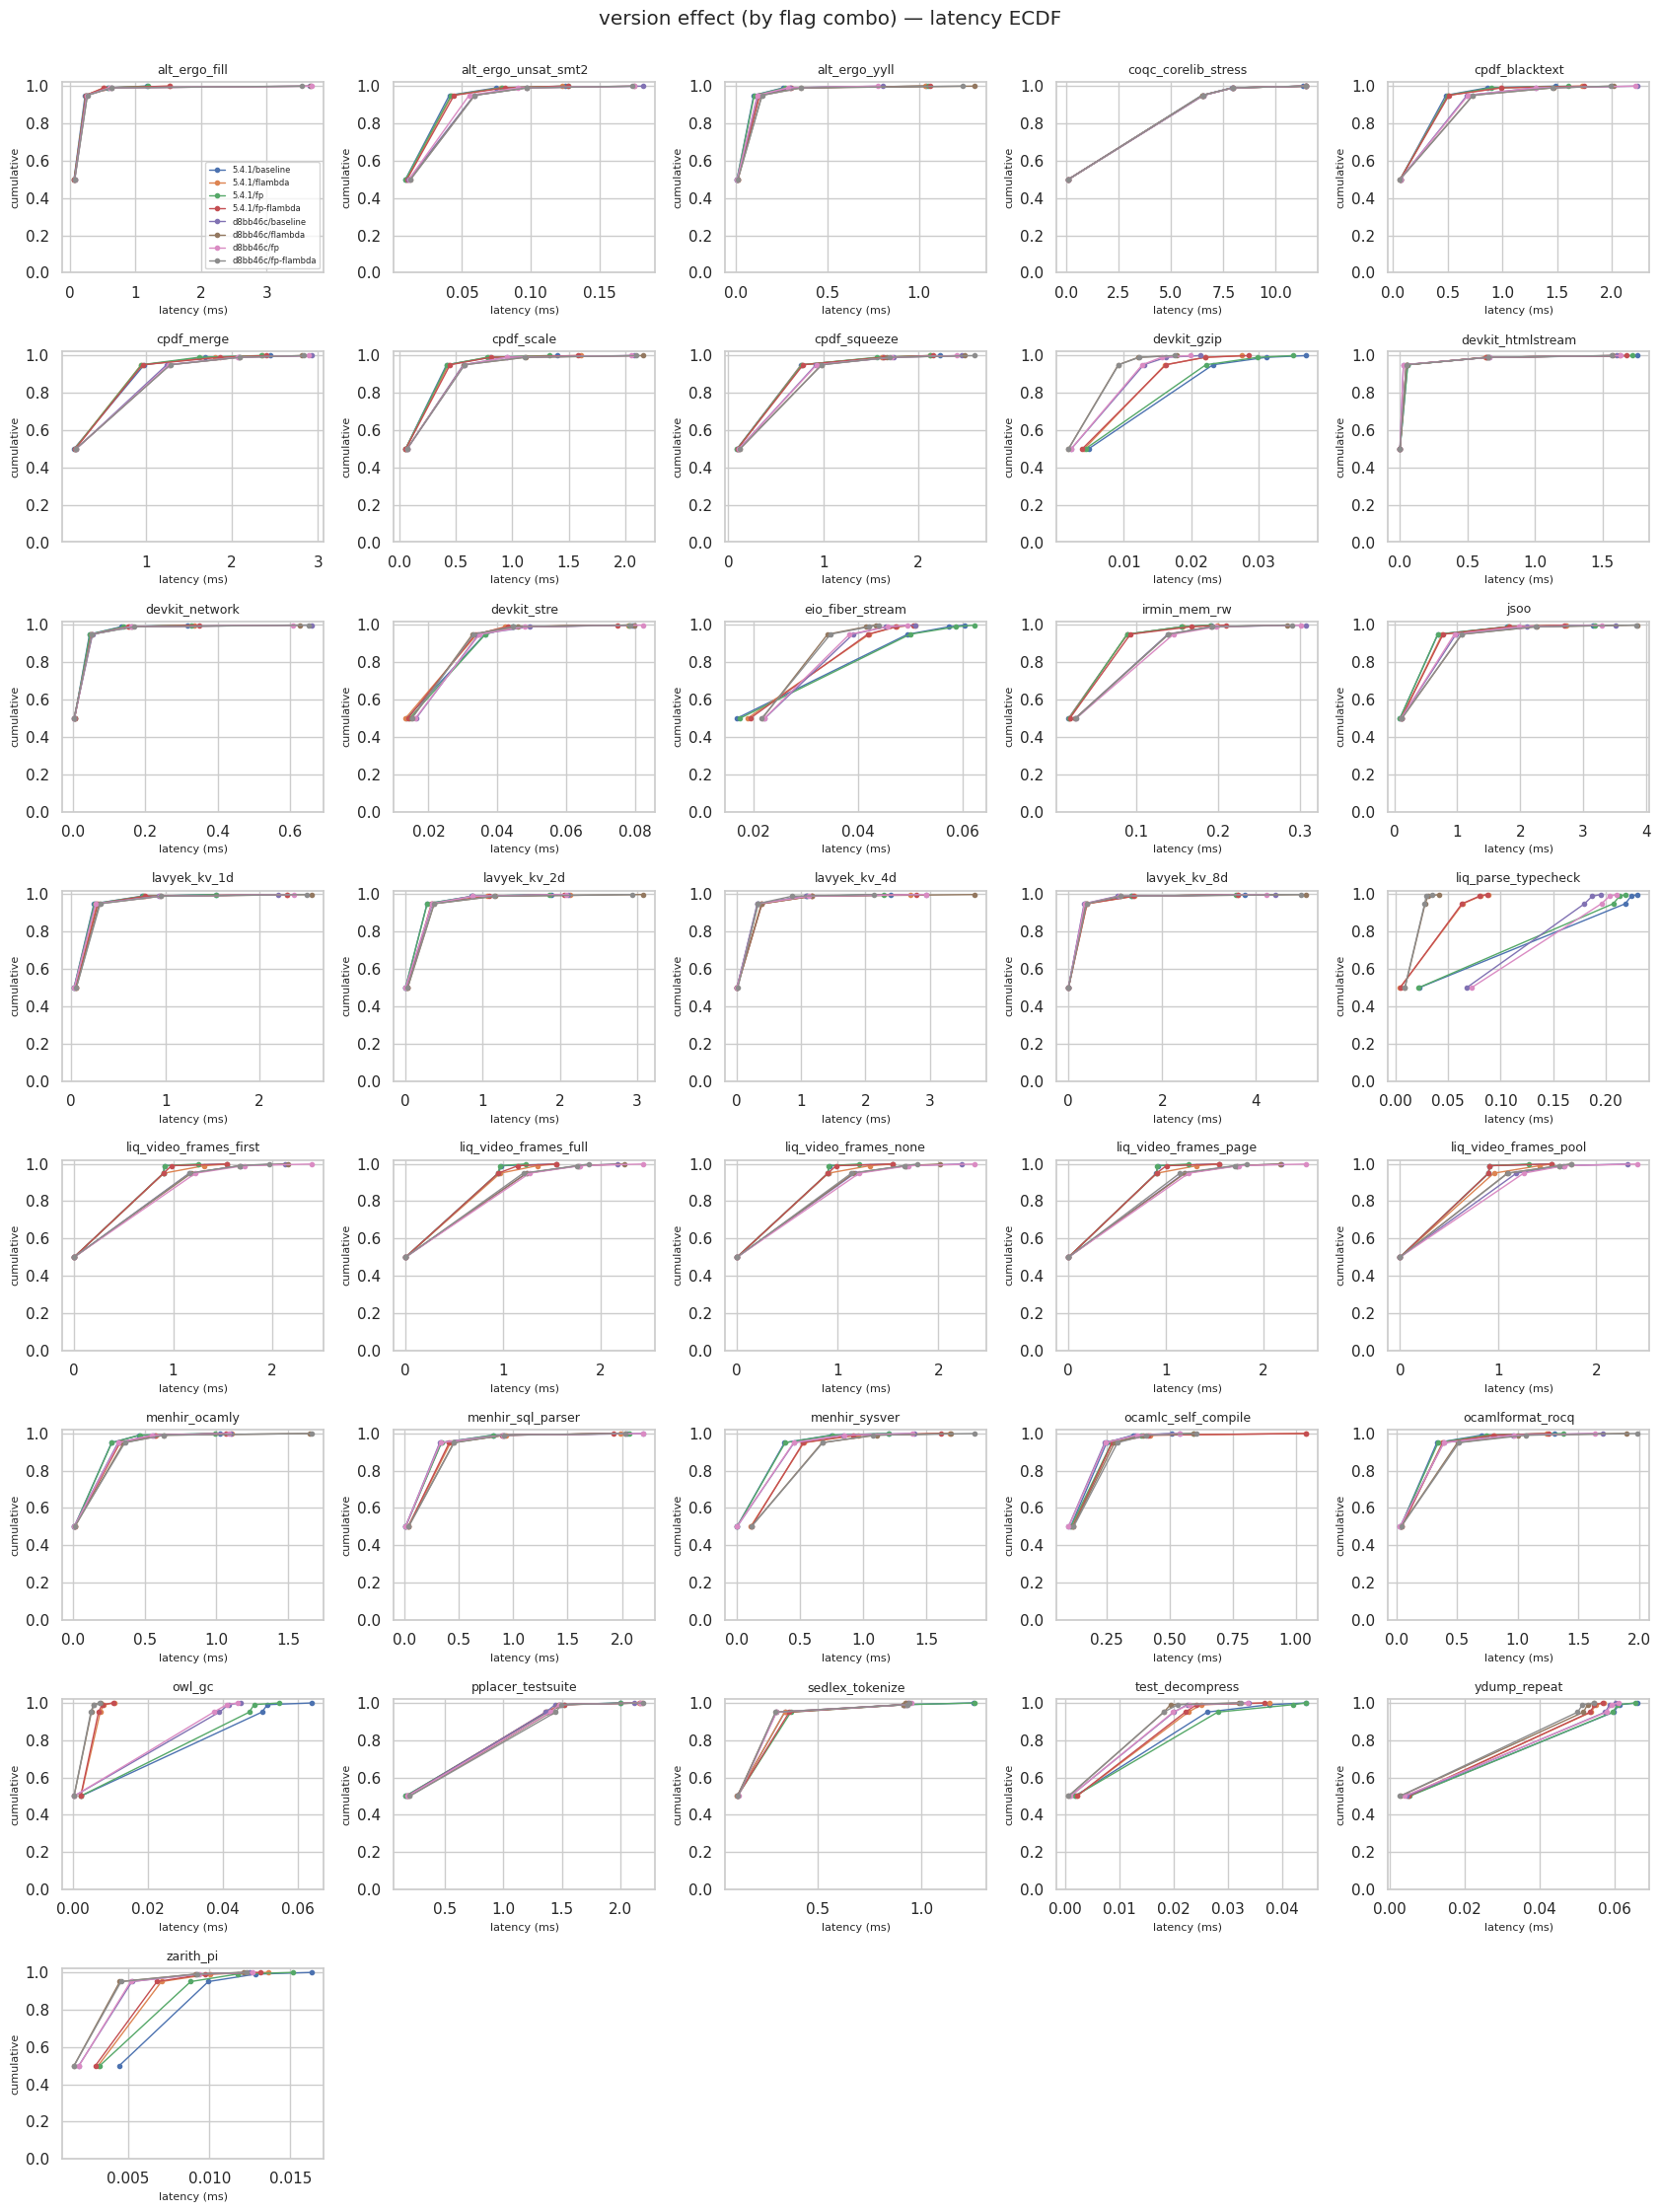

#### Wall-time distribution per cell

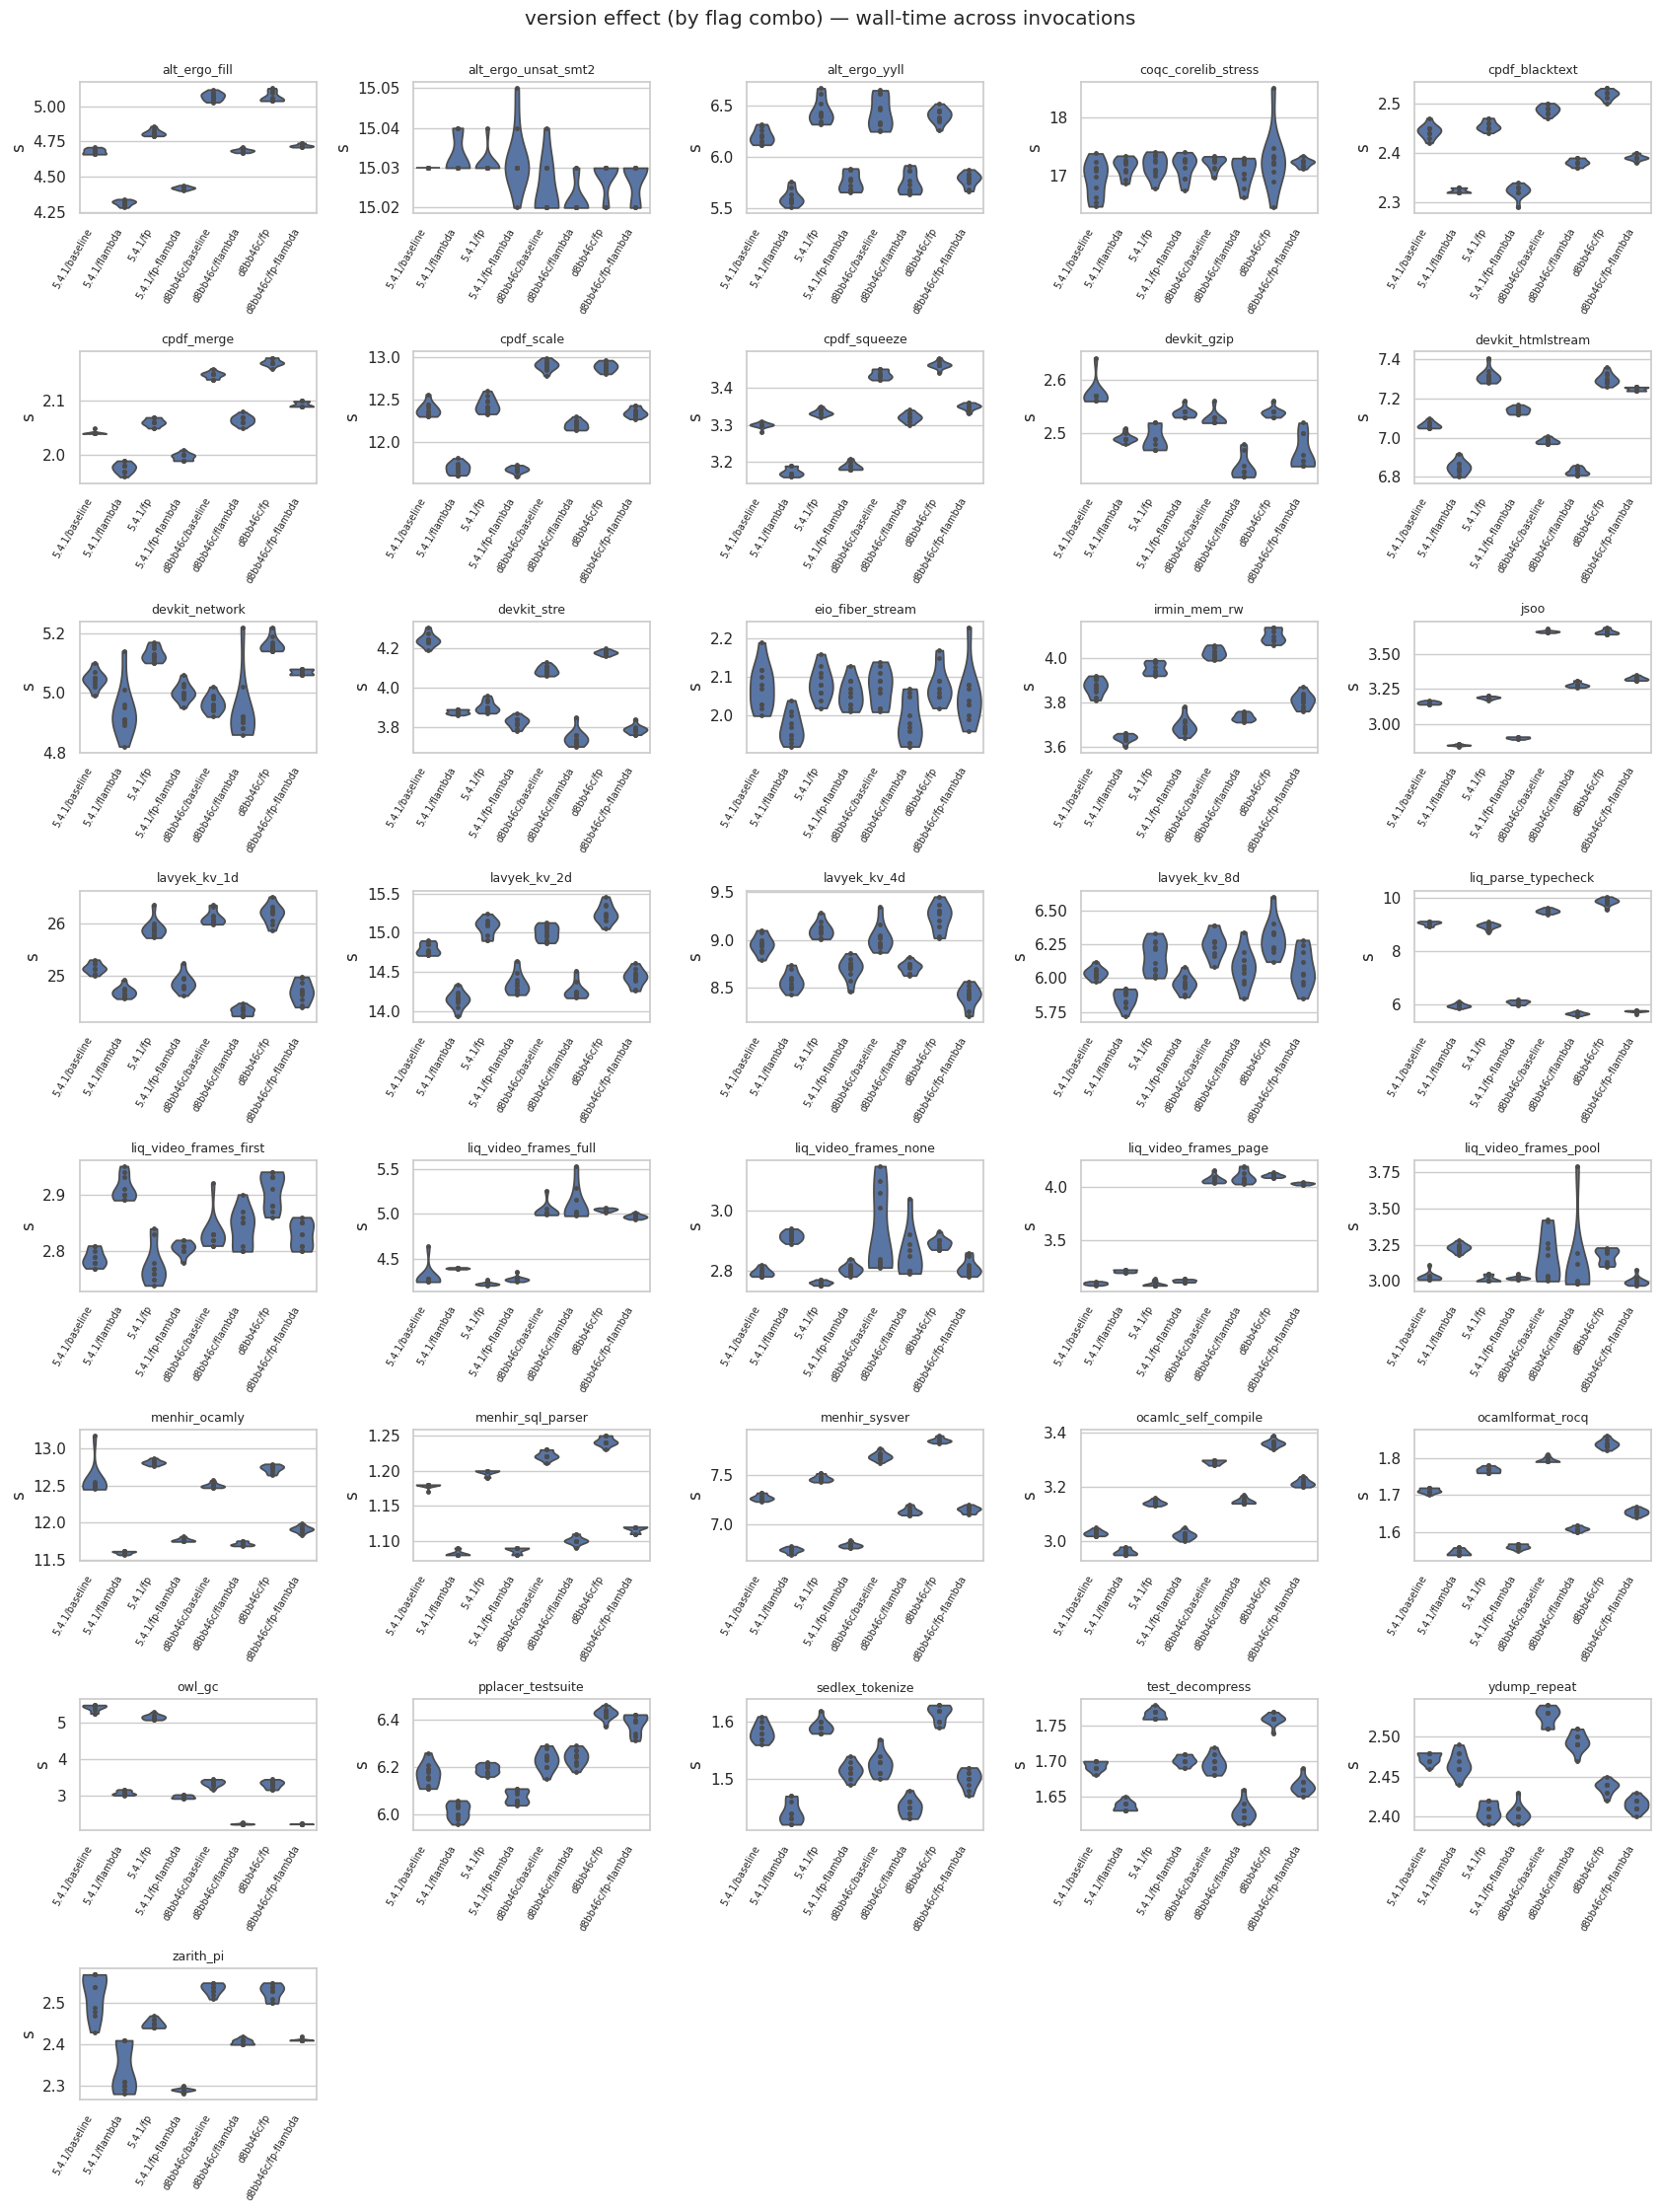

#### Allocation: promoted %

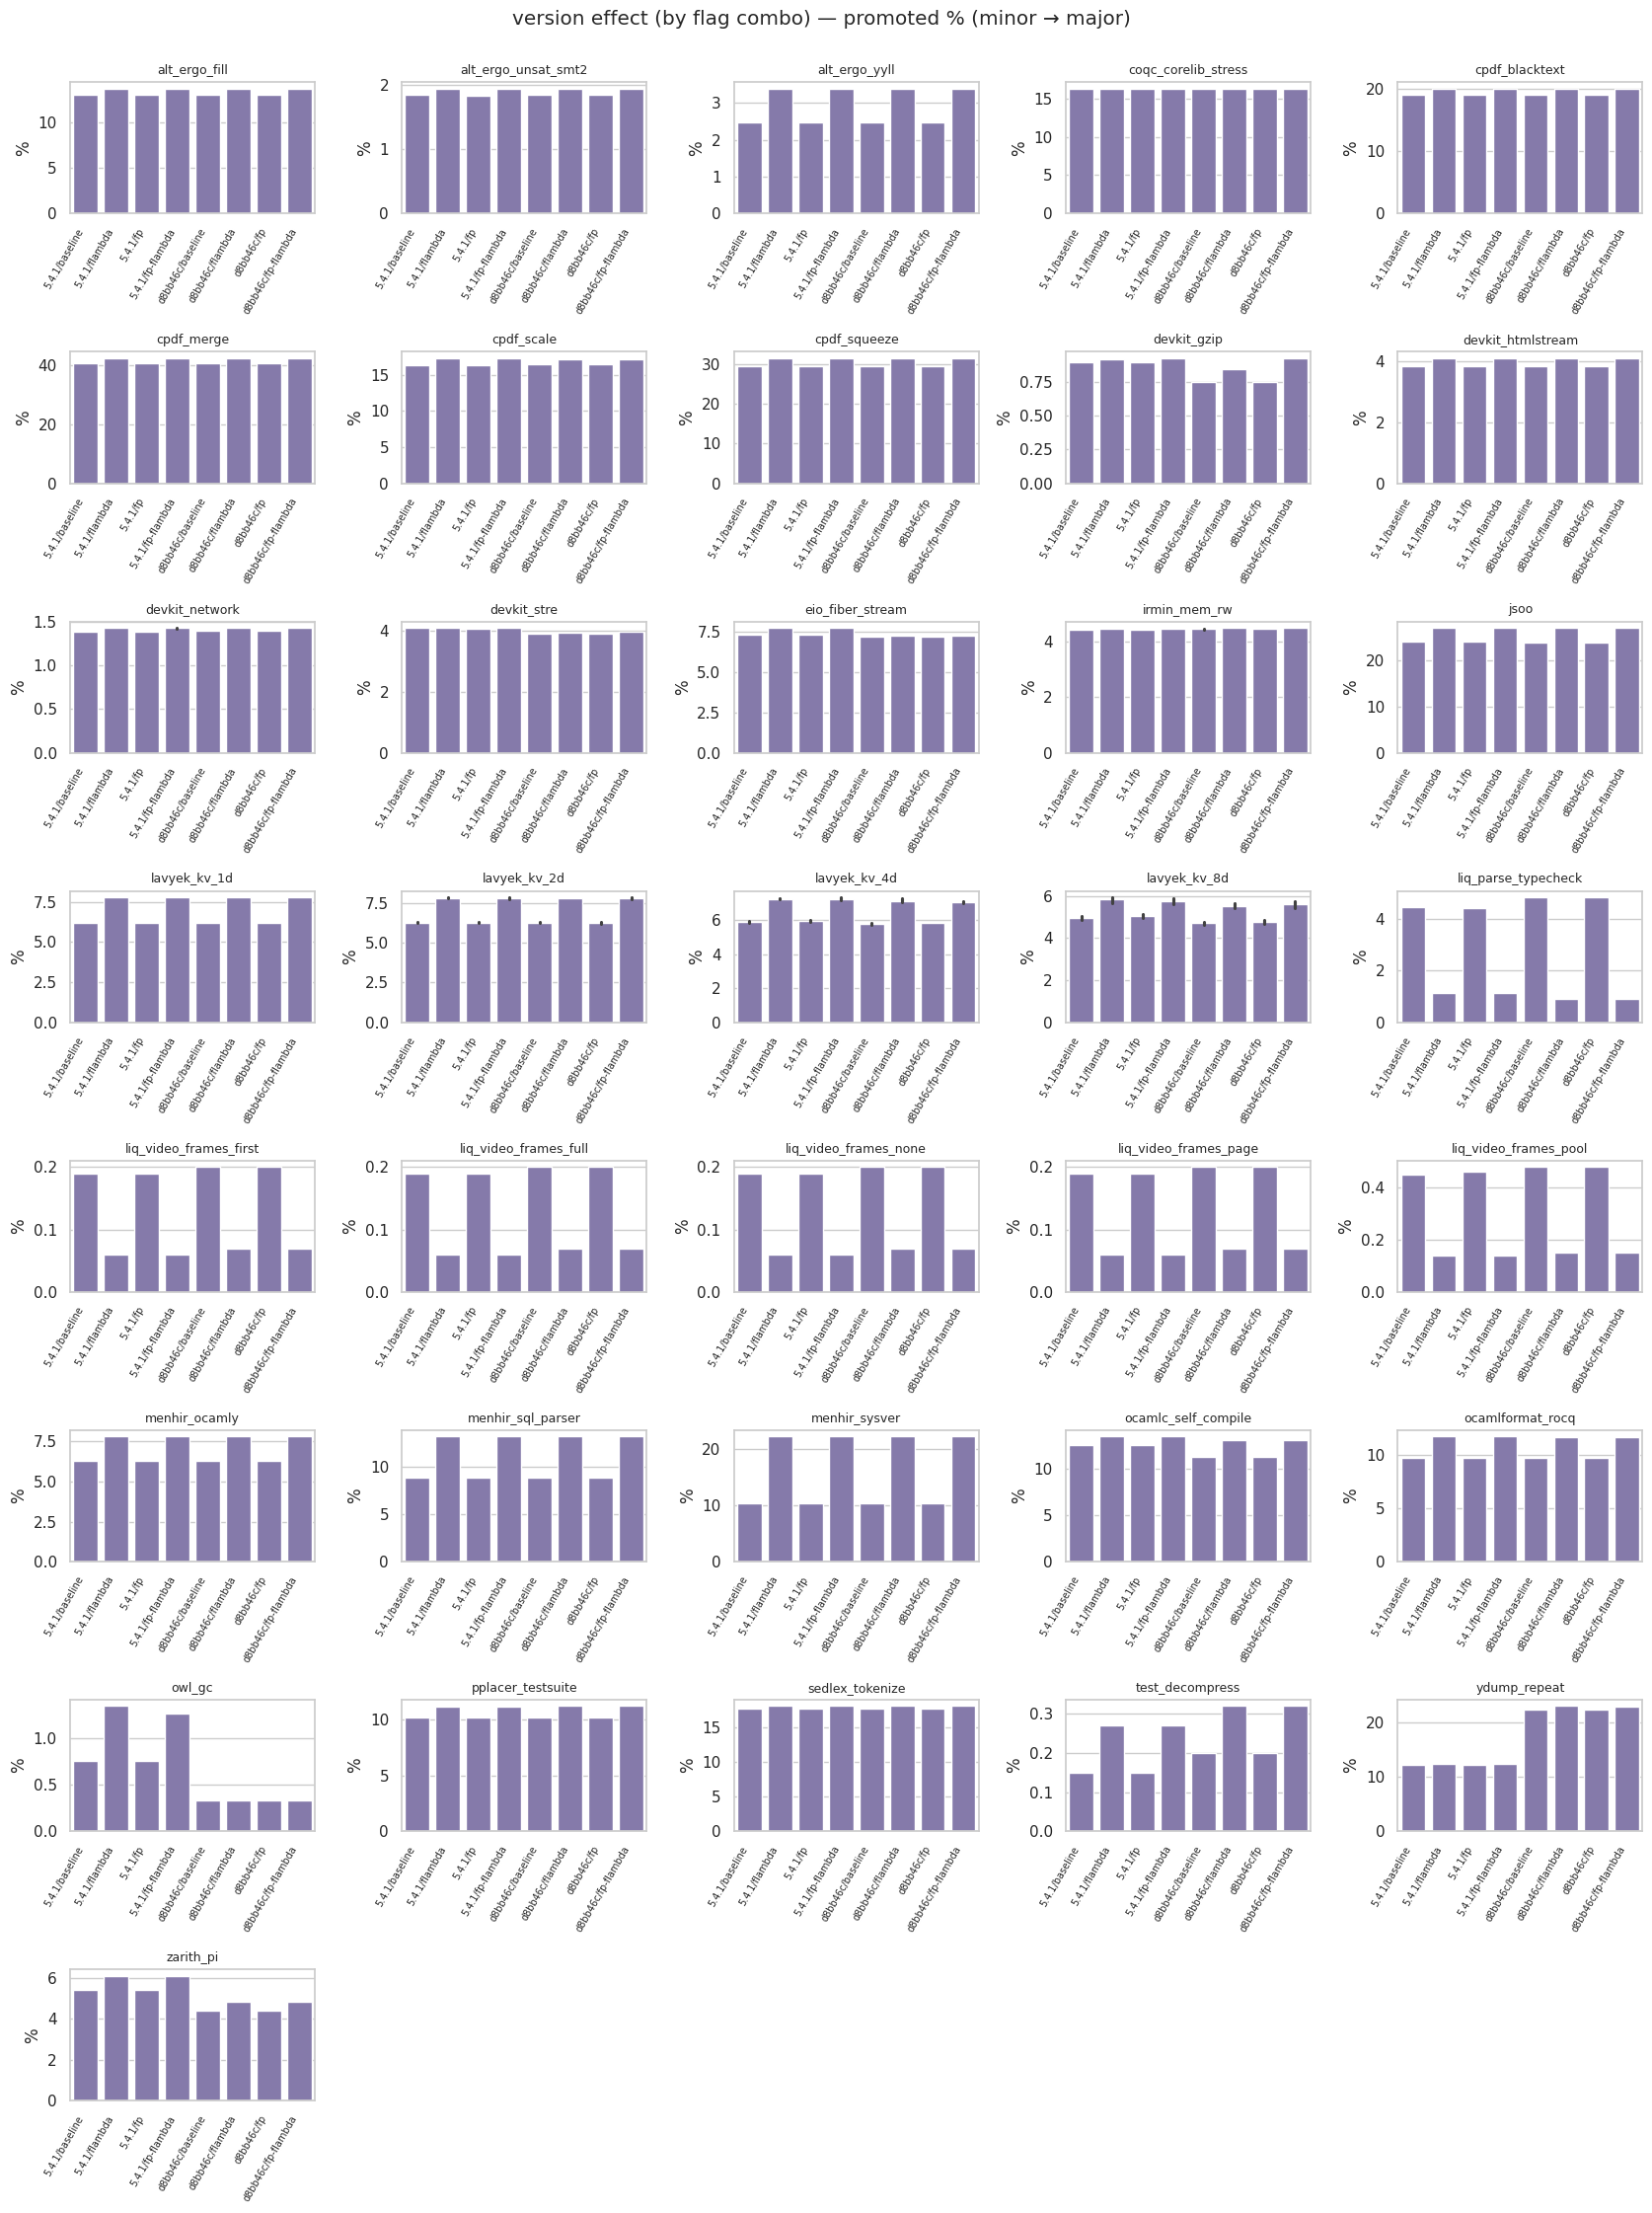

#### Hardware counters

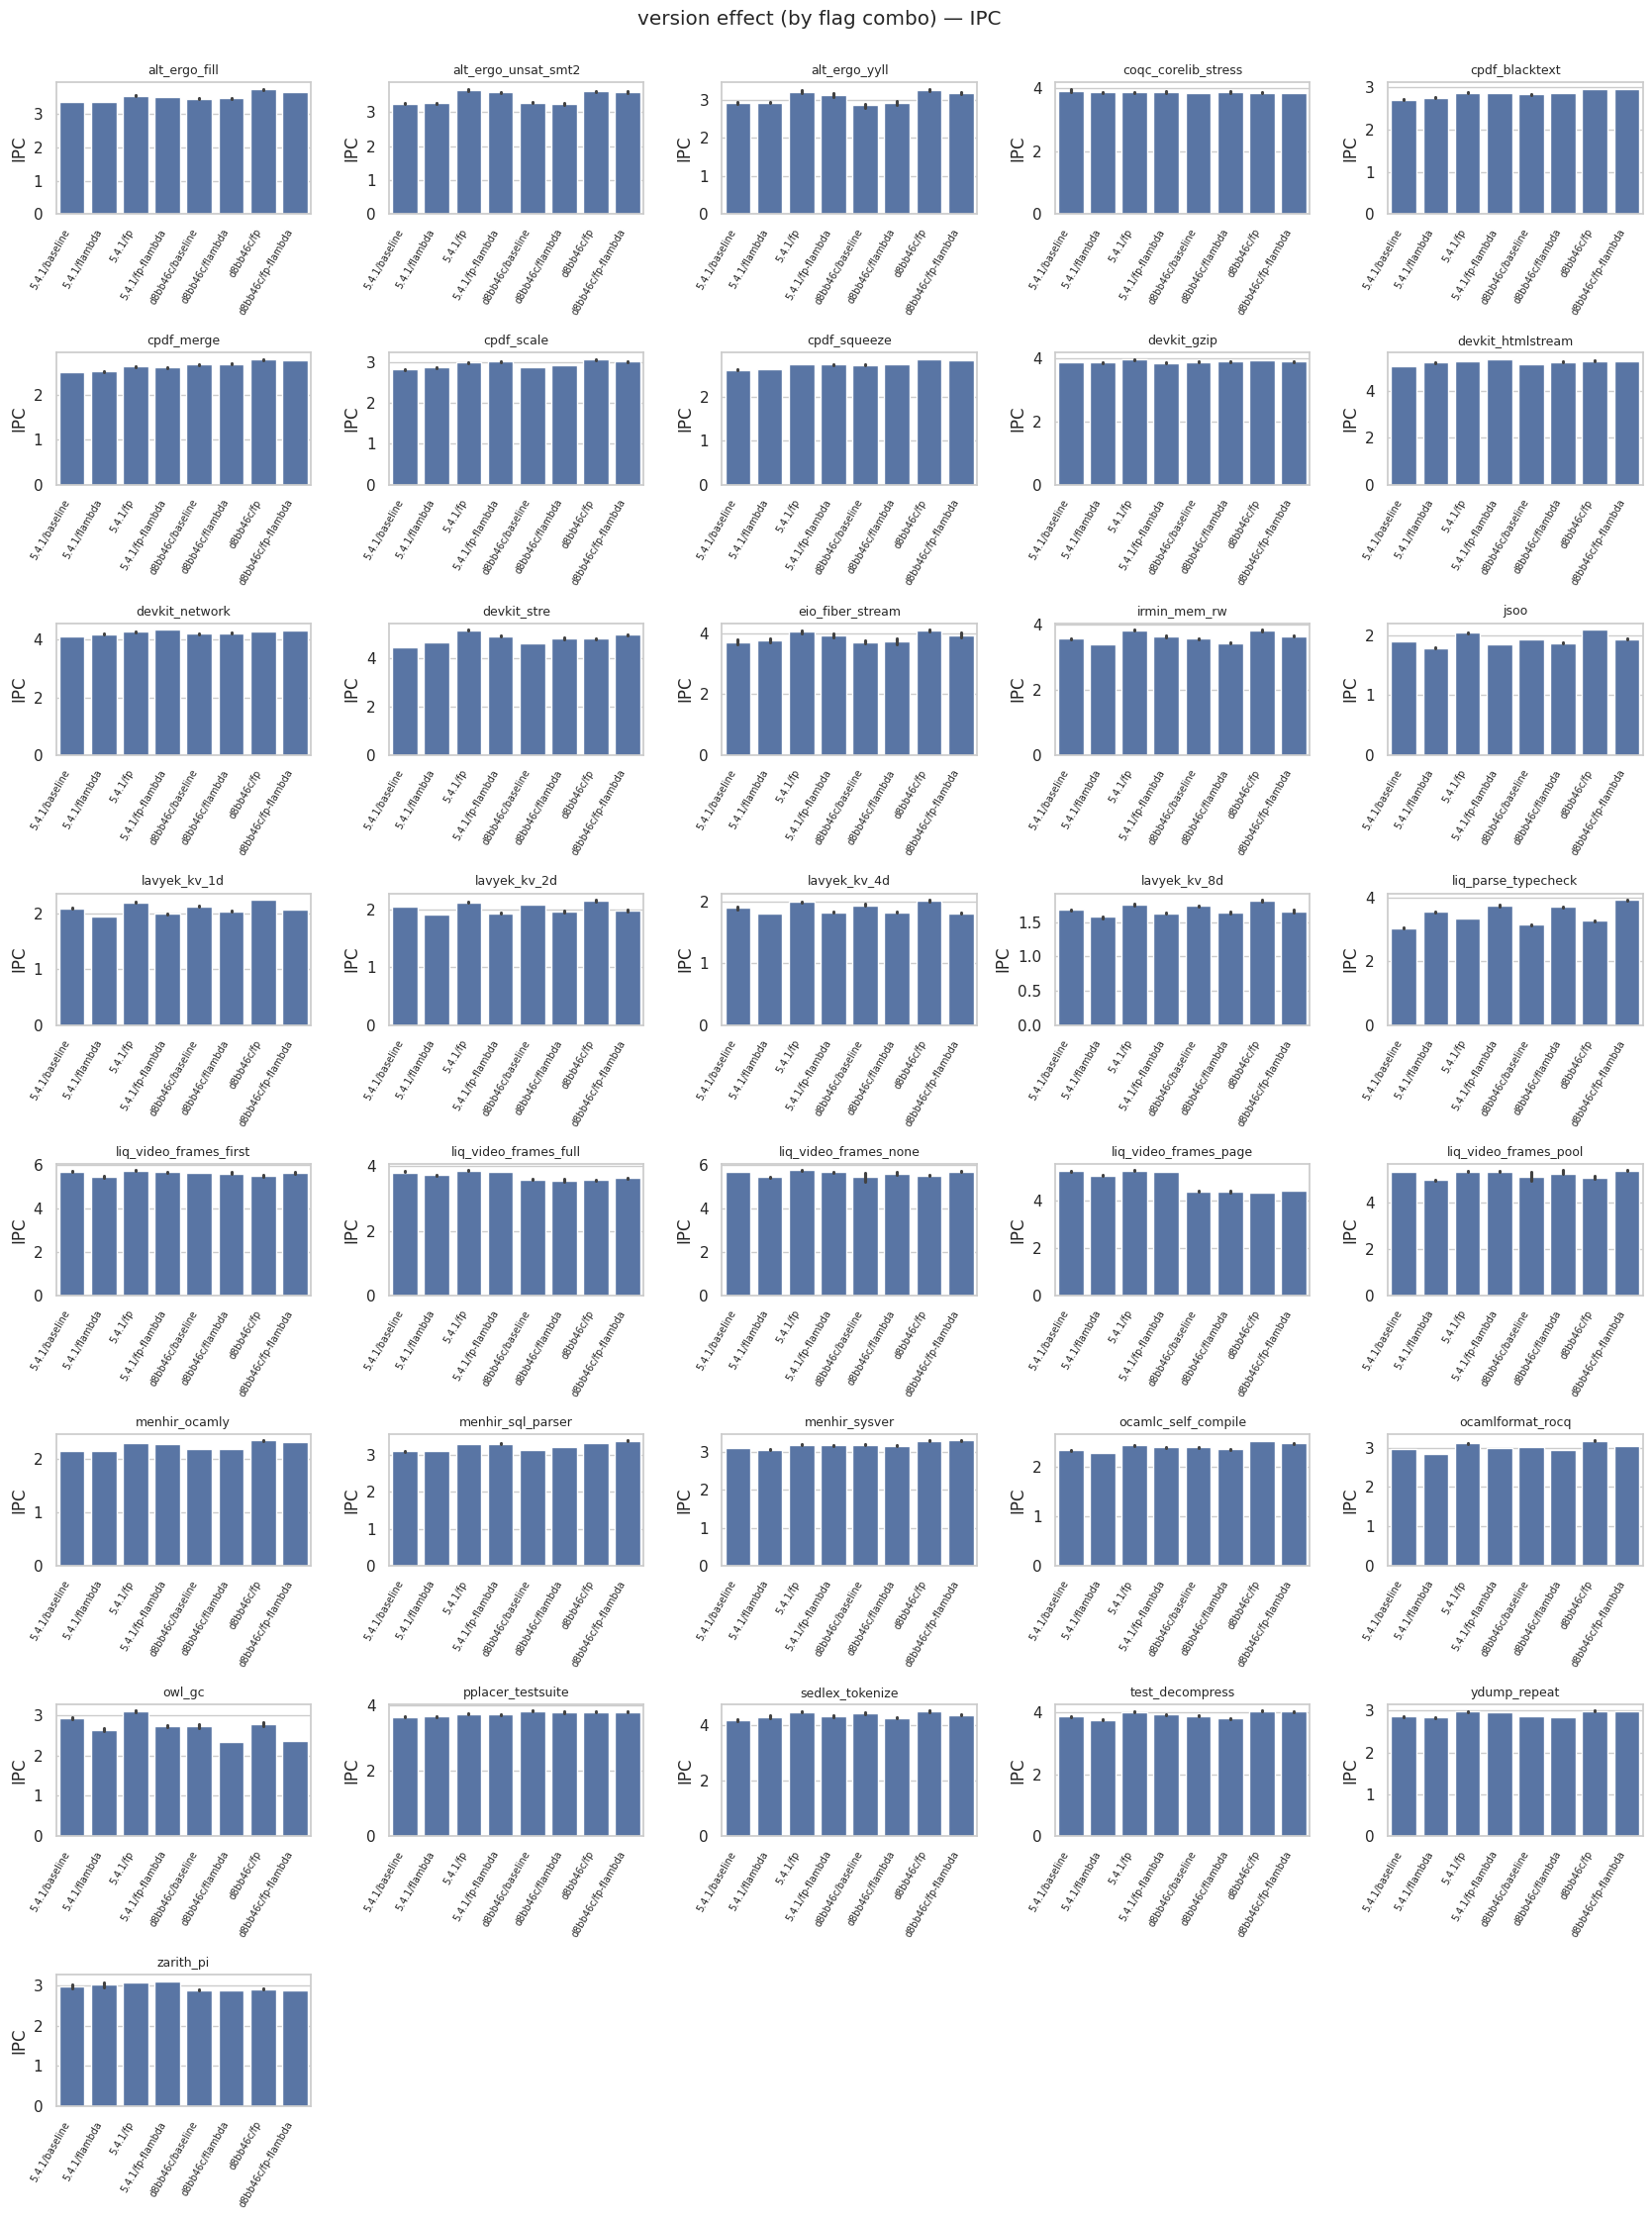

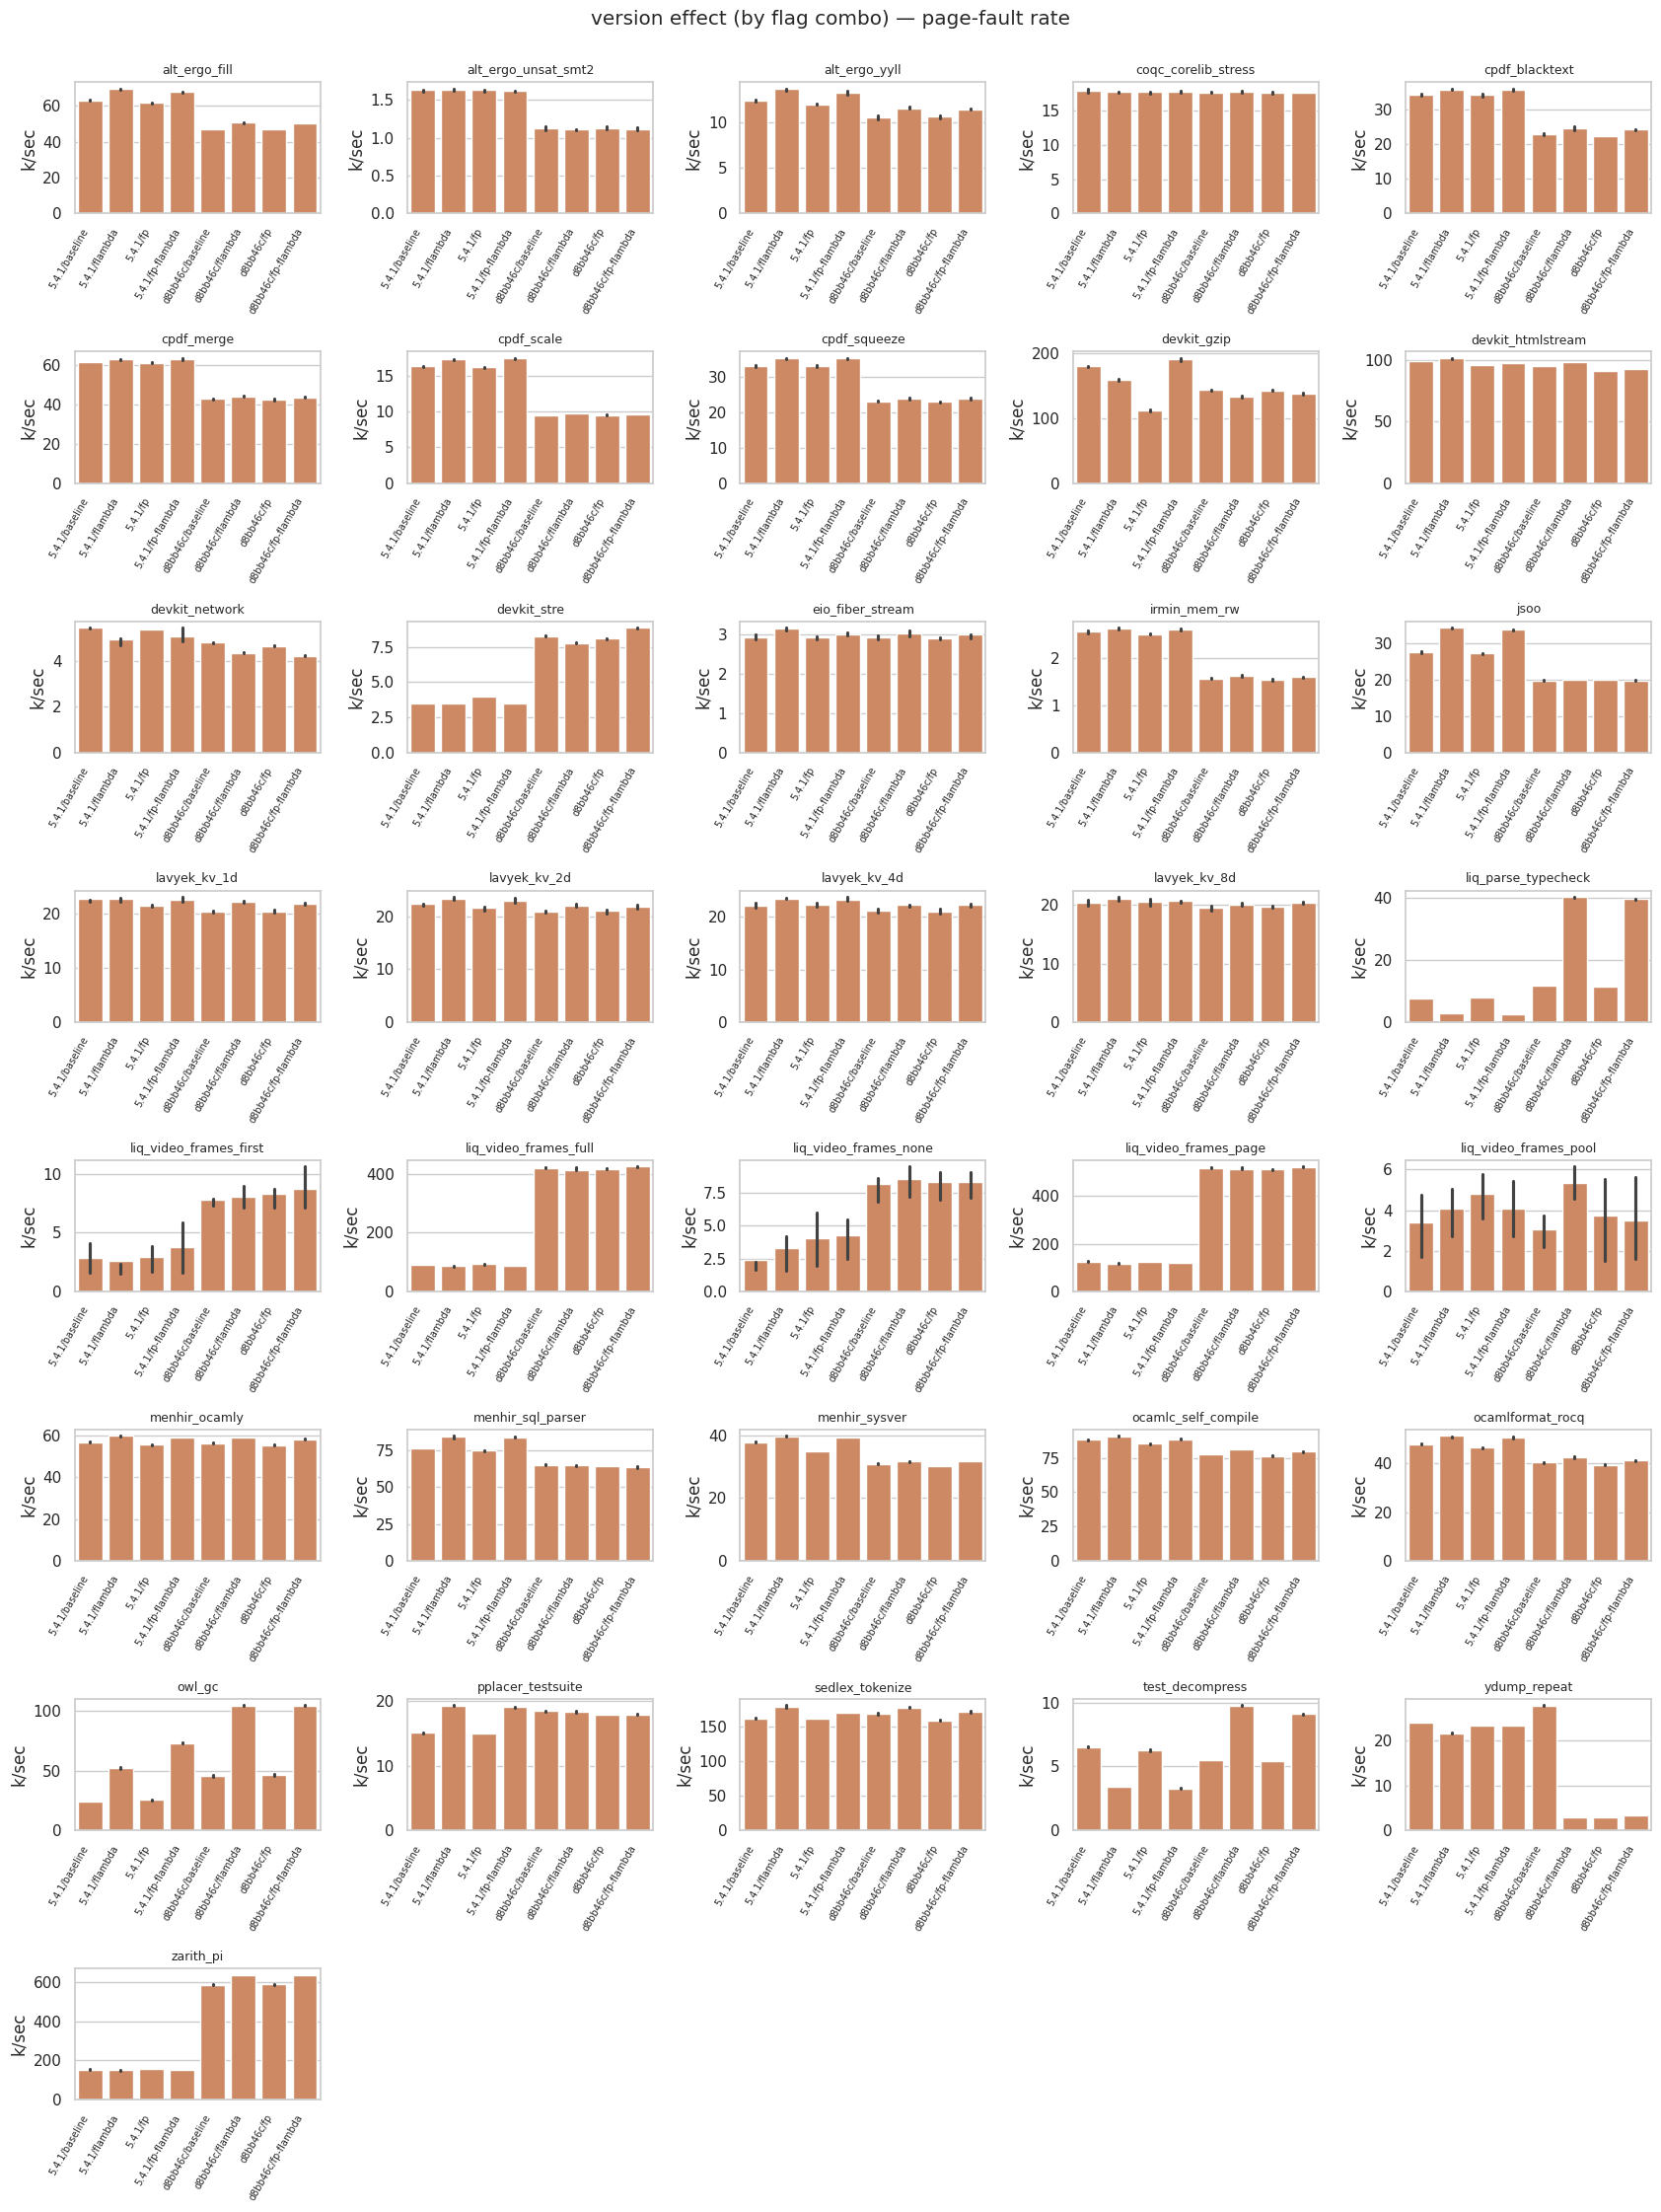

In [9]:
for cmp in comparisons:
    render_block_b(cmp, df, benches)

## 5. ministat export

Pick a benchmark and two variants. Writes two newline-separated files of raw measurements and prints the `ministat` command. Edit the variables below to switch what's exported.

In [10]:
EXPORT_BENCH = benches[0]
EXPORT_A = all_variants[0]
EXPORT_B = all_variants[1] if len(all_variants) > 1 else all_variants[0]
EXPORT_METRIC = "olly_wall_time_s"

try:
    pa, pb = export_for_ministat(
        df, EXPORT_METRIC, EXPORT_BENCH, EXPORT_A, EXPORT_B, MINISTAT_OUT,
    )
    print(f"Wrote:\n  {pa}\n  {pb}")
    print("\nRun:")
    print(f"  ministat -C 1 {pa} {pb}")
except ValueError as e:
    print(f"Cannot export: {e}")

Wrote:
  /home/udesou/macro-benches/results/latest/2026-05-12-fp-flambda-N10-monolith/notebooks/cache/ministat/olly_wall_time_s__alt_ergo_fill__5.4.1_baseline.txt
  /home/udesou/macro-benches/results/latest/2026-05-12-fp-flambda-N10-monolith/notebooks/cache/ministat/olly_wall_time_s__alt_ergo_fill__5.4.1_flambda.txt

Run:
  ministat -C 1 /home/udesou/macro-benches/results/latest/2026-05-12-fp-flambda-N10-monolith/notebooks/cache/ministat/olly_wall_time_s__alt_ergo_fill__5.4.1_baseline.txt /home/udesou/macro-benches/results/latest/2026-05-12-fp-flambda-N10-monolith/notebooks/cache/ministat/olly_wall_time_s__alt_ergo_fill__5.4.1_flambda.txt
